# P&ID Digitization with a Relation-aware Deformable DETR (PIDFormer)

This notebook trains a PyTorch model that reads a **Piping & Instrumentation Diagram (P&ID)** image and returns, for every
piece of equipment / symbol:

* its **bounding box** (and **center x, y**),
* its **symbol class** (32 Digitize-PID classes, plus the 7 coarse classes used in the paper),
* its **tag name** (e.g. `WX-71994`, `GLR-193`), from EasyOCR and/or Claude Sonnet 5.5 vision,
* its **role**: major equipment (tanks, vessels, reactors, columns, pumps …, including ones never seen in training), instrument, valve,
  line component or inlet/outlet. Alarms, trip switches and SIS functions are **not** equipment: they are listed as `safety_functions`
  linked to the transmitter they act on (ISA-5.1 tag decoding),
* the **list of equipment it is connected to**, with **line type** (solid / dashed) and a confidence score. A crossing-aware
  skeleton line tracer (OpenCV) is the main source; the Relationformer relation head re-ranks its edges and adds missed ones; Claude is optional.

Final output is a JSON per sheet:
```json
{"sheet": "0.jpg", "equipment": [{"id": 3, "tag": "WX-71994", "class_name": "valve_bowtie_filled",
  "bbox": [x1, y1, x2, y2], "center": [cx, cy], "confidence": 0.97, "connected_to": [7, 12]}], "connections": [...]}
```

## Reference paper
Stürmer, Graumann, Koch — *From Engineering Diagrams to Graphs: Digitizing P&IDs with Transformers*
([arXiv:2411.13929](https://arxiv.org/abs/2411.13929), DSAA 2025). Key ideas reproduced here:

| Paper | This notebook |
|---|---|
| Relationformer = Deformable DETR + `[rln]` relation token + pairwise relation MLP | ✅ same structure (`PIDFormer`) |
| Patching of the full diagram with ≥50 % overlap, per-patch inference | ✅ random crops for training, 50 % overlapping tiles at inference |
| Merge: border-distance confidence decay → filtering → NMS → Weighted Box Fusion | ✅ implemented (`merge_tile_detections`) |
| EasyOCR for text | ✅ plus Claude vision for tag reading |
| Metrics: symbol mAP@0.5, class-agnostic node AP, edge mAP (Hungarian node matching) | ✅ implemented |
| Two edge classes: solid / non-solid lines | ✅ 3-way relation head (none / solid / dashed), trained on PID2Graph ground-truth edges |
| Crossing / ankle / border nodes | crossings resolved by the skeleton line tracer (branch geometry at each junction) and by GT contraction; junctions exported as nodes; border edges via tile merging |
| PID2Graph benchmark (OPEN100 real plans, synthetic) | ✅ evaluated in §9b with the paper's node AP, 7-class mAP and edge mAP |
| ResNet-101, 512² patches, lr 1e-4 / backbone 3e-5 | ResNet-50 (configurable), 1024² patches (symbols are tiny) |

A detailed capability review against the paper, with this notebook's results, is in §11.

## Improvements over the paper (post-2024 detection-transformer practice)
1. **Contrastive DeNoising (CDN, DINO)** — noised copies of ground-truth boxes are fed as extra queries; positives must be
   reconstructed, *negatives* (larger noise) must be rejected. Stabilises bipartite matching and speeds convergence a lot on small datasets.
2. **Two-stage mixed query selection (DINO)** — decoder anchors are initialised from the top-K encoder proposals.
3. **Look-forward-twice box refinement (DINO)** — gradients from layer *i+1* refine layer *i*'s boxes.
4. **Varifocal / IoU-aware classification loss (RT-DETR, DEIM, D-FINE)** — classification target is the IoU of the matched box,
   so confidence ranks localisation quality (important for WBF merging of tiles).
5. **Supervised contrastive learning on query embeddings (SupCon + cross-batch memory)** — the paper's main failure mode is
   confusion between visually similar symbols (their "general" class; our 14 near-identical valve glyphs). A projection head pulls
   together decoder embeddings of the same class across images and pushes apart different classes. The embeddings are also exported
   (t-SNE in §9, few-shot prototype matching).
6. **Efficient hybrid encoder (RT-DETR)**: global self-attention on stride-32 tokens plus CNN cross-scale fusion. It replaces the
   6-layer deformable encoder, which is ~10× slower in pure PyTorch; the paper's encoder stays available via `cfg.encoder`.
7. **EMA weights, bf16 autocast, cosine LR with warmup, scale/rotation/flip/photometric augmentation**.
8. **Claude Sonnet 5.5 as a labeler and a refiner** — the HF dataset contains *only* symbol boxes. Claude reads set-of-marks overlays
   (numbered boxes drawn on the image) to produce tag names and pipe connections; these pseudo-labels train the relation head and
   are also used at inference to refine tags/connections.
9. **Major-equipment finder** (§8a): a coarse 0.4× model pass, enclosed-region shape proposals and equipment tags/keywords (`T-101`, `TANK`,
   `RÉSERVOIR` …). It finds large equipment that is bigger than a tile or absent from the training classes. Claude can verify and add items.
10. **ISA-5.1 roles** (§8a): instrument tags are decoded (`LAHH-91` = high-high level alarm). Alarms, trip switches and SIS/ESD functions become
   `safety_functions` linked to their transmitter (loop number → drawn connection → proximity).
11. **Line-type relation head + ground-truth edges** (§3b, §8c): the paper's two edge classes, trained on PID2Graph's true graphs
   (plus free line-trace pseudo-labels for unlabelled sheets, or Claude labels when available).
12. **EMA-teacher self-training** (§8c) on unlabelled real P&IDs: teacher pseudo boxes, class-free when uncertain, then student fine-tuning.
13. **Skeleton line tracer for connectivity** (§3b, §9c): lines are skeletonised and cut into segments, junctions are classified
   from their branch directions (a straight 4-way crossing is *not* a connection), dash and crossing gaps are bridged, and symbols
   on one traced net are connected. On the real OPEN100 plans it raises edge mAP from 0.15 to 0.24 with detected symbols; with
   ground-truth symbol boxes it reaches 0.76. The relation head stays as a re-ranker (§9c).
14. **Small-symbol zoom pass** (§8, §9d): symbols that are tiny in model pixels (flow arrows, small valves) are re-detected at 2×
   scale; tighter zoomed boxes replace the over-sized ones and missed symbols are added. With a score threshold of 0.30 this takes
   OPEN100 node AP from 0.71 to 0.79 and edge mAP from 0.24 to 0.43.
15. **Dashed-line fix** (§3b, §9e): a gap-closed segment counts as dashed only when it is at least one symbol long, so text beside a
   symbol no longer turns solid connections dashed. Dataset-P&ID val edge mAP 0.78 → **0.89**, Zenodo 0.34 → 0.41, OPEN100 0.43 → 0.44.
   Segment Anything, test-time augmentation and ensemble voting were also tried and documented in §9e (not adopted).

## Datasets (combined)
1. [`hamzas/digitize-pid-yolo`](https://huggingface.co/datasets/hamzas/digitize-pid-yolo) is the synthetic *Dataset-P&ID* of
   Paliwal et al. (Digitize-PID, 2021): 500 sheets of 7168×4561 px, 32 symbol classes, YOLO boxes, 400 train / 100 val, ~119 symbols per sheet.
2. [Zenodo 8028570 `PID_dataset`](https://zenodo.org/records/8028570) (Gupta et al., ASU, CC-BY-4.0) holds **92 real-world P&IDs**
   from industry and web scraping (72 train / 20 test), with 4,302 YOLO boxes of a single class, `Symbol`. It is converted to the HF layout
   (§2b): sheets are rescaled so the median symbol matches the synthetic data (~72 px), and labels become class id 32 `symbol_unspecified`.
   These boxes teach *where* symbols are on real drawings; their class is left free (partial-label loss, §6). The paper's ablation (Table A5)
   shows that adding real sheets to synthetic training is the single biggest gain on real drawings.
3. [PID2Graph](https://zenodo.org/records/14803338) (the paper's dataset, CC-BY-SA-4.0, §2c): ground-truth graphs (symbols + solid/non-solid
   edges) for the same 500 Digitize-PID sheets, 250 synthetic plans with **tanks and pumps** (200 train / 50 val), and **12 real OPEN100 plans**
   used as the real-world test set.

## Pipeline
```
sheet ──► tile (1024², 50% overlap) ──► PIDFormer ──► per-tile boxes, classes, embeddings, pairwise edge logits
                                                   └► merge (decay → WBF → NMS) ──► sheet graph nodes + edges
                                                   └► coarse 0.4× pass + enclosed shapes + equipment tags ──► major equipment
sheet ──► EasyOCR (0/90/270°) ──► text boxes ──► Hungarian tag↔symbol assignment ──► ISA-5.1 roles ──► safety functions → transmitters
sheet ──► skeleton line tracer (solid/dashed) ──────┐   (main source)
relation head (none/solid/dashed) ───────────────────┼──► connections + junction nodes + fused edge score ──► JSON
(optional) set-of-marks overlay ──► Claude Sonnet 5.5 ┘   (tags, connections, equipment verification)
```

**Run order:** top to bottom. Set `SMOKE = True` (or env `PID_SMOKE=1`) for a 5-minute end-to-end check before the full run.
Claude steps are skipped automatically if no Anthropic credentials are configured (`ANTHROPIC_API_KEY`).

## 0. Prerequisites

**Hardware.** An NVIDIA GPU with ≥ 16 GB memory for training (developed on an RTX 4090, 24 GB; ~2.3 h for 40 epochs). Inference also
runs on smaller GPUs. Disk space: ~45 GB under `PID_ML/data/` (HF dataset 1.3 GB, Zenodo archive 6.7 GB, PID2Graph archive 9.3 GB,
extracted/converted sheets and preprocessed `.npy` caches).

**1. Get the code and the trained models (Git LFS).** Three checkpoints (169 MB each) are stored with Git LFS in `runs/pidformer/`:
`relation_head.pt` (**default**: detector + trained solid/dashed relation head), `best.pt` (detector after the main training) and
`selftrain_r0.pt` (EMA-teacher self-training demo, opt-in; see §8c/§11):
```bash
git lfs install                                   # once per machine
git clone https://github.com/fastflair/Tutorials.git
cd Tutorials && git lfs pull                      # downloads the .pt files (otherwise they are small pointer files)
```

**2. Python environment.** Install PyTorch with CUDA for your driver from [pytorch.org](https://pytorch.org/get-started/locally/), then:
```bash
pip install -r PID_ML/requirements.txt
```

**3. Start Jupyter from the `PID_ML` folder.** All paths (`data/`, `runs/`, `outputs/`) are relative to the working directory:
```bash
cd PID_ML && jupyter lab PID_Digitization_Transformer.ipynb
```

**4. Data is downloaded automatically.** No manual step: §1 fetches the Hugging Face dataset, §2a the Zenodo archive and §2c
PID2Graph (only its `Complete/` plans are extracted). EasyOCR downloads its detector/recogniser weights (~100 MB) on first use.
Put your own unlabelled P&IDs in `PID_ML/data/unlabeled/` (or set `PID_UNLABELED_DIR`) to self-train on them (§8c).

**5. Optional: a multimodal LLM** (tag reading, equipment verification, connection labels). For the training sections, set
`export ANTHROPIC_API_KEY=...` before starting Jupyter (Claude Sonnet 5.5). For your own drawings (§12), the LLM is provider-neutral:
Anthropic, Azure (Claude on Microsoft Foundry or Azure OpenAI) or Amazon Bedrock. Fill `LLM_CONFIG` there, whose `<...>`
placeholders can also come from environment variables. Without an LLM, every LLM step is skipped and connections come from the
relation head + line tracer.

**6. Your drawings.** §12 processes a whole folder of unlabelled P&IDs (PNG/JPG/TIFF/PDF, subfolders included) and connects them into
a plant-level graph. Set `DRAWINGS_DIR` there, or export `PID_DRAWINGS_DIR`.

**Train or reuse?** Every training step is skipped when its checkpoint already exists: §7 skips when `best.pt` exists and there is no
`last.pt` to resume, §8c skips when `relation_head.pt` / `selftrain_r0.pt` exist. A fresh clone therefore goes straight to evaluation and
inference with the committed models. Delete a checkpoint (or set `RUN_TRAINING = True`) to retrain that step; this overwrites it.

**Quick check.** Run with the environment variable `PID_SMOKE=1` (e.g. `PID_SMOKE=1 jupyter lab`) for a ~2-minute end-to-end pass. It uses
tiny settings and writes to `runs/smoke/` and `outputs/smoke/`, so it never touches the real model.

In [1]:
# Dependencies: see §0 / requirements.txt (uncomment to install from inside the notebook)
# %pip install -q -r requirements.txt

In [2]:
import os, json, math, time, random, copy, glob, re, base64, io
from pathlib import Path
from dataclasses import dataclass, field, asdict
from collections import defaultdict, Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
from multiprocessing import Pool

import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.ops import box_iou, generalized_box_iou, nms, batched_nms
from torchvision.ops.misc import FrozenBatchNorm2d
from scipy.optimize import linear_sum_assignment
import timm
import matplotlib.pyplot as plt

SMOKE = os.environ.get("PID_SMOKE", "0") == "1"   # quick end-to-end test run

@dataclass
class Config:
    # paths
    root: Path = Path.cwd()
    hf_repo: str = "hamzas/digitize-pid-yolo"
    data_dir: Path = Path.cwd() / "data" / "digitize-pid-yolo"
    zenodo_url: str = "https://zenodo.org/api/records/8028570/files/PID_Dataset.zip/content"
    zenodo_raw: Path = Path.cwd() / "data" / "zenodo_8028570"
    zenodo_dir: Path = Path.cwd() / "data" / "zenodo-pid-yolo"   # converted, HF-style layout
    target_symbol_px: float = 72.0   # median symbol size (native px) of the synthetic set; real sheets are rescaled to it
    zenodo_sample_frac: float = 0.3  # fraction of training crops drawn from real (Zenodo) sheets
    p2g_sample_frac: float = 0.2     # fraction drawn from PID2Graph Synthetic sheets (tanks/pumps), when present
    use_pid2graph: bool = True       # download/convert PID2Graph (paper benchmark; ground-truth edges)
    cache_dir: Path = Path.cwd() / "data" / "cache"
    run_dir: Path = Path.cwd() / "runs" / "pidformer"
    out_dir: Path = Path.cwd() / "outputs"
    # image geometry
    input_scale: float = 0.75     # sheets are resized by this factor before tiling (7168x4561 -> 5376x3421)
    tile: int = 1024              # model input size (square patch)
    infer_stride: int = 512       # 50% overlap at inference (paper: >= 50%)
    min_visible: float = 0.5      # keep a cropped GT box if >= this fraction is inside the patch
    # model
    num_classes: int = 32
    backbone: str = "resnet50"    # any timm model with features_only (e.g. resnet101 as in the paper, convnext_tiny)
    d_model: int = 256
    n_heads: int = 8
    n_levels: int = 3             # strides 8/16/32 (largest symbol ~120 px after scaling -> no stride-64 level needed)
    n_points: int = 4
    encoder: str = "hybrid"       # "hybrid" (RT-DETR efficient encoder) or "deformable" (paper)
    enc_layers: int = 1           # hybrid: transformer layers on C5 (use 6 for "deformable")
    dec_layers: int = 6
    ffn_dim: int = 1024
    num_queries: int = 300
    emb_dim: int = 128            # contrastive projection size
    # denoising
    dn_number: int = 100
    dn_label_noise: float = 0.5
    dn_box_noise: float = 1.0
    # loss weights (paper Table A1 uses box 2 / cls 2 / edge 3 for Relationformer)
    w_cls: float = 1.0
    w_l1: float = 5.0
    w_giou: float = 2.0
    w_supcon: float = 0.2
    w_rel: float = 1.0
    rel_neg_ratio: float = None       # negatives per positive pair in the relation loss (None = all unconnected pairs, up to 2000)
    supcon_temp: float = 0.1
    supcon_queue: int = 4096
    # optimisation
    batch_size: int = 8
    epochs: int = 40
    iters_per_epoch: int = 500
    lr: float = 1e-4
    lr_backbone: float = 1e-5
    weight_decay: float = 1e-4
    warmup_iters: int = 1000
    clip_grad: float = 0.1
    ema_decay: float = 0.9998
    num_workers: int = 12
    eval_every: int = 2
    eval_val_sheets: int = 25     # sheets used for patch-level mAP during training
    seed: int = 42
    # Claude (Anthropic API)
    claude_model: str = "claude-sonnet-5-5"
    claude_effort: str = "medium"
    claude_tile: int = 2048       # native-pixel crop for set-of-marks prompting
    claude_overlap: int = 512
    claude_workers: int = 8
    claude_label_train_sheets: int = 150   # how many train sheets get Claude tag/edge labels (cost control)
    claude_label_val_sheets: int = 30
    # inference
    score_thr: float = 0.30       # 0.35 before the §9d study; lower keeps more small real-world symbols
    rel_thr: float = 0.5

cfg = Config()
if SMOKE:
    cfg.epochs, cfg.iters_per_epoch, cfg.warmup_iters, cfg.eval_every = 2, 20, 10, 1
    cfg.eval_val_sheets, cfg.batch_size, cfg.num_workers = 2, 4, 4
    cfg.claude_label_train_sheets, cfg.claude_label_val_sheets = 2, 1
    cfg.run_dir, cfg.out_dir = Path.cwd() / "runs" / "smoke", Path.cwd() / "outputs" / "smoke"
for p in (cfg.cache_dir, cfg.run_dir, cfg.out_dir):
    p.mkdir(parents=True, exist_ok=True)

def seed_everything(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
seed_everything(cfg.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
print("device:", device, torch.cuda.get_device_name(0) if device.type == "cuda" else "", "| SMOKE =", SMOKE)

device: cuda NVIDIA GeForce RTX 4090 | SMOKE = False


## 1. Download the dataset and define the class vocabulary

The Digitize-PID paper only names the classes "Symbol 1…32". The descriptive names below come from inspecting the glyphs
(montage in the next cell). `SUPER_CLASS` maps them to the paper's coarse classes (Table I) so we can report
paper-comparable numbers. The dataset has no tanks or pumps.

In [3]:
from huggingface_hub import snapshot_download
snapshot_download(cfg.hf_repo, repo_type="dataset", local_dir=str(cfg.data_dir), max_workers=16)
DS = cfg.data_dir / "DigitizePID_Dataset"

CLASS_NAMES = [
    "valve_bowtie_stem",        # 0  bow-tie with centre bar
    "valve_bowtie_circle_x",    # 1  bow-tie with crossed circle
    "valve_bowtie_filled_dot",  # 2  bow-tie with filled ball
    "valve_bowtie",             # 3  plain bow-tie (gate valve)
    "valve_bowtie_circle",      # 4  bow-tie with open ball (ball valve)
    "valve_z_filled_dot",       # 5  Z-shape with filled ball
    "valve_bowtie_handle",      # 6  bow-tie with L-handle
    "valve_triangle",           # 7  single open triangle (check valve)
    "valve_bowtie_dome",        # 8  bow-tie with dome actuator
    "valve_bowtie_side_arrow",  # 9  bow-tie with side filled triangle
    "valve_half_filled",        # 10 bow-tie half filled
    "valve_bowtie_filled",      # 11 bow-tie fully filled
    "valve_bowtie_filled_ball", # 12 filled bow-tie with ball
    "valve_diaphragm_actuator", # 13 bow-tie with half-moon actuator
    "orifice_open_circle",      # 14 circle between flanges
    "orifice_filled_circle",    # 15 filled circle between flanges
    "spectacle_blind_open",     # 16
    "spectacle_blind_closed_a", # 17
    "spectacle_blind_closed_b", # 18
    "reducer",                  # 19 trapezoid
    "flange",                   # 20 double bar
    "strainer_heater",          # 21 box with zig-zag
    "insulated_jacket",         # 22 cylinder (INS)
    "flow_arrow",               # 23 filled triangle
    "lamp_erv",                 # 24 crossed circle (ERV)
    "instrument_field",         # 25 bubble, no line
    "instrument_ro",            # 26 bubble RO-10
    "instrument_panel",         # 27 bubble with single line (SDL)
    "instrument_aux_panel",     # 28 bubble with double line (DDL)
    "station_box",              # 29 square STA
    "shared_display_interlock", # 30 circle in square (ZLC/ZLO)
    "level_gauge_box",          # 31 LG-10 box
]
SUPER_NAMES = ["general", "tank", "valve", "instrumentation", "pump", "inlet/outlet", "arrow"]
SUPER_CLASS = [2]*14 + [0]*10 + [2] + [3]*7       # class 23 (flow arrow) fixed below
SUPER_CLASS[23] = 6
assert len(CLASS_NAMES) == cfg.num_classes == len(SUPER_CLASS)
UNSPECIFIED = cfg.num_classes                       # label id 32: a symbol whose class is unknown (Zenodo real-world boxes)
LABEL_NAMES = CLASS_NAMES + ["symbol_unspecified"]

def read_yolo(label_path, W, H):
    """YOLO (cx, cy, w, h normalised) -> absolute xyxy in native pixels."""
    boxes, labels = [], []
    if Path(label_path).exists():
        for line in open(label_path):
            p = line.split()
            if len(p) != 5: continue
            c, x, y, w, h = int(p[0]), *map(float, p[1:])
            boxes.append([(x - w/2)*W, (y - h/2)*H, (x + w/2)*W, (y + h/2)*H]); labels.append(c)
    return np.array(boxes, np.float32).reshape(-1, 4), np.array(labels, np.int64)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1002 files:   0%|          | 0/1002 [00:00<?, ?it/s]

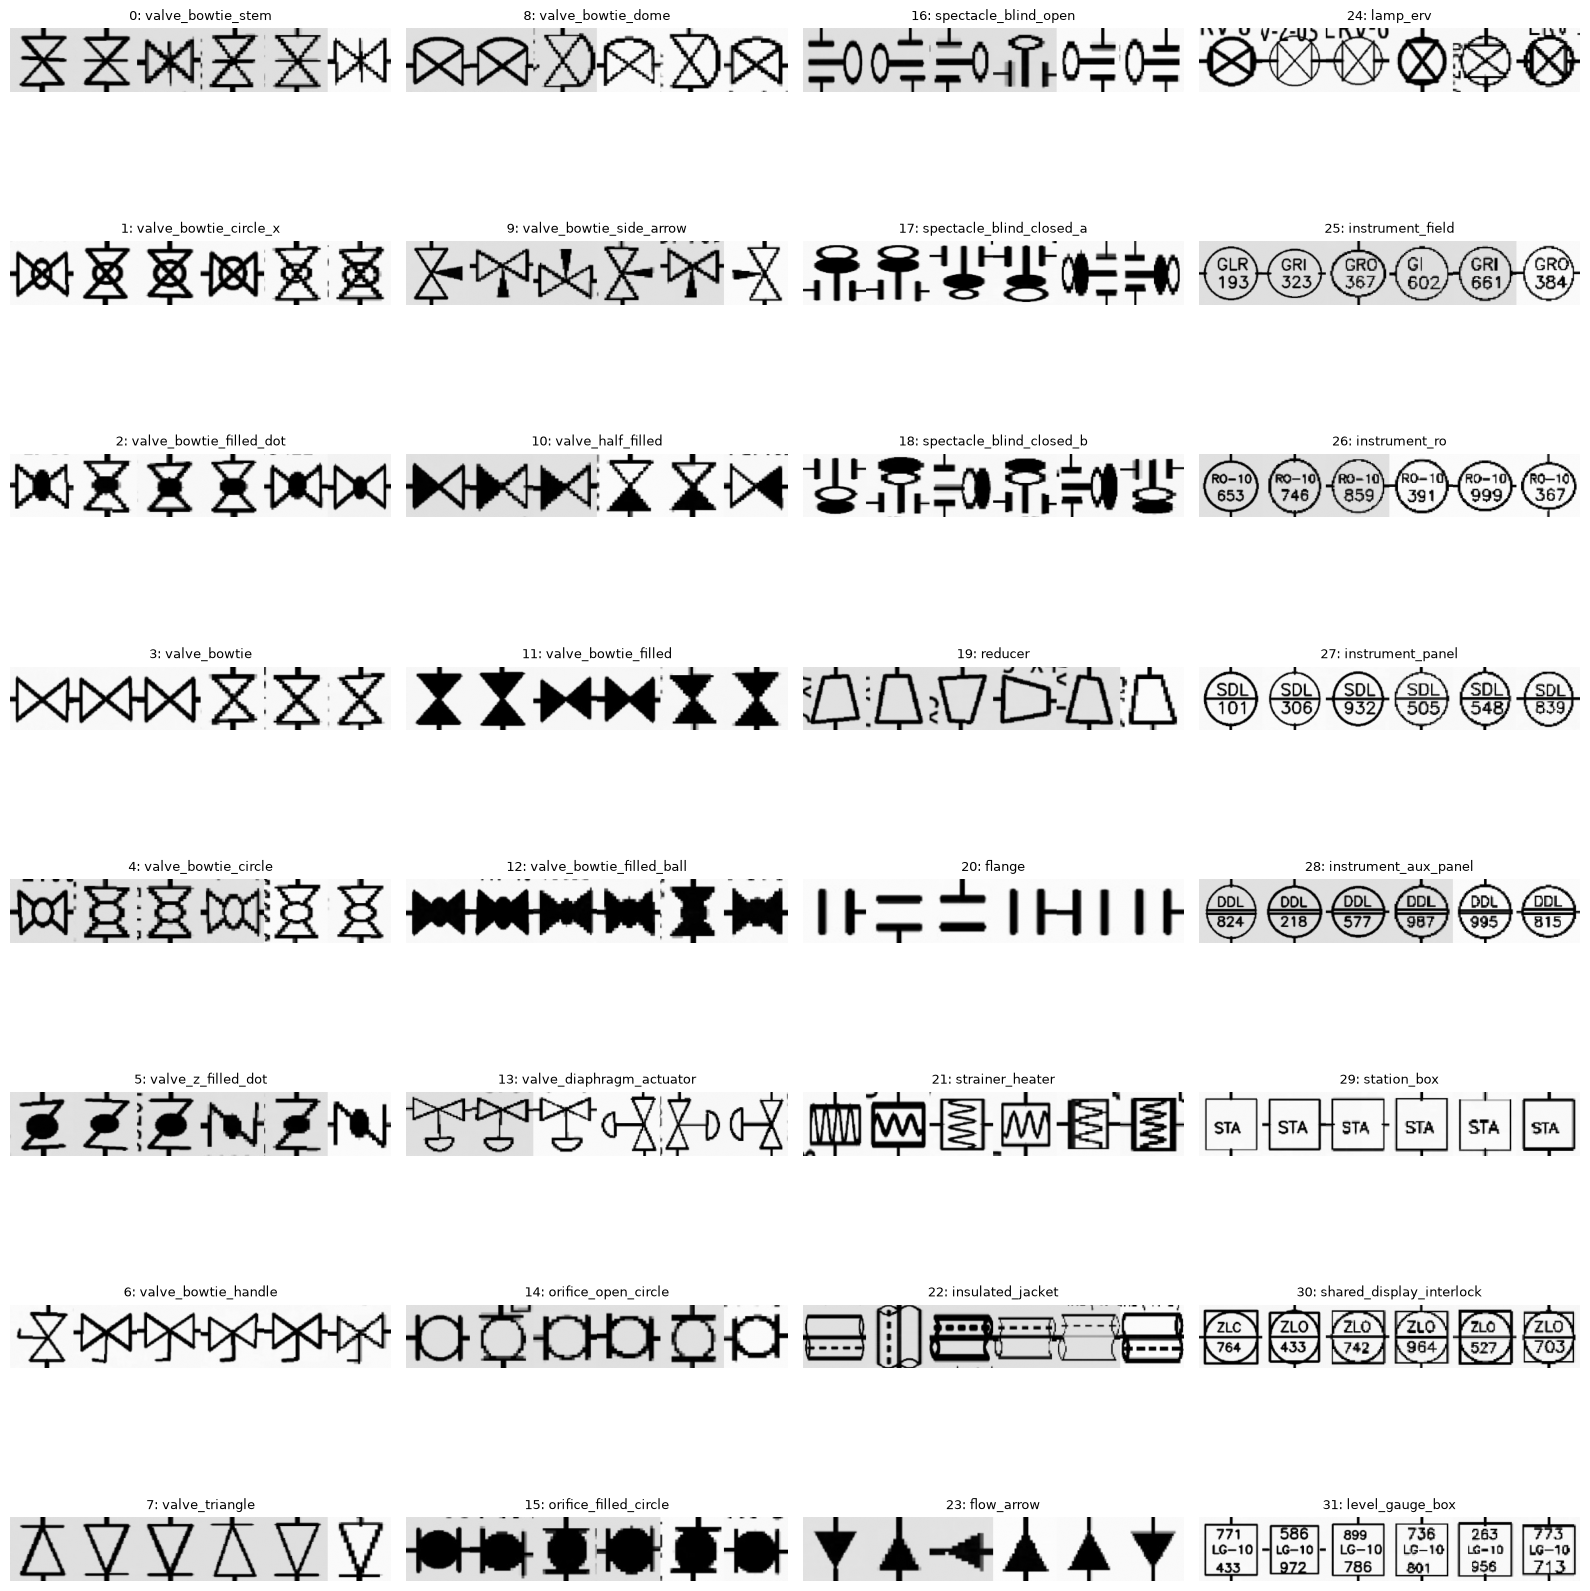

In [4]:
# Montage of a few examples per class
def class_montage(n_per=6, size=96, n_sheets=12):
    ex = defaultdict(list)
    for lp in sorted((DS / "labels/train").glob("*.txt"))[:n_sheets]:
        im = cv2.imread(str(DS / "images/train" / (lp.stem + ".jpg")), cv2.IMREAD_GRAYSCALE)
        b, l = read_yolo(lp, im.shape[1], im.shape[0])
        for (x1, y1, x2, y2), c in zip(b.astype(int), l):
            if len(ex[c]) < n_per:
                ex[c].append(cv2.resize(im[max(0, y1-6):y2+6, max(0, x1-6):x2+6], (size, size)))
    fig, axes = plt.subplots(8, 4, figsize=(16, 18))
    for c, ax in enumerate(axes.T.flatten()):
        row = ex[c] + [np.full((size, size), 255, np.uint8)] * (n_per - len(ex[c]))
        ax.imshow(np.hstack(row), cmap="gray"); ax.set_title(f"{c}: {CLASS_NAMES[c]}", fontsize=9); ax.axis("off")
    plt.tight_layout(); plt.show()
class_montage()

## 2a. Real-world P&IDs from Zenodo → HF/YOLO layout
The Zenodo archive is 6.7 GB; only `PID_Dataset/0__raw_data` (sheets + YOLO labels) is extracted. It also ships the authors'
Siamese-network code and weights, which we don't need. Conversion:
* `train` (72 sheets) → `train`, `test` (20 sheets) → `val`; files are prefixed `z` to avoid name clashes with the synthetic set.
* **Scale normalisation**: real drawings come at very different resolutions (median symbol size 22–950 px). Each sheet is
  resized so its median symbol side is `cfg.target_symbol_px` (the synthetic median), clamped to ×[0.5, 4].
  YOLO coordinates are normalised, so the label files stay valid unchanged.
* Class id `0` (`Symbol`) → `32` (`symbol_unspecified`), and `classes.txt` lists all 33 names, so the folder is a drop-in sibling
  of `DigitizePID_Dataset`.

In [5]:
import zipfile, urllib.request, shutil

def download_zenodo():
    zpath = cfg.zenodo_raw / "PID_Dataset.zip"
    raw = cfg.zenodo_raw / "PID_Dataset" / "0__raw_data"
    if raw.exists(): return raw
    cfg.zenodo_raw.mkdir(parents=True, exist_ok=True)
    if not zpath.exists():
        print("downloading Zenodo PID_Dataset.zip (6.7 GB) ...")
        tmp = zpath.with_suffix(".part")
        with urllib.request.urlopen(cfg.zenodo_url) as r, open(tmp, "wb") as f:
            shutil.copyfileobj(r, f, length=1 << 24)
        tmp.rename(zpath)
    with zipfile.ZipFile(zpath) as z:
        z.extractall(cfg.zenodo_raw, members=[m for m in z.namelist() if m.startswith("PID_Dataset/0__raw_data/")])
    return raw

def convert_zenodo():
    out = cfg.zenodo_dir / "ZenodoPID_Dataset"
    if (out / "classes.txt").exists(): return out
    raw = download_zenodo()
    stats = []
    for src_split, dst_split in (("train", "train"), ("test", "val")):
        (out / "images" / dst_split).mkdir(parents=True, exist_ok=True); (out / "labels" / dst_split).mkdir(parents=True, exist_ok=True)
        for ip in sorted((raw / "sheets" / src_split).glob("*.jpg")):
            lines = [l.split() for l in open(raw / "labels" / src_split / (ip.stem + ".txt")) if len(l.split()) == 5]
            im = cv2.imread(str(ip), cv2.IMREAD_GRAYSCALE); H, W = im.shape
            yolo = np.array([[float(v) for v in l[1:]] for l in lines], np.float32).reshape(-1, 4)
            med = np.median(np.maximum(yolo[:, 2] * W, yolo[:, 3] * H)) if len(yolo) else cfg.target_symbol_px
            f = float(np.clip(cfg.target_symbol_px / med, 0.5, 4.0))
            im = cv2.resize(im, (round(W * f), round(H * f)), interpolation=cv2.INTER_CUBIC if f > 1 else cv2.INTER_AREA)
            cv2.imwrite(str(out / "images" / dst_split / f"z{ip.stem}.jpg"), im, [cv2.IMWRITE_JPEG_QUALITY, 95])
            with open(out / "labels" / dst_split / f"z{ip.stem}.txt", "w") as fo:
                for x, y, w, h in yolo: fo.write(f"{UNSPECIFIED} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")
            stats.append((dst_split, ip.name, W, H, f, len(yolo)))
    (out / "classes.txt").write_text("\n".join(LABEL_NAMES) + "\n")
    json.dump(stats, open(out / "conversion_log.json", "w"), indent=0)
    return out

ZDS = convert_zenodo()
_log = json.load(open(ZDS / "conversion_log.json"))
print(f"Zenodo converted: {sum(r[0]=='train' for r in _log)} train / {sum(r[0]=='val' for r in _log)} val sheets, "
      f"{sum(r[5] for r in _log)} boxes, rescale factors {min(r[4] for r in _log):.2f}..{max(r[4] for r in _log):.2f}")

Zenodo converted: 72 train / 20 val sheets, 4302 boxes, rescale factors 0.50..3.27


## 2c. PID2Graph: the paper's benchmark with ground-truth graphs
[PID2Graph (Zenodo 14803338)](https://zenodo.org/records/14803338) (CC-BY-SA-4.0) was published with the paper. Its `Complete/` plans are used:

| Subset | Plans | Use here |
|---|---|---|
| `Dataset PID` | 500 (the same sheets as the HF dataset) | **ground-truth edges + line types** for our 500 synthetic sheets (relation head training & edge mAP) |
| `PID2Graph Synthetic` | 250 (incl. **tanks and pumps**) | 200 train / 50 val, converted to the YOLO layout (class-free boxes, like Zenodo) |
| `PID2Graph OPEN100` | 12 real plans (OPEN100 nuclear plant: tanks, pumps, inlet/outlet) | **real-world test set**, the paper's headline benchmark; 6 plans double as unlabelled data for self-training |

Each `.graphml` holds symbol nodes (general, valve, instrumentation, arrow, tank, pump, inlet/outlet) with boxes, **connector/crossing nodes**
(line endpoints, bends and junctions) and edges labelled `solid` / `non-solid`. Symbol-to-symbol connections are obtained by walking from
each symbol through connector/crossing nodes until the next symbol. The walk follows bends (2 links) and T-junctions (3 links), but goes
**straight through 4-way crossings**, following P&ID convention that crossing lines without a junction are not connected. A path with any
non-solid segment is `dashed`. `background`
nodes mark unannotated regions (legends, title blocks); predictions there are ignored at evaluation time.

The archive is 9.3 GB, but only the 1.5 GB of `Complete/` files are needed. They sit at the start of the zip, so extraction can begin from a
partial download. Set `cfg.use_pid2graph = False` to skip this section.

In [6]:
import networkx as nx
P2G_URL = "https://zenodo.org/api/records/14803338/files/PID2Graph.zip/content"
P2G_RAW = cfg.root / "data" / "pid2graph"
P2G_COMPLETE = P2G_RAW / "PID2Graph" / "Complete"
P2G_YOLO = cfg.root / "data" / "pid2graph-yolo"
P2G_SYMBOLS = ("general", "valve", "instrumentation", "arrow", "tank", "pump", "inlet/outlet")
USE_PID2GRAPH = getattr(cfg, "use_pid2graph", True)

def download_pid2graph():
    if (P2G_COMPLETE / "PID2Graph OPEN100").exists() and len(list((P2G_COMPLETE / "Dataset PID").glob("*.graphml"))) == 500:
        return
    P2G_RAW.mkdir(parents=True, exist_ok=True); zpath = P2G_RAW / "PID2Graph.zip"
    if not zpath.exists():
        print("downloading PID2Graph.zip (9.3 GB) ...")
        with urllib.request.urlopen(P2G_URL) as r, open(zpath.with_suffix(".part"), "wb") as f: shutil.copyfileobj(r, f, length=1 << 24)
        zpath.with_suffix(".part").rename(zpath)
    with zipfile.ZipFile(zpath) as z:
        z.extractall(P2G_RAW, members=[m for m in z.namelist() if m.startswith("PID2Graph/Complete/")])

def p2g_graph(graphml):
    """-> symbol boxes (N,4), coarse labels [N], edges {(i,j): 'solid'|'dashed'}, background boxes (M,4)."""
    g = nx.read_graphml(str(graphml))
    sym = [n for n, d in g.nodes(data=True) if d.get("label") in P2G_SYMBOLS]
    sid = {n: i for i, n in enumerate(sym)}
    box = lambda d: [float(d["xmin"]), float(d["ymin"]), float(d["xmax"]), float(d["ymax"])]
    boxes = np.array([box(g.nodes[n]) for n in sym], np.float32).reshape(-1, 4)
    labels = [g.nodes[n]["label"] for n in sym]
    bg = np.array([box(d) for _, d in g.nodes(data=True) if d.get("label") == "background"], np.float32).reshape(-1, 4)
    C = {n: np.array([(float(d["xmin"]) + float(d["xmax"])) / 2, (float(d["ymin"]) + float(d["ymax"])) / 2]) for n, d in g.nodes(data=True)}
    edges = {}
    for s in sym:          # walk through connectors / bends / T-junctions; go straight through 4-way crossings
        seen, stack = set(), [(s, None, False)]
        while stack:
            u, prev, dashed = stack.pop()
            nb = list(g.neighbors(u))
            if prev is not None and g.nodes[u].get("label") == "crossing" and len(nb) >= 4:
                d0 = C[u] - C[prev]; d0 = d0 / (np.linalg.norm(d0) + 1e-9)
                cand = [v for v in nb if v != prev]
                nb = [max(cand, key=lambda v: float(np.dot(d0, (C[v] - C[u]) / (np.linalg.norm(C[v] - C[u]) + 1e-9))))]
            for v in nb:
                if v == prev: continue
                d2 = dashed or g.edges[u, v].get("edge_label") == "non-solid"
                if v in sid:
                    a_, b_ = sorted((sid[s], sid[v]))
                    if a_ != b_: edges[(a_, b_)] = "dashed" if (d2 or edges.get((a_, b_)) == "dashed") else "solid"
                elif g.nodes[v].get("label") in ("connector", "crossing") and (v, u) not in seen:
                    seen.add((v, u)); stack.append((v, u, d2))
    return boxes, labels, edges, bg

def convert_p2g_subset(name, out_name, n_val):
    """PID2Graph plans -> YOLO layout (class 32), rescaled to the target symbol size; edges/coarse labels saved alongside."""
    out = P2G_YOLO / out_name
    if (out / "done.json").exists(): return out
    files = sorted((P2G_COMPLETE / name).glob("*.graphml"), key=lambda p: int(p.stem))
    rng = random.Random(0); val = set(rng.sample(range(len(files)), n_val)) if n_val < len(files) else set(range(len(files)))
    for k, gf in enumerate(files):
        split = "val" if k in val else "train"
        (out / "images" / split).mkdir(parents=True, exist_ok=True); (out / "labels" / split).mkdir(parents=True, exist_ok=True)
        ip = [p for p in gf.parent.glob(gf.stem + ".*") if p.suffix != ".graphml"][0]
        boxes, labels, edges, bg = p2g_graph(gf)
        im = cv2.imread(str(ip), cv2.IMREAD_GRAYSCALE); H, W = im.shape
        small = [b for b, l in zip(boxes, labels) if l not in ("tank", "pump")]
        med = np.median([max(b[2] - b[0], b[3] - b[1]) for b in small]) if small else cfg.target_symbol_px
        f = float(np.clip(cfg.target_symbol_px / med, 0.5, 4.0))
        im = cv2.resize(im, (round(W * f), round(H * f)), interpolation=cv2.INTER_CUBIC if f > 1 else cv2.INTER_AREA)
        stem = f"{out_name[:2]}{gf.stem}"
        cv2.imwrite(str(out / "images" / split / f"{stem}.jpg"), im, [cv2.IMWRITE_JPEG_QUALITY, 95])
        with open(out / "labels" / split / f"{stem}.txt", "w") as fo:
            for x1, y1, x2, y2 in boxes:
                fo.write(f"{UNSPECIFIED} {(x1+x2)/2/W:.6f} {(y1+y2)/2/H:.6f} {(x2-x1)/W:.6f} {(y2-y1)/H:.6f}\n")
        json.dump({"coarse": labels, "edges": {f"{a},{b}": st for (a, b), st in edges.items()}, "background": (bg * f).tolist(), "scale": f},
                  open(out / "labels" / split / f"{stem}.graph.json", "w"))
    json.dump({"subset": name}, open(out / "done.json", "w"))
    return out

def p2g_original(s):
    sub = "PID2Graph OPEN100" if s["source"] == "open100" else "PID2Graph Synthetic"
    stem = s["name"][2:-4]
    return [p for p in (P2G_COMPLETE / sub).glob(stem + ".*") if p.suffix != ".graphml"][0], P2G_COMPLETE / sub / f"{stem}.graphml"

if USE_PID2GRAPH:
    download_pid2graph()
    P2G_SYN = convert_p2g_subset("PID2Graph Synthetic", "synthetic", n_val=50)
    P2G_OPEN = convert_p2g_subset("PID2Graph OPEN100", "open100", n_val=12)
    print("PID2Graph converted:", {p.name: {s: len(list((p / "images" / s).glob("*.jpg"))) for s in ("train", "val")} for p in (P2G_SYN, P2G_OPEN)})

PID2Graph converted: {'synthetic': {'train': 200, 'val': 50}, 'open100': {'train': 0, 'val': 12}}


## 2d. Pre-processing (all datasets)
Each sheet is converted once to a grayscale, `input_scale`-resized `uint8` `.npy` file. Training reads **random crops
through `np.load(mmap_mode="r")`**, so every epoch sees new patch positions and scales instead of a fixed set of pre-cut
tiles, and only the needed rows are read from disk. Every index entry records its `source` (`digitize` or `zenodo`).

digitize : 400 train / 100 val sheets, 59498 symbols
zenodo   : 72 train / 20 val sheets, 4302 symbols
p2g_synth: 200 train / 50 val sheets, 5602 symbols
open100  : 0 train / 12 val sheets, 1439 symbols
index built in 0s


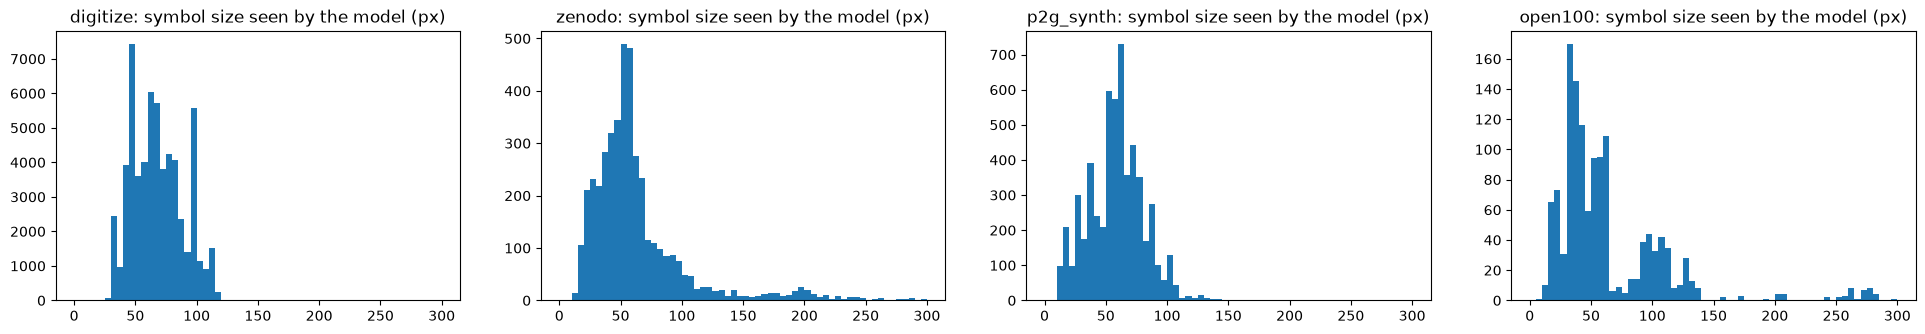

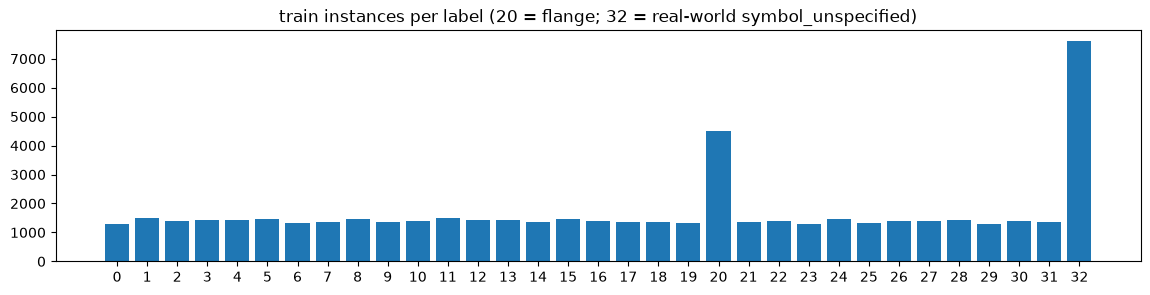

In [7]:
SOURCES = {"digitize": DS, "zenodo": ZDS}
if USE_PID2GRAPH: SOURCES.update({"p2g_synth": P2G_SYN, "open100": P2G_OPEN})

def _prep_one(args):
    source, split, img_path, lbl_path, out_npy, scale = args
    im = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    H, W = im.shape
    if not Path(out_npy).exists():
        small = cv2.resize(im, (round(W*scale), round(H*scale)), interpolation=cv2.INTER_AREA)
        np.save(out_npy, small)
    boxes, labels = read_yolo(lbl_path, W, H)
    return dict(source=source, split=split, name=Path(img_path).name, img_path=img_path, npy=out_npy, W=W, H=H,
                boxes=boxes.tolist(), labels=labels.tolist())

def build_index(scale=cfg.input_scale):
    idx_file = cfg.cache_dir / f"index_s{scale}_{'+'.join(SOURCES)}.json"
    if idx_file.exists():
        return json.load(open(idx_file))
    (cfg.cache_dir / f"sheets_s{scale}").mkdir(parents=True, exist_ok=True)
    jobs = []
    for source, root in SOURCES.items():
        for split in ("train", "val"):
            for ip in sorted((root / "images" / split).glob("*.jpg"), key=lambda p: int(re.sub(r"\D", "", p.stem) or 0)):
                jobs.append((source, split, str(ip), str(root / "labels" / split / (ip.stem + ".txt")),
                             str(cfg.cache_dir / f"sheets_s{scale}" / f"{split}_{ip.stem}.npy"), scale))
    with Pool(min(16, os.cpu_count())) as pool:
        index = pool.map(_prep_one, jobs, chunksize=4)
    json.dump(index, open(idx_file, "w"))
    return index

t0 = time.time()
INDEX = build_index()
TRAIN = [s for s in INDEX if s["split"] == "train"]
VAL = [s for s in INDEX if s["split"] == "val"]
TRAIN = [s for s in TRAIN if s["source"] != "open100"]   # OPEN100 is test-only
VAL_D = [s for s in VAL if s["source"] == "digitize"]     # synthetic, 32 classes
VAL_Z = [s for s in VAL if s["source"] == "zenodo"]       # real-world, class-agnostic
VAL_PS = [s for s in VAL if s["source"] == "p2g_synth"]   # PID2Graph synthetic (tanks/pumps), class-agnostic
TEST_O = [s for s in VAL if s["source"] == "open100"]     # PID2Graph OPEN100 real plans (paper benchmark)
for s in INDEX:   # PID2Graph side info: coarse classes, GT edges, ignore regions
    g = Path(s["img_path"].replace("/images/", "/labels/")).with_suffix(".graph.json")
    if g.exists(): s["p2g"] = json.load(open(g))
for src in SOURCES:
    tr = [s for s in TRAIN if s["source"] == src]; va = [s for s in VAL if s["source"] == src]
    print(f"{src:9s}: {len(tr)} train / {len(va)} val sheets, {sum(len(s['labels']) for s in tr + va)} symbols")
print(f"index built in {time.time()-t0:.0f}s")

fig, ax = plt.subplots(1, len(SOURCES), figsize=(6 * len(SOURCES), 3.5))
for src, a in zip(SOURCES, ax):
    b = np.concatenate([np.array(s["boxes"]).reshape(-1, 4) for s in INDEX if s["source"] == src])
    a.hist(np.maximum(b[:, 2] - b[:, 0], b[:, 3] - b[:, 1]) * cfg.input_scale, bins=60, range=(0, 300))
    a.set_title(f"{src}: symbol size seen by the model (px)")
plt.show()
cnt = Counter(l for s in TRAIN for l in s["labels"])
plt.figure(figsize=(14, 3)); plt.bar(range(33), [cnt[i] for i in range(33)]); plt.xticks(range(33))
plt.title("train instances per label (20 = flange; 32 = real-world symbol_unspecified)"); plt.show()

## 3. Extra labels from Claude Sonnet 5.5 (tag names + pipe connections)

The HF dataset has symbol boxes only. The paper's relation head needs **edges**, and the final JSON needs **tag names**.
We get both with **set-of-marks prompting**: each symbol box is drawn on a native-resolution crop together with a numeric ID,
and Claude returns, as JSON constrained by a schema, (a) the tag text that belongs to each ID and (b) which IDs are joined by
a pipe/signal line. Crops (2048² native px, 512 px overlap) keep the text legible; results are merged across crops by voting.

* The same function runs at inference on *detected* boxes (§8) to refine tags/connections.
* Responses are cached on disk (`data/cache/claude/`), so re-running is free and interrupted runs resume.
* Cost control: `cfg.claude_label_train_sheets` / `cfg.claude_label_val_sheets`. Token usage and estimated cost are printed
  (Sonnet 5.5: $2 / $10 per M input/output tokens). Roughly 15 crops per sheet.
* Server-side refusal fallback (`fallbacks="default"`) is enabled so a rare safety decline is retried on another model automatically.
* Credentials: `ANTHROPIC_API_KEY` env var (or an `ant auth login` profile). Without credentials this section is skipped and
  the relation head is simply not trained (the detector is unaffected).

Note: these are **pseudo-labels**. Edge metrics computed against them measure agreement with Claude, not true ground truth.
For true line/text ground truth, the original Digitize-PID release (Google Drive link in the HF card) also has line and word annotations.

In [8]:
import anthropic

CLAUDE_DIR = cfg.cache_dir / "claude"; CLAUDE_DIR.mkdir(parents=True, exist_ok=True)
USAGE = Counter()

def claude_available():
    try:
        anthropic.Anthropic().models.retrieve(cfg.claude_model)
        return True
    except Exception as e:
        print("Claude not available ->", type(e).__name__, str(e)[:200])
        return False

SOM_SCHEMA = {
    "type": "object",
    "properties": {
        "symbols": {"type": "array", "items": {
            "type": "object",
            "properties": {"id": {"type": "integer"},
                           "tag": {"type": "string", "description": "tag text for this symbol, '' if none is visible"}},
            "required": ["id", "tag"], "additionalProperties": False}},
        "connections": {"type": "array", "items": {
            "type": "object",
            "properties": {"a": {"type": "integer"}, "b": {"type": "integer"},
                           "style": {"type": "string", "enum": ["solid", "dashed"]}},
            "required": ["a", "b", "style"], "additionalProperties": False}},
    },
    "required": ["symbols", "connections"], "additionalProperties": False,
}

SOM_PROMPT = """This image is a crop of a Piping & Instrumentation Diagram (P&ID). Every detected symbol is outlined with a red box and labelled with a red numeric ID on a white background.

Symbols in this crop (ID: symbol type):
{legend}

Tasks:
1. For each ID, give the equipment tag text that belongs to that symbol: either text written inside the symbol (instrument bubbles like "GLR / 193" -> "GLR-193", "SDL / 101" -> "SDL-101") or the tag label printed right next to it (e.g. "WX-71994", "CS-08", "ERV-8-20"; labels may be rotated 90 degrees). Do not use pipe line numbers such as 4"-JO-9505 or pipe sizes like 12" as tags. Use '' if no tag belongs to the symbol.
2. List the pipe/signal connections between IDs: two IDs are connected when a drawn line path (following bends and T-junctions, solid or dashed) runs from one symbol to the other without passing through another numbered symbol. Report each pair once. Only use IDs listed above; ignore lines that leave the crop.

Answer with JSON only."""

def _draw_som(gray_crop, boxes_local, ids, scale_out):
    """Draw numbered boxes on a crop, then resize by scale_out. Returns RGB uint8."""
    img = cv2.cvtColor(gray_crop, cv2.COLOR_GRAY2BGR)
    img = cv2.resize(img, None, fx=scale_out, fy=scale_out, interpolation=cv2.INTER_AREA)
    for (x1, y1, x2, y2), i in zip((boxes_local * scale_out).astype(int), ids):
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
        txt = str(i); (tw, th), _ = cv2.getTextSize(txt, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2)
        tx, ty = x1, max(th + 2, y1 - 3)
        cv2.rectangle(img, (tx, ty - th - 2), (tx + tw + 2, ty + 2), (255, 255, 255), -1)
        cv2.putText(img, txt, (tx + 1, ty), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 255), 2)
    return img

def som_windows(W, H, tile=None, overlap=None):
    tile = tile or cfg.claude_tile; stride = tile - (overlap or cfg.claude_overlap)
    xs = list(range(0, max(W - tile, 0) + 1, stride)); ys = list(range(0, max(H - tile, 0) + 1, stride))
    if xs[-1] + tile < W: xs.append(W - tile)
    if ys[-1] + tile < H: ys.append(H - tile)
    return [(x, y, min(x + tile, W), min(y + tile, H)) for y in ys for x in xs]

def claude_json(png_bytes, prompt, schema):
    """One image + prompt -> JSON constrained by `schema` (Claude API). §12 provides the same call for Azure / Bedrock models."""
    client = anthropic.Anthropic(max_retries=4)
    resp = client.beta.messages.create(
        model=cfg.claude_model,
        max_tokens=16000,
        betas=["server-side-fallback-2026-07-01"],
        fallbacks="default",
        output_config={"effort": cfg.claude_effort, "format": {"type": "json_schema", "schema": schema}},
        messages=[{"role": "user", "content": [
            {"type": "image", "source": {"type": "base64", "media_type": "image/png",
                                         "data": base64.standard_b64encode(png_bytes).decode()}},
            {"type": "text", "text": prompt},
        ]}],
    )
    USAGE["input"] += resp.usage.input_tokens; USAGE["output"] += resp.usage.output_tokens; USAGE["calls"] += 1
    if resp.stop_reason in ("refusal", "max_tokens"):
        raise RuntimeError(f"stop_reason={resp.stop_reason}")
    text = next(b.text for b in resp.content if b.type == "text")
    return json.loads(text)

def claude_som_call(png_bytes, legend, json_fn=None):
    return (json_fn or claude_json)(png_bytes, SOM_PROMPT.format(legend=legend), SOM_SCHEMA)

def claude_label_sheet(img_path, boxes, labels, cache_key, min_box_frac=0.6, json_fn=None):
    """Set-of-marks labelling of one sheet. boxes: (N,4) native xyxy. Returns {'tags': {id: tag}, 'edges': [(a,b,style,votes)]}."""
    out_file = CLAUDE_DIR / f"{cache_key}.json"
    if out_file.exists():
        return json.load(open(out_file))
    im = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE); H, W = im.shape
    boxes = np.asarray(boxes, np.float32).reshape(-1, 4)
    jobs = []
    for (x0, y0, x1, y1) in som_windows(W, H):
        ix1 = np.clip(boxes[:, 0], x0, x1); iy1 = np.clip(boxes[:, 1], y0, y1)
        ix2 = np.clip(boxes[:, 2], x0, x1); iy2 = np.clip(boxes[:, 3], y0, y1)
        frac = (ix2 - ix1) * (iy2 - iy1) / np.maximum((boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]), 1)
        sel = np.where(frac >= min_box_frac)[0]
        if len(sel) == 0: continue
        local = boxes[sel] - np.array([x0, y0, x0, y0], np.float32)
        img = _draw_som(im[y0:y1, x0:x1], local, sel, scale_out=min(1.0, 1568 / max(x1 - x0, y1 - y0)))
        png = cv2.imencode(".png", img)[1].tobytes()
        legend = "\n".join(f"{i}: {labels[i] if isinstance(labels[i], str) else LABEL_NAMES[labels[i]]}" for i in sel)
        jobs.append((png, legend, set(sel.tolist())))
    tag_votes, edge_votes = defaultdict(Counter), Counter()
    with ThreadPoolExecutor(cfg.claude_workers) as ex:
        futs = {ex.submit(claude_som_call, png, legend, json_fn): ids for png, legend, ids in jobs}
        for f in as_completed(futs):
            ids = futs[f]
            try:
                r = f.result()
            except Exception as e:
                print("  crop failed:", type(e).__name__, str(e)[:120]); continue
            for s in r["symbols"]:
                if s["id"] in ids and s["tag"].strip():
                    tag_votes[s["id"]][s["tag"].strip().upper()] += 1
            for c in r["connections"]:
                a, b = int(c["a"]), int(c["b"])
                if a != b and a in ids and b in ids:
                    edge_votes[(min(a, b), max(a, b), c["style"])] += 1
    res = {"tags": {str(i): v.most_common(1)[0][0] for i, v in tag_votes.items()},
           "edges": [[a, b, st, n] for (a, b, st), n in edge_votes.items()]}
    json.dump(res, open(out_file, "w"))
    return res

def usage_report():
    cost = USAGE["input"] / 1e6 * 2 + USAGE["output"] / 1e6 * 10
    print(f"Claude calls={USAGE['calls']} in={USAGE['input']:,} out={USAGE['output']:,} tokens  ~${cost:.2f}")

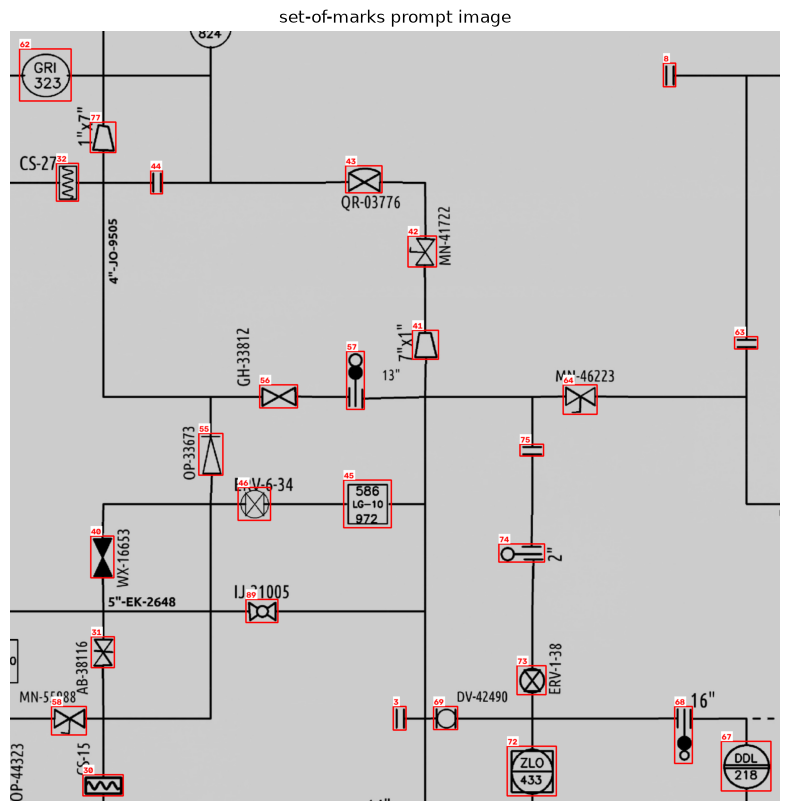

In [9]:
# Preview of a set-of-marks crop (no API call)
_s = TRAIN[0]
_im = cv2.imread(_s["img_path"], cv2.IMREAD_GRAYSCALE)
_b = np.array(_s["boxes"], np.float32); _win = som_windows(_s["W"], _s["H"])[6]
_in = np.where((_b[:, 0] >= _win[0]) & (_b[:, 2] <= _win[2]) & (_b[:, 1] >= _win[1]) & (_b[:, 3] <= _win[3]))[0]
_prev = _draw_som(_im[_win[1]:_win[3], _win[0]:_win[2]], _b[_in] - np.array(_win[:2] * 2, np.float32), _in, 1568 / cfg.claude_tile)
plt.figure(figsize=(10, 10)); plt.imshow(_prev[..., ::-1]); plt.axis("off"); plt.title("set-of-marks prompt image"); plt.show()

In [10]:
CLAUDE_OK = claude_available()
CLAUDE_LABELS = {}   # sheet key -> {'tags':..., 'edges':...}
if CLAUDE_OK:
    todo = TRAIN[:cfg.claude_label_train_sheets] + VAL[:cfg.claude_label_val_sheets]
    print(f"labelling {len(todo)} sheets with {cfg.claude_model} ...")
    for k, s in enumerate(todo):
        key = f"gt_{s['split']}_{Path(s['name']).stem}"
        CLAUDE_LABELS[(s["split"], s["name"])] = claude_label_sheet(s["img_path"], s["boxes"], s["labels"], key)
        if k % 10 == 0: print(f"  {k+1}/{len(todo)}", end=" "); usage_report()
    usage_report()
else:
    # still pick up anything cached from a previous run
    for s in INDEX:
        f = CLAUDE_DIR / f"gt_{s['split']}_{Path(s['name']).stem}.json"
        if f.exists(): CLAUDE_LABELS[(s["split"], s["name"])] = json.load(open(f))
print("sheets with Claude labels:", len(CLAUDE_LABELS))

Claude not available -> TypeError "Could not resolve authentication method. Expected one of api_key, auth_token, or credentials to be set. Or for one of the `X-Api-Key` or `Authorization` headers to be explicitly omitted"
sheets with Claude labels: 0


## 3b. Line tracing and edge labels (solid / dashed)

**Connectivity from the drawn lines.** Two symbols are connected when a drawn line runs between them. `trace_lines()` reads the lines
directly with OpenCV morphology and a scikit-image skeleton. It is the main connection source of `digitize()`; the relation head (§5)
re-ranks its edges and adds a few that it misses. §9c shows why this split works best.

```
ink ─► erase symbol boxes ─► close gaps between collinear line pieces (dashes, lines broken at a crossing) ─► drop text ─► skeleton
    ─► cut the skeleton at junction pixels into segments (two ends each)
    ─► junctions by branch geometry:   ┼ two straight pairs = crossing, not connected   ·   ┬ ┐ ┼● (bend, T, dotted 4-way) = joint
    ─► free ends: collinear / L-corner bridges (dashed lines), T snaps; a pipe drawn straight across a long symbol (wall) passes through
    ─► union-find over segment ends → nets; symbols on a net are connected; touching symbol boxes are connected ("adjacency")
```

Why not plain contours? `cv2.findContours` / connected components merge every line that touches another one, including lines that only
**cross**. On a P&ID that joins most of the sheet into one network. The tracer instead works on the skeleton, where a crossing is a
junction with four branches in two straight pairs. Those pairs continue straight through and are not connected to each other, which is
the convention PID2Graph uses for its ground truth (§2c).

**Line type.** Dashed lines are recognised from the gaps that step 2 had to fill: a segment at least one symbol long with several filled gaps is
dashed (shorter ones are usually text such as `INS (-33°C)` beside a symbol, §9e). A symbol pair
is dashed when either symbol attaches through a dashed segment, or when most of the net is dashed. This matches the ground truth, where a
path with any non-solid part is dashed.

**Scores.** Every pair on a net gets `score = 1 / (1 + 0.15·(n − 2))` for a net with *n* symbols: a large header is less certain per pair.
Touching boxes get 0.7 (overlap) / 0.45 (≤ 0.1 symbol gaps) / 0.2 (≤ 0.4). §8b fuses this with the relation head and the detection confidences.

**Edge labels for the relation head.** The relation head is trained on undirected symbol-to-symbol edges with a **line type**: solid or
non-solid (dashed), the paper's two edge classes. Each sheet takes its labels from the best available source:
1. **PID2Graph ground truth** (§2c): true graphs published with the paper. These cover all 500 Digitize-PID sheets (matched to the HF
   images by thumbnail similarity and box IoU) and the converted PID2Graph Synthetic / OPEN100 plans.
2. **Claude set-of-marks labels** (§3), when an API key is configured.
3. **Line-trace pseudo-labels**, free and available for every sheet: the tracer runs on the *ground-truth* symbol boxes; pairs on nets with
   ≤ 6 symbols and overlapping boxes become edges (score ≥ 0.6).


In [11]:
from skimage.morphology import skeletonize

_K8 = np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1]], np.float32)

def _binarize(gray):
    t, _ = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return (gray < np.clip(t, 100, 200)).astype(np.uint8)

def _erase_text(ink, texts, sym_px, lw, sym_map):
    """Drop text: components inside OCR boxes, and character-like blobs (small, not elongated; dashes are elongated).
    A blob touching two different symbols is a short pipe stub between them and is kept."""
    n, lab, st, _ = cv2.connectedComponentsWithStats(ink, connectivity=8)
    w, h = st[:, 2], st[:, 3]; mx, mn = np.maximum(w, h), np.maximum(np.minimum(w, h), 1)
    drop = ((mx < 0.55 * sym_px) & (mx < 3 * mn) & (mx > 2.5 * lw) & (st[:, 4] < 0.6 * w * h)) | \
           ((mx < 0.35 * sym_px) & (mx < 2.2 * mn) & (mx > 2.5 * lw))
    if texts:
        tb = np.array([t["box"] for t in texts], np.float32).reshape(-1, 4)
        drop |= ((st[:, None, 0] >= tb[None, :, 0] - 2) & (st[:, None, 1] >= tb[None, :, 1] - 2) &
                 (st[:, None, 0] + w[:, None] <= tb[None, :, 2] + 2) & (st[:, None, 1] + h[:, None] <= tb[None, :, 3] + 2)).any(1)
    drop[0] = False
    yy, xx = np.nonzero(drop[lab])
    if len(yy):   # largest / smallest symbol id within 2 px of each dropped pixel; they differ -> blob touches two symbols
        k5 = np.ones((5, 5), np.uint8)
        hi = cv2.dilate(sym_map.astype(np.float32), k5)[yy, xx]
        lo = -cv2.dilate(np.where(sym_map >= 0, -sym_map, -1e9).astype(np.float32), k5)[yy, xx]
        l_, ok = lab[yy, xx], (hi >= 0) & (lo < 1e8)
        bmax = np.full(n, -1.0); np.maximum.at(bmax, l_[ok], hi[ok])
        bmin = np.full(n, 1e9); np.minimum.at(bmin, l_[ok], lo[ok])
        drop &= ~((bmax >= 0) & (bmin < 1e8) & (bmax != bmin))
    return ink * (~drop[lab]).astype(np.uint8)

def trace_lines(gray, boxes, texts=None, sym_px=None, touch=0.4, crossing_angle=25, frame_frac=0.85, passthru=3.0, return_maps=False):
    """Crossing-aware skeleton line tracer (OpenCV + scikit-image). Symbol-to-symbol connectivity from the drawn lines.
    1. Binarise; erase the symbol boxes (lines now *end* at symbol borders).
    2. Gap closing between collinear horizontal / vertical line pieces: dashed lines and lines broken at a crossing become
       continuous (filled pixels are remembered, so dashed segments can be recognised). Then text and specks are removed.
    3. Skeletonise and cut the skeleton at junction pixels into simple segments (each segment has two ends).
    4. Junctions are classified from their branch directions: 2 branches = bend, 3 = T joint (all connected),
       4 branches forming two straight pairs = **crossing** (only the straight pairs continue) unless a filled junction dot is drawn.
    5. Free segment ends: bridged to a collinear end facing back (dashes, broken crossings) or around an L corner, else snapped onto
       a line or symbol just ahead (T joint drawn with a small gap). Pipes drawn straight across a long symbol (wall) pass through.
    6. Union-find over segment ends gives **nets**; every symbol whose box (plus a small ring) holds a segment end joins that net.
       Symbols on one net are connected (as in the PID2Graph contraction through connectors / T-junctions).
    Pixel thresholds scale with the median symbol size `sym_px` and the measured line width.
    Returns {"nets": [{"members", "dashed" (per member), "dfrac", "score"}], "adjacent": {(i, j): score}, "stats": {...}}
    (+ "maps" for plotting: skeleton pixels labelled by net, crossing centres, filled gap pixels, when return_maps=True)."""
    H, W = gray.shape
    B = np.asarray(boxes, np.float32).reshape(-1, 4)
    if sym_px is None:
        sym_px = float(np.median(np.maximum(B[:, 2] - B[:, 0], B[:, 3] - B[:, 1]))) if len(B) else 40.0
    raw = _binarize(gray); ink = raw.copy()
    dt = cv2.distanceTransform(ink, cv2.DIST_L2, 3); v_ = dt[skeletonize(ink > 0)]
    lw = float(max(1.0, 2 * np.median(v_) - 1)) if len(v_) else 2.0          # stroke width
    dg = max(4 * lw, 0.35 * sym_px)            # dash gap
    cg = max(6 * lw, 0.45 * sym_px)            # gap of a line broken at a crossing
    sn = max(2 * lw + 2, 0.12 * sym_px)        # T joint drawn with a small gap
    att = max(2.0, 1.5 * lw + 1, 0.2 * sym_px) # line end -> symbol attachment ring
    # ---- 1. symbols ----
    sym_map = np.full((H, W), -1, np.int32)
    for i in np.argsort(-(B[:, 2] - B[:, 0]) * (B[:, 3] - B[:, 1])):    # small boxes last: they win overlaps
        x1, y1, x2, y2 = B[i]
        sym_map[max(0, int(y1)):int(np.ceil(y2)) + 1, max(0, int(x1)):int(np.ceil(x2)) + 1] = i
    ink[sym_map >= 0] = 0
    n, lab, st, _ = cv2.connectedComponentsWithStats(ink, connectivity=8)
    small = np.maximum(st[:, 2], st[:, 3]) < max(3, 1.5 * lw); small[0] = False
    ink[small[lab]] = 0
    # ---- 2. gap closing along x and y between line pieces longer than the stroke width ----
    Lp, g_ = max(3, int(round(2 * lw + 1))), max(3, int(round(dg)))
    rect = lambda w, h: cv2.getStructuringElement(cv2.MORPH_RECT, (w, h))
    fill = np.zeros_like(ink)
    for kp, kg in (((Lp, 1), (g_, 1)), ((1, Lp), (1, g_))):
        fill |= cv2.morphologyEx(cv2.morphologyEx(ink, cv2.MORPH_OPEN, rect(*kp)), cv2.MORPH_CLOSE, rect(*kg)) & (1 - ink)
    fill[sym_map >= 0] = 0
    ink = _erase_text(ink | fill, texts, sym_px, lw, sym_map)
    fill &= ink
    # ---- 3. skeleton segments and their ends ----
    sk = skeletonize(ink > 0).astype(np.uint8)
    jpx = ((cv2.filter2D(sk, cv2.CV_8U, _K8, borderType=cv2.BORDER_CONSTANT) * sk) >= 3).astype(np.uint8)
    rj = max(1, int(round(lw)))
    jzone = cv2.dilate(jpx, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * rj + 1, 2 * rj + 1))) & sk
    nj, jlab = cv2.connectedComponents(cv2.dilate(jzone, np.ones((3, 3), np.uint8)), connectivity=8)
    seg = sk & (1 - jzone)
    ns, slab, sst, _ = cv2.connectedComponentsWithStats(seg, connectivity=8)
    ey, ex = np.nonzero(((cv2.filter2D(seg, cv2.CV_8U, _K8, borderType=cv2.BORDER_CONSTANT) * seg) <= 1) & (seg > 0))
    eseg, n_end = slab[ey, ex], len(ey)
    ends_of = defaultdict(list)
    for k, s in enumerate(eseg): ends_of[int(s)].append(k)
    L = max(4, int(round(3 * lw + 2)))
    dirs = np.zeros((n_end, 2), np.float32)        # outward direction of each end
    for k in range(n_end):
        y, x = ey[k], ex[k]
        y0, x0 = max(0, y - L), max(0, x - L)
        yy, xx = np.nonzero(slab[y0:y + L + 1, x0:x + L + 1] == eseg[k])
        v = np.array([x - (xx + x0).mean(), y - (yy + y0).mean()], np.float32); nv = np.linalg.norm(v)
        dirs[k] = v / nv if nv > 0 else 0
    seg_len = sst[:, 4].astype(np.float32)
    on_fill = (seg & (cv2.dilate(fill, np.ones((3, 3), np.uint8)) > 0)).astype(np.uint8)
    fy, fx = np.nonzero(on_fill)
    seg_fill = np.bincount(slab[fy, fx], minlength=ns).astype(np.float32)
    nf, flab = cv2.connectedComponents(on_fill, connectivity=8)
    seg_gaps = np.zeros(ns, np.int32)
    if nf > 1:
        pr = np.unique(np.stack([flab[fy, fx], slab[fy, fx]], 1), axis=0); np.add.at(seg_gaps, pr[:, 1], 1)
    seg_dashed = (seg_gaps >= 2) & (seg_fill >= 0.15 * seg_len)       # several filled gaps along the segment
    seg_dashed &= seg_len >= sym_px          # dashed lines are long; short gap-closed pieces are text beside a symbol (§9e)
    ejun = cv2.dilate(jlab.astype(np.float32), np.ones((3, 3), np.uint8)).astype(np.int32)[ey, ex]
    # nearest symbol id for pixels in the attachment ring
    ring = cv2.dilate((sym_map >= 0).astype(np.uint8), cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * int(att) + 1,) * 2))
    sym_near = sym_map.copy()
    if len(B):
        _, lbl = cv2.distanceTransformWithLabels((sym_map < 0).astype(np.uint8), cv2.DIST_L2, 3, labelType=cv2.DIST_LABEL_PIXEL)
        zy, zx = np.nonzero(sym_map >= 0); lut = np.full(lbl.max() + 1, -1, np.int32); lut[lbl[zy, zx]] = sym_map[zy, zx]
        rg = (ring > 0) & (sym_map < 0); sym_near[rg] = lut[lbl[rg]]
    # ---- 4. junctions ----
    parent = np.arange(n_end + nj + 1); J0 = n_end
    def find(a):
        r = a
        while parent[r] != r: r = parent[r]
        while parent[a] != r: parent[a], a = r, parent[a]
        return r
    def union(a, b): parent[find(a)] = find(b)
    for ks in ends_of.values():
        for k in ks[1:]: union(ks[0], k)
    spur_len = max(3 * lw, 0.18 * sym_px)
    is_spur = np.zeros(ns, bool)                  # arrow tips, hatch marks, text remnants hanging off a line
    for s, ks in ends_of.items():
        nfree = sum(ejun[k] == 0 and sym_near[ey[k], ex[k]] < 0 for k in ks)
        if len(ks) == 2 and nfree == 1 and seg_len[s] < spur_len and (ejun[ks[0]] or ejun[ks[1]]): is_spur[s] = True
    branches = defaultdict(list)
    for k in range(n_end):
        if ejun[k] and not is_spur[eseg[k]]: branches[int(ejun[k])].append(k)
    if nj > 1:
        jy, jx = np.nonzero(jzone); jj = jlab[jy, jx]; cnt = np.maximum(np.bincount(jj, minlength=nj), 1)
        cx, cy = np.bincount(jj, weights=jx, minlength=nj) / cnt, np.bincount(jj, weights=jy, minlength=nj) / cnt
    cos_thr, jkind = np.cos(np.deg2rad(crossing_angle)), {}
    for j, ks in branches.items():
        if len(ks) == 4:
            d = -dirs[ks]; c = d @ d.T; pairs, used = [], set()
            for a, b in sorted(((a, b) for a in range(4) for b in range(a + 1, 4)), key=lambda ab: c[ab]):
                if a not in used and b not in used: pairs.append((a, b)); used |= {a, b}
            r_ = int(round(2.2 * lw + 1)); patch = raw[max(0, int(cy[j]) - r_):int(cy[j]) + r_ + 1, max(0, int(cx[j]) - r_):int(cx[j]) + r_ + 1]
            dot = patch.size > 0 and patch.mean() > 0.62
            if all(c[a, b] < -cos_thr for a, b in pairs) and not dot:
                for a, b in pairs: union(ks[a], ks[b])
                jkind[j] = "crossing"; continue
        for k in ks: union(k, J0 + j)
        jkind[j] = "joint"
    # ---- 5. free ends: collinear / corner bridges, then T snaps ----
    free = np.array([k for k in range(n_end) if ejun[k] == 0 and sym_near[ey[k], ex[k]] < 0 and not is_spur[eseg[k]]], np.int64)
    P = np.stack([ex, ey], 1).astype(np.float32)
    bridges = []
    if len(free):
        Pf, Df = P[free], dirs[free]; maxg = max(dg, cg)
        gx, gy = (Pf[:, 0] // maxg).astype(int), (Pf[:, 1] // maxg).astype(int)
        grid = defaultdict(list)
        for i, cell in enumerate(zip(gx, gy)): grid[cell].append(i)
        cand = []
        for i in range(len(free)):
            for ax in (-1, 0, 1):
                for ay in (-1, 0, 1):
                    for j in grid.get((gx[i] + ax, gy[i] + ay), ()):
                        if j <= i or eseg[free[i]] == eseg[free[j]]: continue
                        v = Pf[j] - Pf[i]; dist = float(np.hypot(*v))
                        if dist > maxg or dist < 0.5: continue
                        u, dd = v / dist, float(Df[i] @ Df[j])
                        if Df[i] @ u > 0.9 and -Df[j] @ u > 0.9 and dd < -0.9 and abs(Df[i, 0] * v[1] - Df[i, 1] * v[0]) < max(1.5, 0.8 * lw):
                            cand.append((dist, i, j))                         # collinear, facing each other
                        elif abs(dd) < 0.35 and dist <= 1.5 * dg:             # L corner with the gap at the corner
                            det = -Df[i, 0] * Df[j, 1] + Df[i, 1] * Df[j, 0]
                            if abs(det) < 1e-3: continue
                            ti = (-v[0] * Df[j, 1] + v[1] * Df[j, 0]) / det; tj = (Df[i, 0] * v[1] - Df[i, 1] * v[0]) / det
                            if -lw <= ti <= dg and -lw <= tj <= dg: cand.append((dist + 0.5, i, j))
        taken = set()
        for dist, i, j in sorted(cand):
            if i in taken or j in taken: continue
            straight = float(Df[i] @ Df[j]) < -0.9
            m_ = max(2, int(dist))
            xs = np.linspace(Pf[i, 0], Pf[j, 0], m_)[1:-1].round().astype(int); ys = np.linspace(Pf[i, 1], Pf[j, 1], m_)[1:-1].round().astype(int)
            across = straight and len(xs) > 0 and bool(sk[ys, xs].any())      # another line lies in the gap -> broken crossing
            if (across and dist <= cg) or (not across and dist <= (dg if straight else 1.5 * dg)):
                union(free[i], free[j]); taken |= {i, j}; bridges.append((free[i], free[j], "cross" if across else "dash"))
        for i in range(len(free)):
            if i in taken: continue
            k = free[i]; reach = dg if seg_dashed[eseg[k]] else sn      # dashed lines stop a dash gap short of the line they join
            for t in np.arange(1, reach + max(0.4 * sym_px, reach) + 1):
                x, y = int(round(P[k, 0] + Df[i, 0] * t)), int(round(P[k, 1] + Df[i, 1] * t))
                if not (0 <= x < W and 0 <= y < H): break
                if sym_map[y, x] >= 0: sym_near[ey[k], ex[k]] = sym_map[y, x]; break     # line pointing at a symbol
                if t > reach: continue
                s2, j2 = slab[y, x], jlab[y, x]
                if s2 and s2 != eseg[k] and not is_spur[s2]:
                    if ends_of.get(int(s2)): union(k, ends_of[int(s2)][0])
                    break
                if j2 and jkind.get(int(j2)) == "joint": union(k, J0 + int(j2)); break
    # pipes drawn straight across a long symbol (wall, building outline): continuous ink from one side to the other
    passed = set()
    long_ = np.maximum(B[:, 2] - B[:, 0], B[:, 3] - B[:, 1]) >= passthru * sym_px if len(B) else np.zeros(0, bool)
    if long_.any():
        by_sym = defaultdict(list)
        for k in range(n_end):
            s_id = sym_near[ey[k], ex[k]]
            if s_id >= 0 and long_[s_id] and not is_spur[eseg[k]]: by_sym[int(s_id)].append(k)
        for ks in by_sym.values():
            for a_ in range(len(ks)):
                for b_ in range(a_ + 1, len(ks)):
                    ka, kb = ks[a_], ks[b_]
                    if ka in passed or kb in passed: continue
                    v = P[kb] - P[ka]; dist = float(np.hypot(*v))
                    if dist < 2: continue
                    al = sorted((float(dirs[ka] @ v) / dist, float(-dirs[kb] @ v) / dist))
                    if al[0] < 0.8 or al[1] < 0.95: continue
                    xs = np.linspace(P[ka, 0], P[kb, 0], int(dist)).round().astype(int); ys = np.linspace(P[ka, 1], P[kb, 1], int(dist)).round().astype(int)
                    near = raw[ys, xs].copy()
                    for dy, dx in ((1, 0), (-1, 0), (0, 1), (0, -1)): near |= raw[np.clip(ys + dy, 0, H - 1), np.clip(xs + dx, 0, W - 1)]
                    if near.mean() > 0.97: union(ka, kb); passed |= {ka, kb}; bridges.append((ka, kb, "pass"))
    for a, b, kind in bridges:                  # endpoint bridges between short pieces are dashes too
        if kind == "dash":
            for k in (a, b):
                if seg_len[eseg[k]] < 3 * dg: seg_dashed[eseg[k]] = True
    # ---- 6. nets ----
    net_syms = defaultdict(dict)                # root -> {symbol: attached through a dashed segment?}
    for k in range(n_end):
        s_id = sym_near[ey[k], ex[k]]
        if s_id >= 0 and not is_spur[eseg[k]] and k not in passed:
            r = find(k); net_syms[r][int(s_id)] = net_syms[r].get(int(s_id), False) | bool(seg_dashed[eseg[k]])
    net_len, net_dlen, net_box = defaultdict(float), defaultdict(float), {}
    for s, ks in ends_of.items():
        if is_spur[s]: continue
        r = find(ks[0]); net_len[r] += seg_len[s]; net_dlen[r] += seg_len[s] * seg_dashed[s]
        x, y, w, h = sst[s, :4]; b = net_box.get(r, (x, y, x + w, y + h))
        net_box[r] = (min(b[0], x), min(b[1], y), max(b[2], x + w), max(b[3], y + h))
    nets, kept = [], []
    for r, syms in net_syms.items():
        b = net_box.get(r, (0, 0, 0, 0))
        if len(syms) < 2 or b[2] - b[0] > frame_frac * W or b[3] - b[1] > frame_frac * H: continue   # drawing frame / title block
        nets.append({"members": sorted(syms), "dashed": {i: syms[i] for i in sorted(syms)}, "dfrac": round(net_dlen[r] / max(net_len[r], 1), 3),
                     "score": round(1.0 / (1.0 + 0.15 * (len(syms) - 2)), 4)})       # big nets -> each pair less certain
        kept.append(r)
    # touching / overlapping symbols: instrument bubble on a valve actuator, nozzle on a vessel, stacked bubbles
    adjacent = {}
    if len(B) > 1:
        gx_ = np.maximum(0, np.maximum(B[:, None, 0] - B[None, :, 2], B[None, :, 0] - B[:, None, 2]))
        gy_ = np.maximum(0, np.maximum(B[:, None, 1] - B[None, :, 3], B[None, :, 1] - B[:, None, 3]))
        gap = np.hypot(gx_, gy_) / sym_px
        for i, j in zip(*np.nonzero(np.triu(gap <= touch, 1))):
            adjacent[(int(i), int(j))] = 0.7 if gap[i, j] == 0 else 0.45 if gap[i, j] <= 0.1 else 0.2
    stats = {"line_width": round(lw, 2), "sym_px": round(sym_px, 1), "crossings": sum(v == "crossing" for v in jkind.values()),
             "joints": sum(v == "joint" for v in jkind.values()), "bridges": Counter(b[2] for b in bridges)}
    out = {"nets": nets, "adjacent": adjacent, "stats": stats}
    if return_maps:
        idx = {r: n + 1 for n, r in enumerate(kept)}
        seg_net = np.zeros(ns, np.int32)
        for s, ks in ends_of.items(): seg_net[s] = idx.get(find(ks[0]), 0)
        out["maps"] = {"net": seg_net[slab] * seg, "skeleton": sk, "fill": fill,
                       "crossings": [(float(cx[j]), float(cy[j])) for j, v in jkind.items() if v == "crossing"]}
    return out

def net_pair_style(net, i, j):
    return "dashed" if net["dashed"][i] or net["dashed"][j] or net["dfrac"] > 0.6 else "solid"

def trace_pairs(tr):
    """Flatten trace_lines() output to symbol pairs {(i, j): (score, style)}: all pairs on a net + touching symbols."""
    out = {}
    for net in tr["nets"]:
        m = net["members"]
        for a in range(len(m)):
            for b in m[a + 1:]:
                out[(m[a], b)] = (net["score"], net_pair_style(net, m[a], b))
    for e, s in tr["adjacent"].items():
        if e not in out: out[e] = (s, "solid")
    return out


op0.jpg: {'line_width': 1.0, 'sym_px': 22.8, 'crossings': 5, 'joints': 484, 'bridges': Counter({'dash': 5})} (0.4s)
traced pairs 250, correct 231 | ground-truth pairs 249, found 231


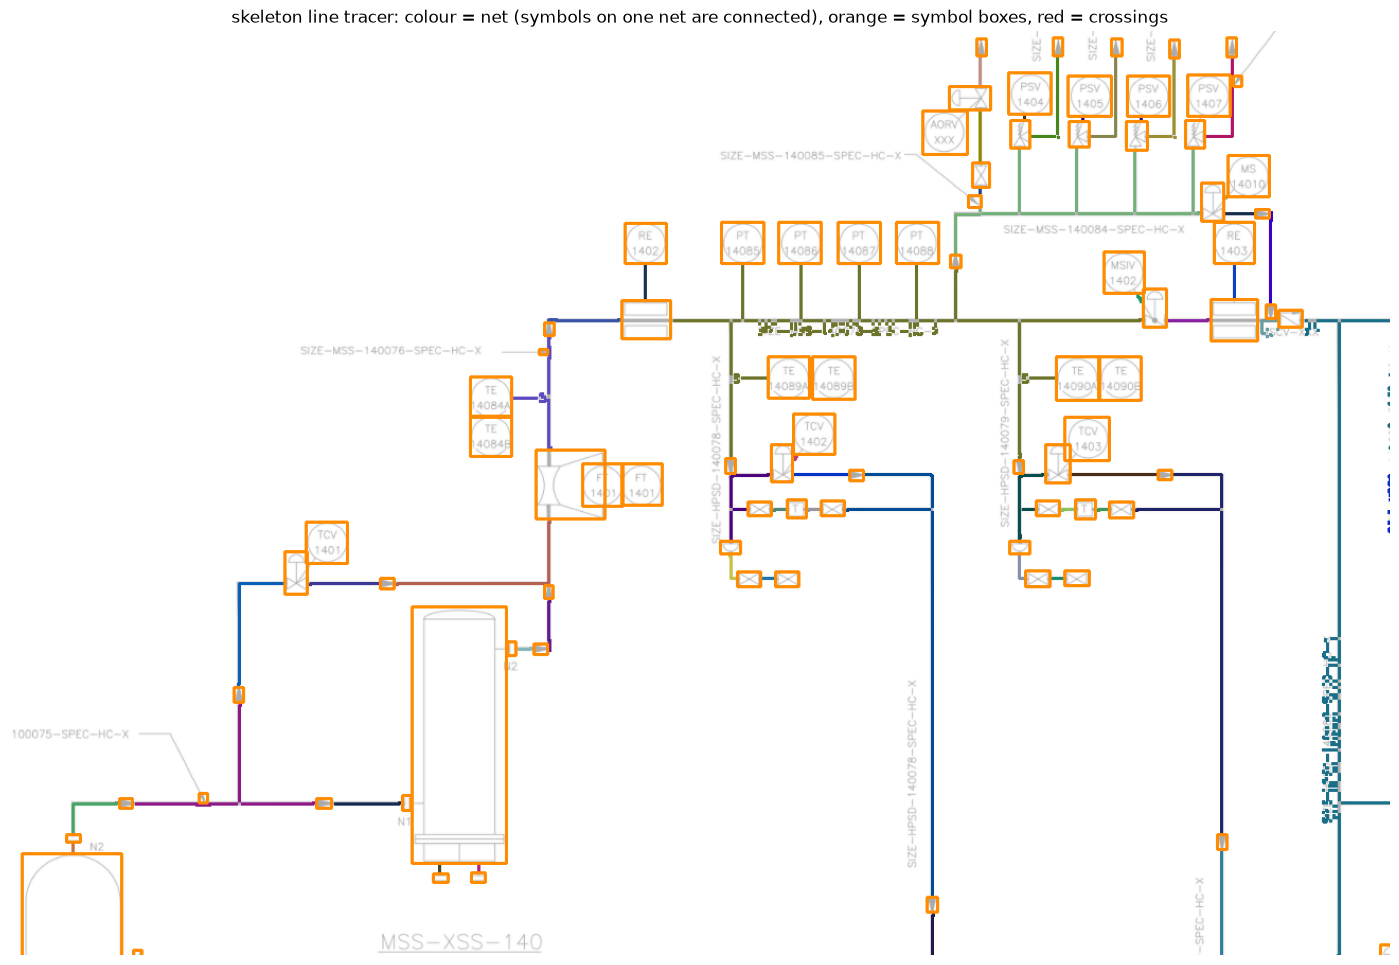

In [12]:
# The tracer on a real OPEN100 plan with its ground-truth symbol boxes: one colour per net, red circles = crossings (not connected)
if USE_PID2GRAPH and TEST_O:
    _img, _gml = p2g_original(TEST_O[0]); _gb, _, _ge, _ = p2g_graph(_gml)
    _g = cv2.imread(str(_img), cv2.IMREAD_GRAYSCALE)
    t0 = time.time(); _tr = trace_lines(_g, _gb, return_maps=True)
    _pe, _gt = trace_pairs(_tr), {(min(a, b), max(a, b)) for a, b in _ge}
    print(f"{TEST_O[0]['name']}: {_tr['stats']} ({time.time() - t0:.1f}s)")
    print(f"traced pairs {len(_pe)}, correct {len(set(_pe) & _gt)} | ground-truth pairs {len(_gt)}, found {len(set(_pe) & _gt)}")
    pal = np.random.RandomState(1).randint(0, 200, (len(_tr["nets"]) + 1, 3)).astype(np.uint8); pal[0] = 255
    netmap = cv2.dilate(_tr["maps"]["net"].astype(np.float32), np.ones((3, 3), np.uint8)).astype(int)
    vis = cv2.cvtColor(_g, cv2.COLOR_GRAY2RGB) // 3 + 170
    vis[netmap > 0] = pal[netmap[netmap > 0]]
    for x1, y1, x2, y2 in _gb.astype(int): cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 140, 0), 2)
    for x, y in _tr["maps"]["crossings"]: cv2.circle(vis, (int(x), int(y)), 7, (230, 0, 0), 2)
    H_, W_ = _g.shape
    plt.figure(figsize=(20, 12)); plt.imshow(vis[int(0.12 * H_):int(0.62 * H_), int(0.08 * W_):int(0.58 * W_)]); plt.axis("off")
    plt.title("skeleton line tracer: colour = net (symbols on one net are connected), orange = symbol boxes, red = crossings"); plt.show()


In [13]:
GT_EDGES = {}   # (source, split, name) -> (E,3) int array [i, j, type] in the sheet's GT symbol order
STYLE_ID = {"solid": 1, "dashed": 2}

def _thumb(path_or_npy):
    a = np.load(path_or_npy, mmap_mode="r") if str(path_or_npy).endswith(".npy") else cv2.imread(str(path_or_npy), cv2.IMREAD_GRAYSCALE)
    return cv2.resize(np.asarray(a), (96, 61), interpolation=cv2.INTER_AREA).astype(np.float32).ravel()

def match_hf_to_p2g():
    """HF sheet -> PID2Graph 'Dataset PID' plan (same 500 drawings, different numbering), by normalised-thumbnail similarity."""
    f = cfg.cache_dir / "hf_to_p2g.json"
    if f.exists(): return json.load(open(f))
    hf = [s for s in INDEX if s["source"] == "digitize"]
    pngs = sorted((P2G_COMPLETE / "Dataset PID").glob("*.png"), key=lambda p: int(p.stem))
    with Pool(16) as pool:
        A = np.stack(pool.map(_thumb, [s["npy"] for s in hf])); B = np.stack(pool.map(_thumb, pngs))
    A -= A.mean(1, keepdims=True); B -= B.mean(1, keepdims=True)
    A /= np.linalg.norm(A, axis=1, keepdims=True); B /= np.linalg.norm(B, axis=1, keepdims=True)
    sim = A @ B.T; j = sim.argmax(1)
    assert len(set(j)) == len(hf) and sim.max(1).min() > 0.99, "HF <-> PID2Graph matching is ambiguous"
    m = {f"{s['split']}/{s['name']}": pngs[k].stem for s, k in zip(hf, j)}
    json.dump(m, open(f, "w")); return m

def _gt_for_hf(args):
    s, stem = args
    boxes, _, edges, _ = p2g_graph(P2G_COMPLETE / "Dataset PID" / f"{stem}.graphml")
    hb = np.array(s["boxes"], np.float32).reshape(-1, 4)
    iou = box_iou(torch.tensor(boxes), torch.tensor(hb)).numpy()
    r, c = linear_sum_assignment(-iou); g2h = {int(a): int(b) for a, b in zip(r, c) if iou[a, b] > 0.5}
    return [[min(g2h[a], g2h[b]), max(g2h[a], g2h[b]), STYLE_ID[st]] for (a, b), st in edges.items() if a in g2h and b in g2h]

if USE_PID2GRAPH:
    gt_file = cfg.cache_dir / "gt_edges_pid2graph.json"
    if not gt_file.exists():
        m = match_hf_to_p2g()
        hf = [s for s in INDEX if s["source"] == "digitize"]
        with Pool(16) as pool: res = pool.map(_gt_for_hf, [(s, m[f"{s['split']}/{s['name']}"]) for s in hf])
        gt = {f"digitize|{s['split']}|{s['name']}": e for s, e in zip(hf, res)}
        for s in INDEX:
            if "p2g" in s:
                gt[f"{s['source']}|{s['split']}|{s['name']}"] = [[a, b, STYLE_ID[st]] for k_, st in s["p2g"]["edges"].items() for a, b in [map(int, k_.split(","))]]
        json.dump(gt, open(gt_file, "w"))
    GT_EDGES = {tuple(k.split("|")): np.array(v, np.int64).reshape(-1, 3) for k, v in json.load(open(gt_file)).items()}
    _all = np.concatenate([v for v in GT_EDGES.values()])
    print(f"PID2Graph ground-truth edges: {len(GT_EDGES)} sheets, {len(_all)} edges ({(_all[:, 2] == 2).mean():.1%} dashed)")

TRACE_DIR = cfg.cache_dir / "edges_trace_v3"; TRACE_DIR.mkdir(parents=True, exist_ok=True)
def _trace_one(s):
    f = TRACE_DIR / f"{s['source']}_{s['split']}_{Path(s['name']).stem}.json"
    if f.exists(): return
    g = cv2.imread(s["img_path"], cv2.IMREAD_GRAYSCALE)
    pairs = trace_pairs(trace_lines(g, np.array(s["boxes"], np.float32).reshape(-1, 4)))
    json.dump({f"{a},{b}": st for (a, b), (sc, st) in pairs.items() if sc >= 0.6}, open(f, "w"))

t0 = time.time()
with Pool(min(16, os.cpu_count())) as pool:
    pool.map(_trace_one, [s for s in INDEX if len(s["boxes"]) >= 2 and (s["source"], s["split"], s["name"]) not in GT_EDGES], chunksize=2)
print(f"line-trace pseudo edge labels ready ({time.time()-t0:.0f}s)")

def edge_label_source(s):
    if (s.get("source"), s["split"], s["name"]) in GT_EDGES: return "pid2graph_gt"
    if (s["split"], s["name"]) in CLAUDE_LABELS: return "claude"
    return "line_trace"

def sheet_edges(s):
    """(E,3) int array of [i, j, type] (i<j, GT symbol indices, type 1=solid 2=dashed) or None if unlabelled."""
    key = (s.get("source"), s["split"], s["name"])
    if key in GT_EDGES: return GT_EDGES[key]
    lab = CLAUDE_LABELS.get((s["split"], s["name"]))
    if lab is not None:
        e = {(min(a, b), max(a, b)): STYLE_ID.get(st, 1) for a, b, st, _ in lab["edges"]}
    else:
        f = TRACE_DIR / f"{s.get('source')}_{s['split']}_{Path(s['name']).stem}.json"
        if not f.exists(): return None
        e = {tuple(map(int, k.split(","))): STYLE_ID[v] for k, v in json.load(open(f)).items()}
    return np.array([[a, b, t] for (a, b), t in sorted(e.items())], np.int64).reshape(-1, 3)

_ne = [sheet_edges(s) for s in TRAIN]
_ne = np.concatenate([e for e in _ne if e is not None])
print(f"train edges: {len(_ne)} ({(_ne[:, 2] == 2).mean():.1%} dashed); label sources:", Counter(edge_label_source(s) for s in TRAIN))

PID2Graph ground-truth edges: 762 sheets, 113933 edges (14.2% dashed)


line-trace pseudo edge labels ready (8s)
train edges: 92719 (14.1% dashed); label sources: Counter({'pid2graph_gt': 600, 'line_trace': 72})


## 4. Patch datasets
* **Train**: random crops with scale jitter (0.8–1.25×), biased towards symbols (80 % of crops centred on a random symbol),
  random 90° rotations and flips, brightness/contrast, blur and noise. Boxes cut by the crop border are kept if
  ≥ `min_visible` of their area is inside (the paper notes truncated symbols as a main error source).
* **Mixed sampling**: `cfg.zenodo_sample_frac` of the crops come from the 72 real sheets (≈30 %), the rest from the 400 synthetic
  ones, which oversamples the real data much as the paper does (3× augmentation of real sheets).
* Each target carries the sheet-level symbol indices, so Claude's sheet-level edges become patch-level edge targets for the relation head.
* **Val**: deterministic grid of patches over the validation sheets (patch-level mAP, as "Patched" in the paper's Table III).

In [14]:
IMG_MEAN, IMG_STD = 0.449 * 255, 0.226 * 255   # ImageNet grey statistics

def boxes_for_crop(boxes, x0, y0, cw, ch, min_visible):
    """boxes: (N,4) xyxy in sheet pixel coords -> clipped local boxes + kept indices."""
    if len(boxes) == 0: return np.zeros((0, 4), np.float32), np.zeros(0, np.int64)
    b = boxes - np.array([x0, y0, x0, y0], np.float32)
    area = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    c = np.stack([b[:, 0].clip(0, cw), b[:, 1].clip(0, ch), b[:, 2].clip(0, cw), b[:, 3].clip(0, ch)], 1)
    vis = (c[:, 2] - c[:, 0]) * (c[:, 3] - c[:, 1]) / np.maximum(area, 1e-6)
    keep = np.where(vis >= min_visible)[0]
    return c[keep], keep

def read_crop(arr, x0, y0, cw, ch):
    """Crop; areas outside the sheet are filled with the sheet's paper colour (small real sheets can be < 1 tile)."""
    H, W = arr.shape
    xa, ya, xb, yb = max(x0, 0), max(y0, 0), min(x0 + cw, W), min(y0 + ch, H)
    crop = np.asarray(arr[ya:yb, xa:xb])
    if crop.shape != (ch, cw):
        crop = cv2.copyMakeBorder(crop, ya - y0, y0 + ch - yb, xa - x0, x0 + cw - xb, cv2.BORDER_CONSTANT,
                                  value=int(np.median(crop)) if crop.size else 255)
    return crop

def rand_origin(L, cs):
    """Random crop origin along one axis; allows negative origins when the sheet is smaller than the crop."""
    return random.randint(0, L - cs) if L >= cs else random.randint(L - cs, 0)

class SheetMixin:
    def __init__(self, sheets):
        self.sheets = sheets
        self.boxes = [np.array(s["boxes"], np.float32).reshape(-1, 4) * cfg.input_scale for s in sheets]
        self.labels = [np.array(s["labels"], np.int64) for s in sheets]
        self.edges = [sheet_edges(s) for s in sheets]
        self._arr = {}
    def arr(self, i):
        if i not in self._arr: self._arr[i] = np.load(self.sheets[i]["npy"], mmap_mode="r")
        return self._arr[i]
    def make_target(self, i, local_boxes, keep, size):
        S = float(size)
        cxcywh = np.stack([(local_boxes[:, 0] + local_boxes[:, 2]) / 2, (local_boxes[:, 1] + local_boxes[:, 3]) / 2,
                           local_boxes[:, 2] - local_boxes[:, 0], local_boxes[:, 3] - local_boxes[:, 1]], 1) / S
        t = {"boxes": torch.from_numpy(cxcywh.astype(np.float32)).reshape(-1, 4), "labels": torch.from_numpy(self.labels[i][keep]),
             "gt_idx": torch.from_numpy(keep), "sheet": i, "has_edges": self.edges[i] is not None}
        e = np.zeros((0, 3), np.int64)
        if self.edges[i] is not None and len(self.edges[i]) and len(keep):
            pos = {g: k for k, g in enumerate(keep.tolist())}
            e = np.array([(pos[a], pos[b], ty) for a, b, ty in self.edges[i] if a in pos and b in pos], np.int64).reshape(-1, 3)
        t["edges"] = torch.from_numpy(e[:, :2].copy()); t["edge_types"] = torch.from_numpy(e[:, 2].copy())
        return t

def to_tensor(gray):
    return torch.from_numpy((gray.astype(np.float32) - IMG_MEAN) / IMG_STD)[None]

class TrainPatches(SheetMixin, Dataset):
    def __init__(self, sheets, length, source_frac=None):
        """source_frac: {source: fraction of crops}, default {'zenodo': cfg.zenodo_sample_frac, rest: 'digitize'}."""
        super().__init__(sheets); self.length = length
        src = np.array([s.get("source", "digitize") for s in sheets])
        frac = dict(source_frac or {"zenodo": cfg.zenodo_sample_frac, "p2g_synth": cfg.p2g_sample_frac,
                                    "digitize": 1 - cfg.zenodo_sample_frac - (cfg.p2g_sample_frac if "p2g_synth" in set(src) else 0)})
        present = {k: v for k, v in frac.items() if (src == k).any()} or {k: 1.0 for k in set(src)}
        self.p = np.array([present.get(s_, 0.0) / (src == s_).sum() for s_ in src])
        if self.p.sum() == 0: self.p = np.ones(len(src))
        self.p /= self.p.sum()
    def __len__(self): return self.length
    def __getitem__(self, _):
        T = cfg.tile
        i = int(np.random.choice(len(self.sheets), p=self.p)); arr = self.arr(i); H, W = arr.shape
        cs = int(T / random.uniform(0.8, 1.25))                      # scale jitter
        if random.random() < 0.8 and len(self.boxes[i]):
            b = self.boxes[i][random.randrange(len(self.boxes[i]))]
            cx, cy = (b[0] + b[2]) / 2 + random.uniform(-0.4, 0.4) * cs, (b[1] + b[3]) / 2 + random.uniform(-0.4, 0.4) * cs
            x0 = int(np.clip(cx - cs / 2, min(0, W - cs), max(0, W - cs)))
            y0 = int(np.clip(cy - cs / 2, min(0, H - cs), max(0, H - cs)))
        else:
            x0, y0 = rand_origin(W, cs), rand_origin(H, cs)
        crop = read_crop(arr, x0, y0, cs, cs)
        lb, keep = boxes_for_crop(self.boxes[i], x0, y0, cs, cs, cfg.min_visible)
        crop = cv2.resize(crop, (T, T), interpolation=cv2.INTER_AREA if cs > T else cv2.INTER_LINEAR)
        lb = lb * (T / cs)
        crop, lb = self.augment(crop, lb, T)
        return to_tensor(crop), self.make_target(i, lb, keep, T)

    @staticmethod
    def augment(img, b, T):
        k = random.randrange(4)                                     # rot90 k times counter-clockwise
        for _ in range(k):
            img = np.ascontiguousarray(np.rot90(img))
            b = np.stack([b[:, 1], T - b[:, 2], b[:, 3], T - b[:, 0]], 1) if len(b) else b
        if random.random() < 0.5:
            img = img[:, ::-1]; b = np.stack([T - b[:, 2], b[:, 1], T - b[:, 0], b[:, 3]], 1) if len(b) else b
        img = img.astype(np.float32)
        img = (img - 128) * random.uniform(0.7, 1.3) + 128 + random.uniform(-40, 40)   # contrast / brightness
        if random.random() < 0.2: img = cv2.GaussianBlur(img, (0, 0), random.uniform(0.3, 1.2))
        if random.random() < 0.2: img = img + np.random.randn(*img.shape).astype(np.float32) * random.uniform(2, 12)
        return np.clip(img, 0, 255).astype(np.uint8), b.astype(np.float32)

def grid_positions(W, H, T, stride):
    xs = list(range(0, max(W - T, 0) + 1, stride)); ys = list(range(0, max(H - T, 0) + 1, stride))
    if xs[-1] + T < W: xs.append(W - T)
    if ys[-1] + T < H: ys.append(H - T)
    return [(x, y) for y in ys for x in xs]

class ValPatches(SheetMixin, Dataset):
    def __init__(self, sheets, stride=cfg.tile):
        super().__init__(sheets)
        self.items = []
        for i, s in enumerate(sheets):
            H, W = np.load(s["npy"], mmap_mode="r").shape
            self.items += [(i, x, y) for x, y in grid_positions(W, H, cfg.tile, stride)]
    def __len__(self): return len(self.items)
    def __getitem__(self, k):
        i, x0, y0 = self.items[k]; T = cfg.tile
        crop = read_crop(self.arr(i), x0, y0, T, T)
        lb, keep = boxes_for_crop(self.boxes[i], x0, y0, T, T, cfg.min_visible)
        return to_tensor(crop), self.make_target(i, lb, keep, T)

def collate(batch):
    return torch.stack([b[0] for b in batch]), [b[1] for b in batch]

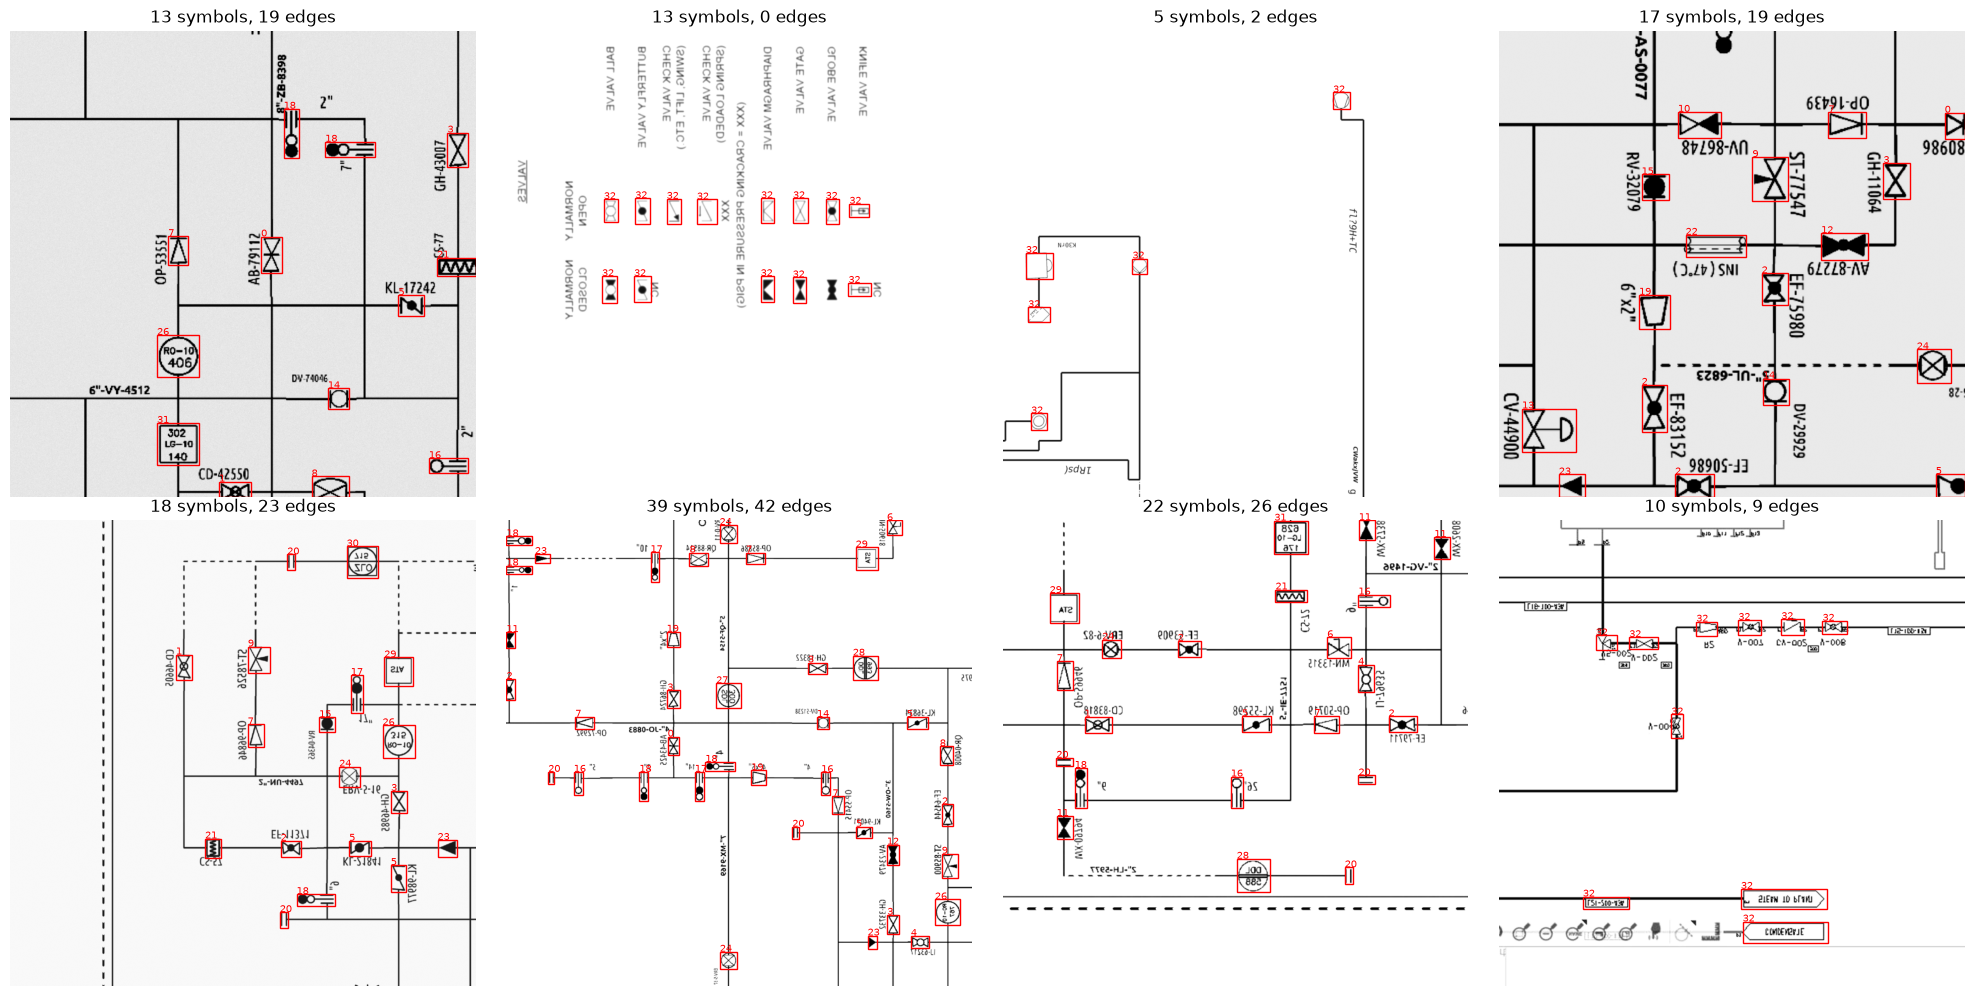

In [15]:
# Visual sanity check of augmented training patches
_ds = TrainPatches(TRAIN, 8)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax in axes.flat:
    img, t = _ds[0]
    ax.imshow(img[0].numpy() * IMG_STD + IMG_MEAN, cmap="gray", vmin=0, vmax=255)
    for (cx, cy, w, h), l in zip(t["boxes"].numpy() * cfg.tile, t["labels"].numpy()):
        ax.add_patch(plt.Rectangle((cx - w/2, cy - h/2), w, h, fill=False, ec="r", lw=1))
        ax.text(cx - w/2, cy - h/2, str(l), color="r", fontsize=7)
    ax.set_title(f"{len(t['labels'])} symbols, {len(t['edges'])} edges"); ax.axis("off")
plt.tight_layout(); plt.show()

## 5. Model: PIDFormer (Relationformer + DINO-style improvements + contrastive head)

```
patch ─► ResNet (frozen BN) ─► C3,C4,C5 ─► 1×1 proj ─► Encoder: "hybrid" (default) = self-attention on C5 + CNN FPN/PAN fusion (RT-DETR)
                                                           │          "deformable"     = 6-layer multi-scale deformable encoder (paper)
                        two-stage proposals ◄──────────────┤ (top-K encoder tokens → anchor boxes, mixed query selection)
                                                           ▼
  [ CDN queries | 300 object queries | [rln] token ] ─► Deformable decoder (6 layers, iterative box refinement, look-forward-twice)
       │                  │                   │
  denoising loss     class / box heads     relation MLP( o_i , o_j , rln ) → edge logit       (Relationformer)
                     projection head → 128-d embedding → SupCon loss                          (contrastive)
```
Multi-scale deformable attention is written in pure PyTorch (`grid_sample`), so no custom CUDA build is needed.

**Relation head with line evidence.** The Relationformer MLP sees the two object queries and the `[rln]` token. Here it also gets
features pooled along the candidate pipe routes between the two symbols (straight segment + both L-shaped orthogonal routes,
sampled from the stride-8 encoder map, skipping the symbols' interiors) and their relative geometry. Without this evidence the
query-only head reached edge mAP 0.12 on the synthetic val sheets; with it, 0.61 (see §8c/§9).

**Why a hybrid encoder by default?** The paper's deformable encoder runs deformable self-attention over all ~21k multi-scale
tokens of a 1024² patch. Its pure-PyTorch backward pass made one training step take ~4 s and used ~24 GB on a 4090. The
RT-DETR-style *efficient hybrid encoder* applies full self-attention only to the 32×32 stride-32 tokens (global context) and fuses
scales with a light CNN top-down/bottom-up path. It is about 10× cheaper with equal or better accuracy (RT-DETR, D-FINE, DEIM).
Set `cfg.encoder = "deformable"` to use the paper's encoder.

In [16]:
REL_CLASSES = ["none", "solid", "dashed"]   # relation classes: no edge + the paper's two line types

def inverse_sigmoid(x, eps=1e-5):
    x = x.clamp(0, 1)
    return torch.log(x.clamp(min=eps) / (1 - x).clamp(min=eps))

def box_cxcywh_to_xyxy(b):
    cx, cy, w, h = b.unbind(-1)
    return torch.stack([cx - w/2, cy - h/2, cx + w/2, cy + h/2], -1)

class MLP(nn.Module):
    def __init__(self, i, h, o, n):
        super().__init__()
        dims = [i] + [h] * (n - 1)
        self.layers = nn.ModuleList(nn.Linear(a, b) for a, b in zip(dims, dims[1:] + [o]))
    def forward(self, x):
        for k, l in enumerate(self.layers):
            x = l(x) if k == len(self.layers) - 1 else F.relu(l(x))
        return x

def ms_deform_attn_core(value, shapes, loc, attn):
    """value (B,S,nH,Dh); loc (B,Lq,nH,nL,nP,2) in [0,1]; attn (B,Lq,nH,nL,nP) -> (B,Lq,nH*Dh)"""
    B, S, nH, Dh = value.shape
    _, Lq, _, nL, nP, _ = loc.shape
    values = value.split([h * w for h, w in shapes], dim=1)
    grids = 2 * loc - 1
    samples = []
    for l, (h, w) in enumerate(shapes):
        v = values[l].flatten(2).transpose(1, 2).reshape(B * nH, Dh, h, w)
        g = grids[:, :, :, l].transpose(1, 2).flatten(0, 1)                   # (B*nH, Lq, nP, 2)
        samples.append(F.grid_sample(v, g.to(v.dtype), mode="bilinear", padding_mode="zeros", align_corners=False))
    a = attn.transpose(1, 2).reshape(B * nH, 1, Lq, nL * nP)
    out = (torch.stack(samples, dim=-2).flatten(-2) * a.to(samples[0].dtype)).sum(-1)   # (B*nH, Dh, Lq)
    return out.view(B, nH * Dh, Lq).transpose(1, 2)

class MSDeformAttn(nn.Module):
    def __init__(self, d, nL, nH, nP):
        super().__init__()
        self.nL, self.nH, self.nP = nL, nH, nP
        self.sampling_offsets = nn.Linear(d, nH * nL * nP * 2)
        self.attention_weights = nn.Linear(d, nH * nL * nP)
        self.value_proj = nn.Linear(d, d); self.output_proj = nn.Linear(d, d)
        nn.init.zeros_(self.sampling_offsets.weight)
        th = torch.arange(nH, dtype=torch.float32) * (2 * math.pi / nH)
        grid = torch.stack([th.cos(), th.sin()], -1)
        grid = (grid / grid.abs().max(-1, keepdim=True)[0]).view(nH, 1, 1, 2).repeat(1, nL, nP, 1)
        for i in range(nP): grid[:, :, i] *= i + 1
        with torch.no_grad(): self.sampling_offsets.bias.copy_(grid.view(-1))
        nn.init.zeros_(self.attention_weights.weight); nn.init.zeros_(self.attention_weights.bias)
        for m in (self.value_proj, self.output_proj): nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, query, ref, value_in, shapes):
        B, Lq, _ = query.shape
        v = self.value_proj(value_in).view(B, value_in.shape[1], self.nH, -1)
        off = self.sampling_offsets(query).view(B, Lq, self.nH, self.nL, self.nP, 2)
        aw = self.attention_weights(query).view(B, Lq, self.nH, self.nL * self.nP).softmax(-1)
        aw = aw.view(B, Lq, self.nH, self.nL, self.nP)
        if ref.shape[-1] == 2:   # encoder: points
            norm = torch.tensor([[w, h] for h, w in shapes], device=query.device, dtype=off.dtype)
            loc = ref[:, :, None, :, None, :] + off / norm[None, None, None, :, None, :]
        else:                    # decoder: boxes (offsets scaled by box size)
            loc = ref[:, :, None, :, None, :2] + off / self.nP * ref[:, :, None, :, None, 2:] * 0.5
        return self.output_proj(ms_deform_attn_core(v, shapes, loc, aw))

class EncoderLayer(nn.Module):
    def __init__(self, d, ffn, nL, nH, nP):
        super().__init__()
        self.attn = MSDeformAttn(d, nL, nH, nP); self.n1 = nn.LayerNorm(d)
        self.ffn = nn.Sequential(nn.Linear(d, ffn), nn.ReLU(inplace=True), nn.Linear(ffn, d)); self.n2 = nn.LayerNorm(d)
    def forward(self, src, pos, ref, shapes):
        src = self.n1(src + self.attn(src + pos, ref, src, shapes))
        return self.n2(src + self.ffn(src))

class ConvBN(nn.Sequential):
    def __init__(self, i, o, k=1, s=1):
        super().__init__(nn.Conv2d(i, o, k, s, k // 2, bias=False), nn.BatchNorm2d(o), nn.SiLU(inplace=True))

class CSPBlock(nn.Module):
    """RepC3-style cross-stage-partial fusion block (RT-DETR CCFM)."""
    def __init__(self, i, o, n=3):
        super().__init__()
        self.c1, self.c2 = ConvBN(i, o), ConvBN(i, o)
        self.m = nn.Sequential(*[ConvBN(o, o, 3) for _ in range(n)])
    def forward(self, x):
        return self.m(self.c1(x)) + self.c2(x)

class AIFILayer(nn.Module):
    """Transformer layer on the stride-32 tokens; positional encoding added to queries/keys only."""
    def __init__(self, d, nH, ffn):
        super().__init__()
        self.sa = nn.MultiheadAttention(d, nH, batch_first=True); self.n1 = nn.LayerNorm(d)
        self.ffn = nn.Sequential(nn.Linear(d, ffn), nn.GELU(), nn.Linear(ffn, d)); self.n2 = nn.LayerNorm(d)
    def forward(self, x, pos):
        q = x + pos
        x = self.n1(x + self.sa(q, q, x, need_weights=False)[0])
        return self.n2(x + self.ffn(x))

class HybridEncoder(nn.Module):
    """RT-DETR efficient hybrid encoder: intra-scale attention (AIFI) on C5 + cross-scale CNN fusion (top-down + bottom-up)."""
    def __init__(self, d, nH, ffn, n_layers, n_levels):
        super().__init__()
        self.aifi = nn.ModuleList(AIFILayer(d, nH, ffn) for _ in range(n_layers))
        self.lateral = nn.ModuleList(ConvBN(d, d) for _ in range(n_levels - 1))
        self.fpn = nn.ModuleList(CSPBlock(2 * d, d) for _ in range(n_levels - 1))
        self.down = nn.ModuleList(ConvBN(d, d, 3, 2) for _ in range(n_levels - 1))
        self.pan = nn.ModuleList(CSPBlock(2 * d, d) for _ in range(n_levels - 1))
    def forward(self, feats, pos_top):
        B, d, h, w = feats[-1].shape
        t = feats[-1].flatten(2).transpose(1, 2)
        for layer in self.aifi: t = layer(t, pos_top)
        feats = list(feats[:-1]) + [t.transpose(1, 2).reshape(B, d, h, w)]
        inner = [feats[-1]]                                       # top-down (FPN)
        for k, lvl in enumerate(range(len(feats) - 1, 0, -1)):
            hi = self.lateral[k](inner[0]); inner[0] = hi
            up = F.interpolate(hi, size=feats[lvl - 1].shape[-2:], mode="nearest")
            inner.insert(0, self.fpn[k](torch.cat([up, feats[lvl - 1]], 1)))
        outs = [inner[0]]                                         # bottom-up (PAN)
        for k in range(len(feats) - 1):
            outs.append(self.pan[k](torch.cat([self.down[k](outs[-1]), inner[k + 1]], 1)))
        return outs

class DecoderLayer(nn.Module):
    def __init__(self, d, ffn, nL, nH, nP):
        super().__init__()
        self.sa = nn.MultiheadAttention(d, nH, batch_first=True); self.n1 = nn.LayerNorm(d)
        self.ca = MSDeformAttn(d, nL, nH, nP); self.n2 = nn.LayerNorm(d)
        self.ffn = nn.Sequential(nn.Linear(d, ffn), nn.ReLU(inplace=True), nn.Linear(ffn, d)); self.n3 = nn.LayerNorm(d)
    def forward(self, tgt, qpos, ref, memory, shapes, attn_mask):
        q = tgt + qpos
        tgt = self.n1(tgt + self.sa(q, q, tgt, attn_mask=attn_mask, need_weights=False)[0])
        tgt = self.n2(tgt + self.ca(tgt + qpos, ref[:, :, None].expand(-1, -1, len(shapes), -1), memory, shapes))
        return self.n3(tgt + self.ffn(tgt))

def sine_embed(pos, num_feats=128, temp=10000):
    """pos (..., k) in [0,1] -> (..., k*num_feats) sine/cosine embedding (DINO style)."""
    dim_t = torch.arange(num_feats, device=pos.device, dtype=torch.float32)
    dim_t = temp ** (2 * (dim_t // 2) / num_feats)
    x = pos[..., None].float() * 2 * math.pi / dim_t
    x = torch.stack([x[..., 0::2].sin(), x[..., 1::2].cos()], -1).flatten(-2)
    return x.flatten(-2)

def freeze_bn(module):
    for name, child in module.named_children():
        if isinstance(child, nn.BatchNorm2d):
            f = FrozenBatchNorm2d(child.num_features, eps=child.eps)
            f.weight.copy_(child.weight.data); f.bias.copy_(child.bias.data)
            f.running_mean.copy_(child.running_mean); f.running_var.copy_(child.running_var)
            setattr(module, name, f)
        else:
            freeze_bn(child)
    return module

class PIDFormer(nn.Module):
    def __init__(self, c: Config, pretrained=True):
        super().__init__()
        self.c = c; d = c.d_model; C = c.num_classes; self.C = C
        self.backbone = freeze_bn(timm.create_model(c.backbone, pretrained=pretrained, features_only=True,
                                                    out_indices=tuple(range(5 - c.n_levels, 5))))
        for n, p in self.backbone.named_parameters():   # freeze stem + first stage (DETR convention)
            if n.startswith(("conv1", "bn1", "layer1", "stem", "stages.0", "stages_0")): p.requires_grad_(False)
        self.input_proj = nn.ModuleList(nn.Sequential(nn.Conv2d(ch, d, 1), nn.GroupNorm(32, d))
                                        for ch in self.backbone.feature_info.channels())
        self.level_embed = nn.Parameter(torch.randn(c.n_levels, d) * 0.02)
        if c.encoder == "hybrid":
            self.encoder = HybridEncoder(d, c.n_heads, c.ffn_dim, c.enc_layers, c.n_levels)
        else:
            self.encoder = nn.ModuleList(EncoderLayer(d, c.ffn_dim, c.n_levels, c.n_heads, c.n_points) for _ in range(c.enc_layers))
        self.decoder = nn.ModuleList(DecoderLayer(d, c.ffn_dim, c.n_levels, c.n_heads, c.n_points) for _ in range(c.dec_layers))
        # two-stage
        self.enc_out = nn.Sequential(nn.Linear(d, d), nn.LayerNorm(d))
        self.enc_cls = nn.Linear(d, C); self.enc_box = MLP(d, d, 4, 3)
        # queries
        self.tgt_embed = nn.Embedding(c.num_queries, d)       # learnable content (mixed query selection)
        self.label_enc = nn.Embedding(C + 1, d)                # CDN label embedding (+1 = padding)
        self.rln_embed = nn.Embedding(1, d)                    # Relationformer [rln] token
        self.ref_point_head = MLP(4 * 128, d, d, 2)
        self.dec_norm = nn.LayerNorm(d)
        # heads (shared across decoder layers)
        self.cls_head = nn.Linear(d, C); self.box_head = MLP(d, d, 4, 3)
        self.proj_head = MLP(d, d, c.emb_dim, 2)               # contrastive embedding
        self.path_mlp = MLP(2 * d, d, d, 2)                    # line evidence pooled along candidate pipe routes
        self.rel_head = MLP(4 * d + 6, 512, len(REL_CLASSES), 3)   # MLP(o_i, o_j, r, path, geometry) -> none / solid / dashed
        prior = -math.log((1 - 0.01) / 0.01)
        for h in (self.cls_head, self.enc_cls): nn.init.constant_(h.bias, prior)
        for h in (self.box_head, self.enc_box):
            nn.init.zeros_(h.layers[-1].weight); nn.init.zeros_(h.layers[-1].bias)
        self._cache = {}

    # ---- helpers ----------------------------------------------------------------
    def _static(self, shapes, device, dtype):
        key = (tuple(shapes), device, dtype)
        if key not in self._cache:
            pos, refs, props = [], [], []
            for l, (h, w) in enumerate(shapes):
                ys, xs = torch.meshgrid(torch.arange(h, device=device), torch.arange(w, device=device), indexing="ij")
                ref = torch.stack([(xs + 0.5) / w, (ys + 0.5) / h], -1).view(-1, 2).float()
                refs.append(ref)
                pos.append(sine_embed(ref, self.c.d_model // 2))
                wh = torch.full_like(ref, 0.03 * 2 ** l)          # anchor size grows with stride
                props.append(torch.cat([ref, wh], -1))
            pos = torch.cat(pos)                                   # (S,d)
            ref = torch.cat(refs)[None, :, None].expand(-1, -1, len(shapes), -1)   # (1,S,nL,2)
            props = torch.cat(props)
            self._cache[key] = (pos, ref, props)
        return self._cache[key]

    def build_cdn(self, targets, device):
        c = self.c
        n_gt = [len(t["labels"]) for t in targets]; M = max(n_gt) if n_gt else 0
        if not self.training or M == 0 or c.dn_number <= 0: return None
        G = max(1, c.dn_number // M); B = len(targets); P = 2 * M * G
        labels = torch.full((B, P), self.C, dtype=torch.long, device=device)
        boxes = torch.full((B, P, 4), 0.5, device=device); boxes[..., 2:] = 0.01
        pos_q, pos_gt, pos_b = [], [], []
        for b, t in enumerate(targets):
            n = n_gt[b]
            if n == 0: continue
            gl, gb = t["labels"].to(device).repeat(G), t["boxes"].to(device).repeat(G, 1)
            j = torch.arange(n, device=device).repeat(G)
            base = torch.arange(G, device=device).repeat_interleave(n) * 2 * M + j
            for neg in (False, True):
                slots = base + (M if neg else 0)
                bb = box_cxcywh_to_xyxy(gb)
                diff = torch.cat([gb[:, 2:] / 2, gb[:, 2:] / 2], -1)
                sign = torch.randint(0, 2, bb.shape, device=device) * 2.0 - 1
                part = torch.rand(bb.shape, device=device) + (1.0 if neg else 0.0)
                bb = (bb + sign * part * diff * c.dn_box_noise).clamp(0, 1)
                nb = torch.stack([(bb[:, 0] + bb[:, 2]) / 2, (bb[:, 1] + bb[:, 3]) / 2,
                                  (bb[:, 2] - bb[:, 0]).clamp(min=1e-3), (bb[:, 3] - bb[:, 1]).clamp(min=1e-3)], -1)
                lab = gl.clone()
                flip = torch.rand(len(lab), device=device) < c.dn_label_noise * 0.5
                lab[flip] = torch.randint(0, self.C, (int(flip.sum()),), device=device)
                labels[b, slots] = lab; boxes[b, slots] = nb
                if not neg:
                    pos_q.append(slots); pos_gt.append(j); pos_b.append(torch.full_like(j, b))
        L = P + c.num_queries + 1
        mask = torch.zeros(L, L, dtype=torch.bool, device=device)
        mask[P:, :P] = True                                      # matching queries / rln cannot see DN queries
        for g in range(G):
            s, e = g * 2 * M, (g + 1) * 2 * M
            mask[s:e, :s] = True; mask[s:e, e:P] = True           # DN groups cannot see each other
        return dict(tgt=self.label_enc(labels), ref=boxes, mask=mask, P=P, G=G, M=M,
                    pos=(torch.cat(pos_b), torch.cat(pos_q), torch.cat(pos_gt)))

    # ---- forward ----------------------------------------------------------------
    def forward(self, images, targets=None):
        c = self.c; B = images.shape[0]
        x = images.expand(-1, 3, -1, -1)
        feats = self.backbone(x)
        projs = [proj(f) for f, proj in zip(feats, self.input_proj)]
        shapes = [tuple(p.shape[-2:]) for p in projs]
        pos, ref_pts, props = self._static(shapes, images.device, torch.float32)
        if c.encoder == "hybrid":
            h5, w5 = shapes[-1]
            projs = self.encoder(projs, pos[-h5 * w5:][None].to(projs[-1].dtype))
        memory = torch.cat([p.flatten(2).transpose(1, 2) + self.level_embed[l] for l, p in enumerate(projs)], 1)
        if c.encoder != "hybrid":
            for layer in self.encoder:
                memory = layer(memory, pos.to(memory.dtype)[None], ref_pts.expand(B, -1, -1, -1), shapes)
        h0, w0 = shapes[0]
        feat8 = memory[:, :h0 * w0].transpose(1, 2).reshape(B, -1, h0, w0)   # stride-8 encoder features for path sampling

        # two-stage proposals + query selection
        om = self.enc_out(memory)
        enc_logits = self.enc_cls(om)
        enc_unsig = self.enc_box(om) + inverse_sigmoid(props)[None]
        topk = enc_logits.max(-1)[0].topk(c.num_queries, dim=1)[1]
        enc_logits_k = torch.gather(enc_logits, 1, topk[..., None].expand(-1, -1, self.C))
        enc_boxes_k = torch.gather(enc_unsig, 1, topk[..., None].expand(-1, -1, 4)).sigmoid()
        ref = enc_boxes_k.detach()
        tgt = self.tgt_embed.weight[None].expand(B, -1, -1)

        dn = self.build_cdn(targets, images.device) if targets is not None else None
        rln_tgt = self.rln_embed.weight[None].expand(B, -1, -1)
        rln_ref = torch.tensor([0.5, 0.5, 1.0, 1.0], device=images.device)[None, None].expand(B, 1, 4)
        P = 0; mask = None
        if dn is not None:
            P = dn["P"]; mask = dn["mask"]
            tgt = torch.cat([dn["tgt"], tgt], 1); ref = torch.cat([dn["ref"], ref], 1)
        tgt = torch.cat([tgt, rln_tgt], 1).to(memory.dtype); ref = torch.cat([ref, rln_ref], 1).float()

        # decoder with iterative refinement + look-forward-twice
        ref_det, ref_undet = ref, ref
        all_logits, all_boxes = [], []
        for layer in self.decoder:
            qpos = self.ref_point_head(sine_embed(ref_det)).to(tgt.dtype)
            tgt = layer(tgt, qpos, ref_det.to(tgt.dtype), memory, shapes, mask)
            h = self.dec_norm(tgt)
            delta = self.box_head(h).float()
            pred = (delta + inverse_sigmoid(ref_undet)).sigmoid()
            new_ref = (delta + inverse_sigmoid(ref_det)).sigmoid()
            ref_undet, ref_det = new_ref, new_ref.detach()
            all_logits.append(self.cls_head(h).float()); all_boxes.append(pred)
        Q = c.num_queries
        sl = slice(P, P + Q)
        out = {"pred_logits": all_logits[-1][:, sl], "pred_boxes": all_boxes[-1][:, sl],
               "hs": h[:, sl], "rln": h[:, P + Q],
               "aux": [{"pred_logits": lg[:, sl], "pred_boxes": bx[:, sl]} for lg, bx in zip(all_logits[:-1], all_boxes[:-1])],
               "enc": {"pred_logits": enc_logits_k.float(), "pred_boxes": enc_boxes_k.float()}}
        out["emb"] = F.normalize(self.proj_head(out["hs"]).float(), dim=-1)
        out["feat8"] = feat8
        if dn is not None:
            out["dn"] = {"logits": [lg[:, :P] for lg in all_logits], "boxes": [bx[:, :P] for bx in all_boxes],
                         "emb": F.normalize(self.proj_head(h[:, :P]).float(), dim=-1), **{k: dn[k] for k in ("pos", "G", "M")}}
        return out

    def path_features(self, feat, bi, bj, K=16):
        """Line evidence between two symbols: encoder features sampled along the straight segment and both L-shaped orthogonal
        routes (P&ID pipes run horizontally/vertically), skipping points inside either symbol; mean+max pooled, max over routes."""
        P, d = len(bi), feat.shape[0]
        ci, cj = bi[:, :2].float(), bj[:, :2].float()
        t = torch.linspace(0, 1, K, device=feat.device)[None, :, None]
        th = torch.linspace(0, 1, K // 2, device=feat.device)[None, :, None]
        def l_route(c): return torch.cat([ci[:, None] + (c - ci)[:, None] * th, c[:, None] + (cj - c)[:, None] * th], 1)
        paths = torch.stack([ci[:, None] + (cj - ci)[:, None] * t,
                             l_route(torch.stack([cj[:, 0], ci[:, 1]], -1)), l_route(torch.stack([ci[:, 0], cj[:, 1]], -1))], 1)   # (P,3,K,2)
        inside = lambda b: ((paths - b[:, None, None, :2].float()).abs() <= b[:, None, None, 2:].float() / 2).all(-1)
        valid = ~(inside(bi) | inside(bj))
        s = F.grid_sample(feat[None].float(), (paths * 2 - 1).view(1, P * 3, K, 2), align_corners=False)[0]   # (d, P*3, K)
        s = s.permute(1, 2, 0).reshape(P, 3, K, d)
        w = valid.float().unsqueeze(-1)
        mean = (s * w).sum(2) / w.sum(2).clamp(min=1)
        mx = s.masked_fill(~valid.unsqueeze(-1), -1e4).max(2).values
        mx = torch.where(valid.any(2, keepdim=True), mx, torch.zeros_like(mx))
        return self.path_mlp(torch.cat([mean, mx], -1)).max(1).values

    @staticmethod
    def pair_geometry(bi, bj):
        d = (bj[:, :2] - bi[:, :2]).abs().float(); ai, aj = (bi[:, 2] * bi[:, 3]).float(), (bj[:, 2] * bj[:, 3]).float()
        return torch.stack([d[:, 0], d[:, 1], d.norm(dim=-1), d.min(-1).values, torch.minimum(ai, aj).sqrt(), torch.maximum(ai, aj).sqrt()], -1)

    def relation_logits(self, hs_i, hs_j, rln, feat, box_i, box_j):
        """Symmetric pairwise edge logits (K, 3) over REL_CLASSES for symbols of ONE patch.
        hs_*: (K,d) decoder states; rln: (d,); feat: (d,H,W) stride-8 features; box_*: (K,4) normalised cxcywh."""
        r = rln.expand_as(hs_i)
        pf = self.path_features(feat, box_i, box_j).to(hs_i.dtype)
        geo = self.pair_geometry(box_i, box_j).to(hs_i.dtype)
        return 0.5 * (self.rel_head(torch.cat([hs_i, hs_j, r, pf, geo], -1)) + self.rel_head(torch.cat([hs_j, hs_i, r, pf, geo], -1))).float()

In [17]:
# Quick shape / speed test
_m = PIDFormer(cfg).to(device)
print(f"params: {sum(p.numel() for p in _m.parameters())/1e6:.1f}M (trainable {sum(p.numel() for p in _m.parameters() if p.requires_grad)/1e6:.1f}M)")
with torch.no_grad(), torch.autocast("cuda", dtype=torch.bfloat16):
    _o = _m.eval()(torch.randn(2, 1, cfg.tile, cfg.tile, device=device))
print({k: tuple(v.shape) for k, v in _o.items() if torch.is_tensor(v)})
del _m, _o; torch.cuda.empty_cache()

params: 42.3M (trainable 42.1M)


{'pred_logits': (2, 300, 32), 'pred_boxes': (2, 300, 4), 'hs': (2, 300, 256), 'rln': (2, 256), 'emb': (2, 300, 128), 'feat8': (2, 256, 128, 128)}


## 6. Matching and losses
* **Hungarian matcher**: cost = 2·focal-class + 5·L1 + 2·(−GIoU).
* **Varifocal loss** (IoU-aware): the positive target for the matched class is the IoU between prediction and GT.
* **L1 + GIoU** box losses on every decoder layer (deep supervision), on encoder proposals, and on CDN groups.
* **SupCon** on L2-normalised projections of matched queries and positive denoising queries, with a cross-batch memory
  queue (XBM) so rare classes still have positives in every step.
* **Partial labels (real-world Zenodo boxes, label 32 = `symbol_unspecified`)**: the matcher's class cost uses the *max* class
  probability, and the varifocal loss only supervises the confidence of the predicted class (target = IoU). The other 31 class logits
  of that query get zero weight. The real boxes thus teach localisation and objectness on real drawings without forcing a class.
  They are excluded from SupCon.
* **Relation loss** (Relationformer): 3-way cross-entropy (none / solid / dashed) on pairs of matched queries. Positives are labelled
  connections with their line type (§3b), and negatives are sampled unconnected pairs (3:1). Dashed edges get weight 2 (they are rarer).
  Only patches whose sheet has edge labels contribute.

In [18]:
class HungarianMatcher(nn.Module):
    def __init__(self, w_cls=2.0, w_l1=5.0, w_giou=2.0, alpha=0.25, gamma=2.0):
        super().__init__(); self.w = (w_cls, w_l1, w_giou); self.alpha, self.gamma = alpha, gamma
    @torch.no_grad()
    def forward(self, logits, boxes, targets):
        B, Q, _ = logits.shape
        sizes = [len(t["labels"]) for t in targets]
        if sum(sizes) == 0:
            return [(torch.zeros(0, dtype=torch.long), torch.zeros(0, dtype=torch.long)) for _ in targets]
        p = logits.flatten(0, 1).sigmoid(); ob = boxes.flatten(0, 1)
        tl = torch.cat([t["labels"] for t in targets]).to(p.device); tb = torch.cat([t["boxes"] for t in targets]).to(p.device)
        def focal_cost(q):
            return self.alpha * (1 - q).pow(self.gamma) * -(q + 1e-8).log() - (1 - self.alpha) * q.pow(self.gamma) * -(1 - q + 1e-8).log()
        unk = tl >= p.shape[1]                                   # partial label: any class is acceptable
        cls_cost = focal_cost(p)[:, tl.clamp(max=p.shape[1] - 1)]
        if unk.any(): cls_cost[:, unk] = focal_cost(p.max(1)[0])[:, None]
        cost = self.w[0] * cls_cost + self.w[1] * torch.cdist(ob, tb, p=1) \
             - self.w[2] * generalized_box_iou(box_cxcywh_to_xyxy(ob), box_cxcywh_to_xyxy(tb))
        cost = cost.view(B, Q, -1).cpu()
        out = []
        for b, cb in enumerate(cost.split(sizes, -1)):
            i, j = linear_sum_assignment(cb[b].numpy())
            out.append((torch.as_tensor(i, dtype=torch.long), torch.as_tensor(j, dtype=torch.long)))
        return out

def varifocal_loss(logits, idx, tgt_labels, ious, num_boxes, alpha=0.75, gamma=2.0):
    """idx = (batch_idx, query_idx) of positives. Labels >= num_classes are partial labels (class unknown)."""
    C = logits.shape[-1]
    unk = tgt_labels >= C
    lab = torch.where(unk, logits[idx[0], idx[1]].detach().argmax(-1), tgt_labels)
    target = torch.zeros_like(logits)
    target[idx[0], idx[1], lab] = ious.to(logits.dtype)
    onehot = torch.zeros_like(logits); onehot[idx[0], idx[1], lab] = 1
    p = logits.sigmoid().detach()
    weight = alpha * p.pow(gamma) * (1 - onehot) + target
    if unk.any():   # only the chosen class of an unknown-class object is supervised
        weight[idx[0][unk], idx[1][unk]] = target[idx[0][unk], idx[1][unk]]
    loss = F.binary_cross_entropy_with_logits(logits, target, weight=weight, reduction="none")
    return loss.mean(1).sum() * logits.shape[1] / num_boxes

class SupConMemory:
    """Supervised contrastive loss with a FIFO memory of past embeddings (cross-batch memory)."""
    def __init__(self, size, dim, temp):
        self.size, self.temp = size, temp
        self.feats = torch.zeros(0, dim); self.labels = torch.zeros(0, dtype=torch.long)
    def loss(self, z, y):
        if len(z) < 2: return z.sum() * 0
        mf, ml = self.feats.to(z.device), self.labels.to(z.device)
        keys = torch.cat([z, mf]); kl = torch.cat([y, ml])
        sim = z @ keys.T / self.temp
        self_mask = torch.zeros_like(sim, dtype=torch.bool); self_mask[:, :len(z)].fill_diagonal_(True)
        sim = sim.masked_fill(self_mask, -1e9)
        pos = (y[:, None] == kl[None]) & ~self_mask
        log_prob = sim - torch.logsumexp(sim, 1, keepdim=True)
        has = pos.any(1)
        l = -(log_prob * pos).sum(1)[has] / pos.sum(1)[has]
        # enqueue
        self.feats = torch.cat([z.detach().cpu(), self.feats])[:self.size]
        self.labels = torch.cat([y.detach().cpu(), self.labels])[:self.size]
        return l.mean() if has.any() else z.sum() * 0

class Criterion:
    def __init__(self, c: Config, model: PIDFormer):
        self.c, self.model = c, model
        self.matcher = HungarianMatcher()
        self.supcon = SupConMemory(c.supcon_queue, c.emb_dim, c.supcon_temp)

    def det_losses(self, logits, boxes, targets, indices, num_boxes):
        bi = torch.cat([torch.full_like(s, b) for b, (s, _) in enumerate(indices)]).to(logits.device)
        si = torch.cat([s for s, _ in indices]).to(logits.device)
        tl = torch.cat([t["labels"][j] for t, (_, j) in zip(targets, indices)]).to(logits.device)
        tb = torch.cat([t["boxes"][j] for t, (_, j) in zip(targets, indices)]).to(logits.device)
        sb = boxes[bi, si]
        if len(tb):
            giou = generalized_box_iou(box_cxcywh_to_xyxy(sb), box_cxcywh_to_xyxy(tb)).diag()
            ious = box_iou(box_cxcywh_to_xyxy(sb), box_cxcywh_to_xyxy(tb)).diag().detach().clamp(0.01)
            l1 = F.l1_loss(sb, tb, reduction="sum") / num_boxes
            lg = (1 - giou).sum() / num_boxes
        else:
            ious = sb.new_zeros(0); l1 = lg = boxes.sum() * 0
        lc = varifocal_loss(logits, (bi, si), tl, ious, num_boxes)
        return self.c.w_cls * lc + self.c.w_l1 * l1 + self.c.w_giou * lg, (lc.detach(), l1.detach(), lg.detach())

    def __call__(self, out, targets):
        c = self.c; dev = out["pred_logits"].device
        num_boxes = max(sum(len(t["labels"]) for t in targets), 1)
        logs = {}
        indices = self.matcher(out["pred_logits"], out["pred_boxes"], targets)
        total, (lc, l1, lg) = self.det_losses(out["pred_logits"], out["pred_boxes"], targets, indices, num_boxes)
        logs.update(cls=lc, l1=l1, giou=lg)
        for aux in out["aux"] + [out["enc"]]:
            ind = self.matcher(aux["pred_logits"], aux["pred_boxes"], targets)
            total = total + self.det_losses(aux["pred_logits"], aux["pred_boxes"], targets, ind, num_boxes)[0]

        # contrastive denoising
        z_list, y_list = [], []
        if "dn" in out:
            dn = out["dn"]; pb, pq, pg = dn["pos"]
            ind = [(pq[pb == b].cpu(), pg[pb == b].cpu()) for b in range(len(targets))]
            dn_total = 0
            for lg_, bx_ in zip(dn["logits"], dn["boxes"]):
                dn_total = dn_total + self.det_losses(lg_, bx_, targets, ind, num_boxes * dn["G"])[0]
            total = total + dn_total
            logs["dn"] = dn_total.detach()
            z_list.append(dn["emb"][pb, pq]); y_list.append(torch.cat([t["labels"][g] for t, (_, g) in zip(targets, ind)]).to(dev))

        # supervised contrastive on matched object queries
        bi = torch.cat([torch.full_like(s, b) for b, (s, _) in enumerate(indices)]).to(dev)
        si = torch.cat([s for s, _ in indices]).to(dev)
        z_list.append(out["emb"][bi, si]); y_list.append(torch.cat([t["labels"][j] for t, (_, j) in zip(targets, indices)]).to(dev))
        if c.w_supcon > 0:
            z, y = torch.cat(z_list), torch.cat(y_list)
            known = y < self.model.C
            ls = self.supcon.loss(z[known], y[known])
            total = total + c.w_supcon * ls; logs["supcon"] = ls.detach()

        # relation head
        if c.w_rel > 0:
            hi, hj, rl, yy = [], [], [], []
            for b, (t, (s, g)) in enumerate(zip(targets, indices)):
                n = len(g)
                if not t["has_edges"] or n < 2: continue
                q_of_gt = torch.empty(n, dtype=torch.long); q_of_gt[g] = s
                pos = {tuple(e): int(ty) for e, ty in zip(t["edges"].tolist(), t["edge_types"].tolist())}
                neg = [(i, j) for i in range(n) for j in range(i + 1, n) if (i, j) not in pos]
                random.shuffle(neg)
                neg = neg[:max(3 * len(pos), 8)] if c.rel_neg_ratio == 3 else neg[:max(int(c.rel_neg_ratio * len(pos)), 64) if c.rel_neg_ratio else 2000]
                pairs = list(pos) + neg
                if not pairs: continue
                pi = torch.tensor(pairs, dtype=torch.long)
                qi, qj = q_of_gt[pi[:, 0]].to(dev), q_of_gt[pi[:, 1]].to(dev)
                bx = out["pred_boxes"][b].detach()
                hi.append(self.model.relation_logits(out["hs"][b, qi], out["hs"][b, qj], out["rln"][b], out["feat8"][b], bx[qi], bx[qj]))
                yy.append(torch.tensor(list(pos.values()) + [0] * len(neg), device=dev, dtype=torch.long))
            if hi:
                lr = F.cross_entropy(torch.cat(hi), torch.cat(yy), weight=torch.tensor([1.0, 1.0, 2.0], device=dev))
                total = total + c.w_rel * lr; logs["rel"] = lr.detach()
        logs["total"] = total.detach()
        return total, logs

## 7. Training
AdamW (backbone lr 1e-5, rest 1e-4), linear warm-up + cosine decay, bf16 autocast, gradient clipping 0.1, EMA weights.
Patch-level validation runs every `eval_every` epochs on a grid of val patches. It reports mAP@0.5 and mAP@0.5:0.95 on synthetic
sheets (32 classes) and **class-agnostic AP@0.5 on the real Zenodo sheets** (`val_zen_AP50`). The best EMA checkpoint, by the mean of
synthetic mAP@0.5 and real AP@0.5, is saved to `runs/pidformer/best.pt`. Training resumes from `last.pt` if present. The data mix can
change between runs (e.g. Zenodo added mid-training), because the architecture and output classes stay the same.

On an RTX 4090 the default schedule (40 epochs × 500 iterations × 8 patches of 1024²) takes a few hours. By default
training is skipped when `best.pt` exists and there is no `last.pt` to resume (see §0).

In [19]:
from torchmetrics.detection import MeanAveragePrecision

class EMA:
    def __init__(self, model, decay, warmup=2000):
        self.ema = copy.deepcopy(model).eval(); self.decay, self.warmup, self.step = decay, warmup, 0
        for p in self.ema.parameters(): p.requires_grad_(False)
    @torch.no_grad()
    def update(self, model):
        self.step += 1
        d = self.decay * (1 - math.exp(-self.step / self.warmup))
        msd = model.state_dict()
        for k, v in self.ema.state_dict().items():
            if v.dtype.is_floating_point: v.lerp_(msd[k].detach(), 1 - d)
            else: v.copy_(msd[k])

def postprocess(out, size, score_thr=0.0):
    """One detection per query (argmax class). Returns list of dicts with pixel xyxy boxes."""
    prob = out["pred_logits"].sigmoid()
    scores, labels = prob.max(-1)
    boxes = box_cxcywh_to_xyxy(out["pred_boxes"]) * size
    res = []
    for b in range(len(prob)):
        k = scores[b] > score_thr
        res.append({"boxes": boxes[b][k].float(), "scores": scores[b][k].float(), "labels": labels[b][k],
                    "query": torch.nonzero(k).squeeze(1)})
    return res

@torch.no_grad()
def evaluate_patches(model, loader, max_batches=None, super_classes=False, agnostic=False):
    model.eval()
    metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")
    metric.warn_on_many_detections = False
    sup = torch.tensor(SUPER_CLASS, device=device)
    for k, (imgs, targets) in enumerate(loader):
        if max_batches and k >= max_batches: break
        with torch.autocast("cuda", dtype=torch.bfloat16):
            out = model(imgs.to(device, non_blocking=True))
        preds = postprocess(out, cfg.tile, score_thr=0.01)
        gts = [{"boxes": box_cxcywh_to_xyxy(t["boxes"]).to(device) * cfg.tile, "labels": t["labels"].to(device)} for t in targets]
        if super_classes:
            for d in preds + gts: d["labels"] = sup[d["labels"]]
        if agnostic:
            for d in preds + gts: d["labels"] = torch.zeros_like(d["labels"])
        metric.update([{k2: v for k2, v in p.items() if k2 != "query"} for p in preds], gts)
    r = metric.compute()
    return {"mAP50": r["map_50"].item(), "mAP": r["map"].item()}

def build_optimizer(model):
    bb = [p for n, p in model.named_parameters() if p.requires_grad and n.startswith("backbone.")]
    rest = [p for n, p in model.named_parameters() if p.requires_grad and not n.startswith("backbone.")]
    return torch.optim.AdamW([{"params": bb, "lr": cfg.lr_backbone}, {"params": rest, "lr": cfg.lr}],
                             lr=cfg.lr, weight_decay=cfg.weight_decay)

def lr_lambda(it, total):
    if it < cfg.warmup_iters: return (it + 1) / cfg.warmup_iters
    t = (it - cfg.warmup_iters) / max(1, total - cfg.warmup_iters)
    return 0.05 + 0.95 * 0.5 * (1 + math.cos(math.pi * t))

def seed_worker(_):
    np.random.seed(torch.initial_seed() % 2**32)   # torch already seeds python `random` per worker

def train(resume=True):
    model = PIDFormer(cfg).to(device)
    crit = Criterion(cfg, model)
    opt = build_optimizer(model)
    total_iters = cfg.epochs * cfg.iters_per_epoch
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda it: lr_lambda(it, total_iters))
    ema = EMA(model, cfg.ema_decay)
    start_ep, best, history = 0, -1.0, []
    last = cfg.run_dir / "last.pt"
    if resume and last.exists():
        ck = torch.load(last, map_location=device, weights_only=False)
        start_ep, history = ck["epoch"] + 1, ck["history"]
        if start_ep >= cfg.epochs:                       # schedule already finished: nothing to resume
            print("training already complete (last.pt epoch", ck["epoch"], ")"); return None, history   # later sections load best.pt
        model.load_state_dict(ck["model"]); ema.ema.load_state_dict(ck["ema"]); opt.load_state_dict(ck["opt"])
        sched.load_state_dict(ck["sched"]); ema.step = ck["ema_step"]
        best = ck["best"] if ck.get("best_metric") == "mean(synthetic mAP50, real AP50)" else -1.0
        print(f"resumed from epoch {start_ep}")
    train_dl = DataLoader(TrainPatches(TRAIN, cfg.iters_per_epoch * cfg.batch_size), batch_size=cfg.batch_size,
                          num_workers=cfg.num_workers, collate_fn=collate, pin_memory=True, drop_last=True,
                          persistent_workers=cfg.num_workers > 0, worker_init_fn=seed_worker)
    val_dl = DataLoader(ValPatches(VAL_D[:cfg.eval_val_sheets]), batch_size=cfg.batch_size, num_workers=cfg.num_workers,
                        collate_fn=collate, pin_memory=True)
    val_zen = DataLoader(ValPatches(VAL_Z), batch_size=cfg.batch_size, num_workers=cfg.num_workers, collate_fn=collate) if VAL_Z else None
    print(f"train iters/epoch {len(train_dl)}, val patches synthetic {len(val_dl.dataset)} / real {len(val_zen.dataset) if val_zen else 0}")
    for ep in range(start_ep, cfg.epochs):
        model.train(); t0 = time.time(); run, cnt = defaultdict(float), Counter(); n = 0
        for imgs, targets in train_dl:
            imgs = imgs.to(device, non_blocking=True)
            with torch.autocast("cuda", dtype=torch.bfloat16):
                out = model(imgs, targets)
            loss, logs = crit(out, targets)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.clip_grad)
            opt.step(); sched.step(); ema.update(model)
            for k, v in logs.items(): run[k] += float(v); cnt[k] += 1
            n += 1
            if n % 100 == 0:
                print(f"  ep {ep} it {n}: " + " ".join(f"{k}={v/cnt[k]:.3f}" for k, v in run.items()), flush=True)
        rec = {"epoch": ep, **{k: v / cnt[k] for k, v in run.items()}, "time": time.time() - t0}
        if (ep + 1) % cfg.eval_every == 0 or ep == cfg.epochs - 1:
            rec.update({f"val_{k}": v for k, v in evaluate_patches(ema.ema, val_dl).items()})
            if val_zen is not None:
                rec["val_zen_AP50"] = evaluate_patches(ema.ema, val_zen, agnostic=True)["mAP50"]
            score = (rec["val_mAP50"] + rec.get("val_zen_AP50", rec["val_mAP50"])) / 2
            if score > best:
                best = score
                torch.save({"model": ema.ema.state_dict(), "cfg": asdict(cfg), "class_names": CLASS_NAMES,
                            "relation_trained": bool(CLAUDE_LABELS) and cfg.w_rel > 0},
                           cfg.run_dir / "best.pt")
        history.append(rec)
        with open(cfg.run_dir / "log.jsonl", "a") as f: f.write(json.dumps(rec) + "\n")
        print(" | ".join(f"{k}={v:.4f}" if isinstance(v, float) else f"{k}={v}" for k, v in rec.items()), flush=True)
        torch.save({"model": model.state_dict(), "ema": ema.ema.state_dict(), "opt": opt.state_dict(), "sched": sched.state_dict(),
                    "ema_step": ema.step, "epoch": ep, "best": best, "best_metric": "mean(synthetic mAP50, real AP50)",
                    "history": history}, last)
    return ema.ema, history

# Skip training when a trained model exists and there is nothing to resume (e.g. a fresh clone with the LFS checkpoint).
RUN_TRAINING = not (cfg.run_dir / "best.pt").exists() or (cfg.run_dir / "last.pt").exists()
if RUN_TRAINING:
    model, HISTORY = train()
    json.dump(HISTORY, open(cfg.run_dir / "history.json", "w"), indent=1)

training already complete (last.pt epoch 39 )


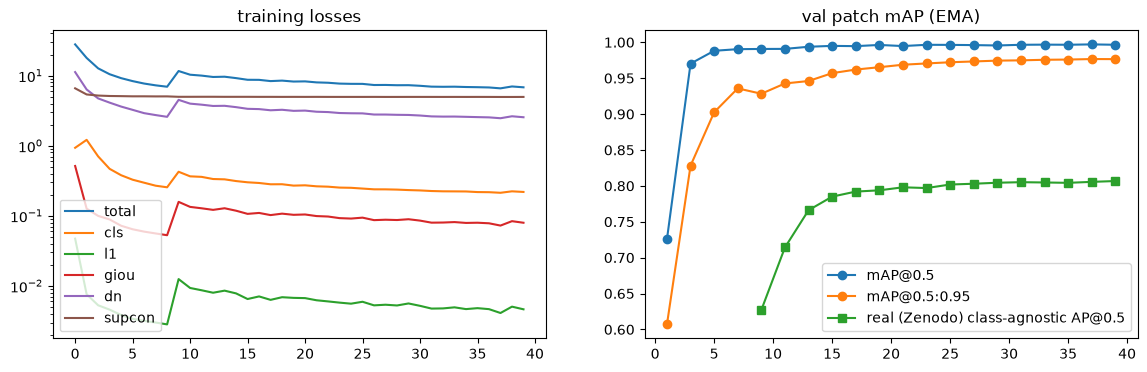

In [20]:
HISTORY = json.load(open(cfg.run_dir / "history.json"))
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for k in ("total", "cls", "l1", "giou", "dn", "supcon", "rel"):
    pts = [(h["epoch"], h[k]) for h in HISTORY if k in h]
    if pts: ax[0].plot(*zip(*pts), label=k)
ax[0].set_yscale("log"); ax[0].legend(); ax[0].set_title("training losses")
ev = [h for h in HISTORY if "val_mAP50" in h]
ax[1].plot([h["epoch"] for h in ev], [h["val_mAP50"] for h in ev], "o-", label="mAP@0.5")
ax[1].plot([h["epoch"] for h in ev], [h["val_mAP"] for h in ev], "o-", label="mAP@0.5:0.95")
zv = [h for h in ev if "val_zen_AP50" in h]
if zv: ax[1].plot([h["epoch"] for h in zv], [h["val_zen_AP50"] for h in zv], "s-", label="real (Zenodo) class-agnostic AP@0.5")
ax[1].legend(); ax[1].set_title("val patch mAP (EMA)"); plt.show()

## 8. Full-sheet inference: tiling → merge → graph → tags → JSON

1. Resize the sheet by `input_scale` (× an optional `pre_scale`) and cut 1024² tiles with 50 % overlap. With `auto_scale=True`,
   a first pass measures the median detected symbol size, and the sheet is re-run at the scale the model was trained on (~72 px
   symbols). This matters for arbitrary real drawings, the same way the Zenodo sheets were normalised.
2. Run PIDFormer on every tile (batched). Symbols that are small in model pixels (< 60 px, e.g. flow arrows on real plans) get a
   second pass at 2× scale (`zoom_small_symbols`, §9d). Each kept query gives a box, class probabilities, an embedding and its decoder state.
3. **Paper merge procedure**: lower each confidence by its distance to an *interior* tile border,
   ĉ = c − α·exp(−3·2d/S) with α = 0.4, so symbols cut by a tile edge lose to their complete copy in a neighbouring tile;
   filter; class-agnostic **Weighted Box Fusion** (fused class = score-weighted mean of class probabilities); a final NMS.
4. **Connections**, from up to three sources merged in the JSON (`methods` field):
   * `relation_head`: Relationformer pairwise edge probabilities per tile, mapped to fused nodes (max over tiles). Used only when
     the checkpoint's relation head was trained on edge labels (§3b, §8c). Untrained, it outputs ~0.5 everywhere.
   * `line_trace`: the skeleton line tracer of §3b, the main source. Symbols and text are erased and the line skeleton is cut into
     segments. Junctions are classified from their branch directions (a straight 4-way crossing does not connect), and dash or crossing gaps
     are bridged. Symbols on the same net are connected; a net with ≥ 3 symbols becomes a **junction node** (the paper's crossing/ankle
     nodes). Touching symbol boxes are connected as `adjacency`.
   * `claude`: set-of-marks reading by Claude Sonnet 5.5.

   Line type: Claude > line tracer > relation head. Each connection gets a fused `score` (`fuse_edge_score`, §9c):
   `trace_score × (0.6 + 0.4·p_relation)` for traced edges, `0.3·p_relation` for relation-head-only edges, ≥ 0.9 when Claude confirms,
   all × √(lower detection confidence of the two symbols).
5. **Tags**: text *inside* instrument bubbles/boxes is read from an upscaled interior crop (`GLR` / `193` → `GLR-193`). For other
   symbols, sheet-level EasyOCR (0°/90°/270°) finds tag-like labels (`WX-71994`), which are assigned with Hungarian matching on box-gap distance. Optionally **Claude Sonnet 5.5** re-reads tags and connections on a set-of-marks
   overlay of the *detected* boxes, and its answers take priority for tags and are unioned with relation-head edges.
6. Write a JSON file and an overlay PNG to `outputs/`.

In [21]:
def load_model(path=None):
    path = path or cfg.run_dir / "best.pt"
    ck = torch.load(path, map_location=device, weights_only=False)
    m = PIDFormer(cfg, pretrained=False).to(device)
    own = m.state_dict()
    sd = {k: v for k, v in ck["model"].items() if k in own and own[k].shape == v.shape}   # tolerate heads that changed shape
    skipped = sorted(set(ck["model"]) - set(sd))
    if skipped: print("load_model: re-initialised", skipped)
    m.load_state_dict(sd, strict=False)
    m.relation_trained = bool(ck.get("relation_trained", False)) and not any(k.startswith("rel_head") for k in skipped)
    return m.eval()

@torch.no_grad()
def detect_sheet(model, gray_native, score_thr=0.05, batch=8, alpha=0.4, pre_scale=1.0):
    s = cfg.input_scale * pre_scale; T = cfg.tile
    img = cv2.resize(gray_native, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
    H, W = img.shape
    pos = grid_positions(W, H, T, cfg.infer_stride)
    R = defaultdict(list); rln = []; feats = []
    for k in range(0, len(pos), batch):
        chunk = pos[k:k + batch]
        x = torch.stack([to_tensor(read_crop(img, x0, y0, T, T)) for x0, y0 in chunk]).to(device)
        with torch.autocast("cuda", dtype=torch.bfloat16):
            out = model(x)
        prob = out["pred_logits"].sigmoid().float()
        boxes = box_cxcywh_to_xyxy(out["pred_boxes"]).clamp(0, 1) * T
        for b, (x0, y0) in enumerate(chunk):
            sc, lb = prob[b].max(-1)
            keep = sc > score_thr
            bx = boxes[b][keep]
            # distance to interior tile borders only (a tile edge lying on the sheet edge cuts nothing)
            big = torch.full_like(bx[:, 0], 1e9)
            d = torch.stack([bx[:, 0] if x0 > 0 else big, bx[:, 1] if y0 > 0 else big,
                             T - bx[:, 2] if x0 + T < W else big, T - bx[:, 3] if y0 + T < H else big], 1).min(1)[0].clamp(min=0)
            R["score"].append(sc[keep] - alpha * torch.exp(-3 * 2 * d / T))
            R["raw_score"].append(sc[keep]); R["label"].append(lb[keep]); R["prob"].append(prob[b][keep])
            R["box"].append((bx + torch.tensor([x0, y0, x0, y0], device=device)) / s)
            R["hs"].append(out["hs"][b][keep].float()); R["emb"].append(out["emb"][b][keep])
            R["qbox"].append(out["pred_boxes"][b][keep].float()); feats.append(out["feat8"][b])
            R["tile"].append(torch.full((int(keep.sum()),), k + b, device=device))
            rln.append(out["rln"][b].float())
    dets = {k: torch.cat(v) for k, v in R.items()}
    dets["rln"] = torch.stack(rln); dets["feat8"] = feats
    dets["tiles"] = torch.tensor([[x0, y0, x0 + T, y0 + T] for x0, y0 in pos], dtype=torch.float32, device=device) / s
    return dets

def merge_tile_detections(dets, min_score=0.05, iou_wbf=0.55, iou_nms=0.5):
    """Paper merge: decayed-score filter -> class-agnostic WBF -> NMS. Returns fused nodes and member->node map."""
    sc = dets["score"]; valid = torch.nonzero(sc >= min_score).squeeze(1)
    order = valid[sc[valid].argsort(descending=True)].tolist()
    boxes, scores, probs = dets["box"].cpu().numpy(), sc.cpu().numpy(), dets["prob"].cpu().numpy()
    fused, members = [], []
    member_of = np.full(len(sc), -1)
    for i in order:
        b = boxes[i]
        if fused:
            F_ = np.array(fused)
            ix1 = np.maximum(F_[:, 0], b[0]); iy1 = np.maximum(F_[:, 1], b[1]); ix2 = np.minimum(F_[:, 2], b[2]); iy2 = np.minimum(F_[:, 3], b[3])
            inter = np.clip(ix2 - ix1, 0, None) * np.clip(iy2 - iy1, 0, None)
            iou = inter / ((F_[:, 2] - F_[:, 0]) * (F_[:, 3] - F_[:, 1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter + 1e-6)
            j = int(iou.argmax())
            if iou[j] >= iou_wbf:
                members[j].append(i); member_of[i] = j
                w = scores[members[j]]
                fused[j] = (boxes[members[j]] * w[:, None]).sum(0) / w.sum()
                continue
        fused.append(b.copy()); members.append([i]); member_of[i] = len(fused) - 1
    if not fused:
        return {"boxes": np.zeros((0, 4)), "scores": np.zeros(0), "labels": np.zeros(0, int), "probs": np.zeros((0, cfg.num_classes)),
                "emb": np.zeros((0, cfg.emb_dim))}, member_of
    tiles = dets["tiles"].cpu().numpy(); F_ = np.array(fused)
    cover = ((tiles[None, :, 0] <= F_[:, None, 0]) & (tiles[None, :, 1] <= F_[:, None, 1]) &
             (tiles[None, :, 2] >= F_[:, None, 2]) & (tiles[None, :, 3] >= F_[:, None, 3])).sum(1)
    emb = dets["emb"].float().cpu().numpy()
    f_scores, f_probs, f_emb = [], [], []
    for j, m in enumerate(members):
        w = scores[m]
        f_scores.append(w.sum() / max(cover[j], len(m)))
        f_probs.append((probs[m] * w[:, None]).sum(0) / w.sum())
        e = (emb[m] * w[:, None]).sum(0); f_emb.append(e / (np.linalg.norm(e) + 1e-8))
    f_scores = np.clip(np.array(f_scores), 0, 1); f_probs = np.array(f_probs)
    keep = nms(torch.tensor(F_, dtype=torch.float32), torch.tensor(f_scores, dtype=torch.float32), iou_nms).numpy()
    remap = np.full(len(fused), -1); remap[keep] = np.arange(len(keep))
    member_of = np.where(member_of >= 0, remap[np.maximum(member_of, 0)], -1)
    nodes = {"boxes": F_[keep], "scores": f_scores[keep], "labels": f_probs[keep].argmax(1), "probs": f_probs[keep],
             "emb": np.array(f_emb)[keep]}
    return nodes, member_of

@torch.no_grad()
def relation_edges(model, dets, member_of):
    """Relation head between fused nodes: {(a, b): (p_edge, style)}, p_edge = 1 - p(none), max over tiles."""
    mo = torch.as_tensor(member_of, device=device)
    best = {}
    for t in range(len(dets["rln"])):
        idx = torch.nonzero((dets["tile"] == t) & (mo >= 0)).squeeze(1)
        if len(idx) < 2: continue
        # one representative member per fused node in this tile (highest score)
        rep = {}
        for i in idx[dets["score"][idx].argsort(descending=True)].tolist():
            rep.setdefault(int(mo[i]), i)
        if len(rep) < 2: continue
        nodes_t, mem_t = list(rep.keys()), torch.tensor(list(rep.values()), device=device)
        ii, jj = torch.triu_indices(len(mem_t), len(mem_t), 1, device=device)
        with torch.autocast("cuda", dtype=torch.bfloat16):
            a_, b_ = mem_t[ii], mem_t[jj]
            p = model.relation_logits(dets["hs"][a_], dets["hs"][b_], dets["rln"][t], dets["feat8"][t], dets["qbox"][a_], dets["qbox"][b_]).softmax(-1)
        pe = (1 - p[:, 0]).tolist(); st = torch.where(p[:, 1] >= p[:, 2], 1, 2).tolist()
        for a, b, v, k in zip(ii.tolist(), jj.tolist(), pe, st):
            key = (min(nodes_t[a], nodes_t[b]), max(nodes_t[a], nodes_t[b]))
            if v > best.get(key, (0, 0))[0]: best[key] = (v, REL_CLASSES[k])
    return best

# ---------------- OCR + tag assignment ----------------
_OCR = None
def ocr_sheet(gray_native, win=2048, overlap=256):
    global _OCR
    if _OCR is None:
        import easyocr
        _OCR = easyocr.Reader(["en"], gpu=device.type == "cuda", verbose=False)
    H, W = gray_native.shape; items = []
    for (x0, y0, x1, y1) in som_windows(W, H, win, overlap):
        for poly, text, conf in _OCR.readtext(gray_native[y0:y1, x0:x1], rotation_info=[90, 270], min_size=8, text_threshold=0.6):
            p = np.array(poly, np.float32)
            items.append(([p[:, 0].min() + x0, p[:, 1].min() + y0, p[:, 0].max() + x0, p[:, 1].max() + y0], text.strip(), float(conf)))
    if not items: return []
    b = torch.tensor([i[0] for i in items]); c = torch.tensor([i[2] for i in items])
    return [{"box": items[k][0], "text": items[k][1], "conf": items[k][2]} for k in nms(b, c, 0.4).tolist() if items[k][1]]

def ocr_inside(gray_native, box, inset=0.14, upscale=2.0):
    """Read the text printed inside an instrument bubble/box: crop the interior, upscale, restricted alphabet."""
    x1, y1, x2, y2 = box; w, h = x2 - x1, y2 - y1
    crop = gray_native[int(y1 + inset * h):int(y2 - inset * h), int(x1 + inset * w):int(x2 - inset * w)]
    if crop.size == 0: return ""
    crop = cv2.resize(crop, None, fx=upscale, fy=upscale, interpolation=cv2.INTER_CUBIC)
    crop = cv2.copyMakeBorder(crop, 16, 16, 16, 16, cv2.BORDER_REPLICATE)
    res = _OCR.readtext(crop, allowlist="ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-", min_size=4, text_threshold=0.5)
    res = sorted(res, key=lambda r: np.mean([p[1] for p in r[0]]))
    return "-".join(normalize_tag(r[1]) for r in res if r[1].strip())

TAG_RE = re.compile(r"^[A-Z]{1,5}-?\d{1,6}(-\d{1,4})?[A-Z]?$")
NO_OUTSIDE_TAG = {CLASS_NAMES.index("flange"), CLASS_NAMES.index("flow_arrow")}

TO_DIGIT = str.maketrans("OQDILZSBT", "001112587")
TO_ALPHA = str.maketrans("01582", "OISBZ")

def normalize_tag(t):
    """Upper-case, unify dashes, and fix O/0, I/1 confusions inside mixed letter/digit segments."""
    t = t.upper().replace(" ", "").replace("_", "-").replace("—", "-").replace("–", "-")
    segs = []
    for seg in t.split("-"):
        nd, na = sum(ch.isdigit() for ch in seg), sum(ch.isalpha() for ch in seg)
        if nd and na: seg = seg.translate(TO_DIGIT) if nd >= na else seg.translate(TO_ALPHA)
        segs.append(seg)
    return "-".join(segs)

def assign_tags(boxes, labels, texts, gray_native=None):
    """Return {node_index: tag}. Instruments: text inside the symbol. Others: Hungarian matching to nearby tag-like labels."""
    tags = {}
    tb = np.array([t["box"] for t in texts], np.float32).reshape(-1, 4)
    tc = (tb[:, :2] + tb[:, 2:]) / 2 if len(tb) else np.zeros((0, 2))
    used = np.zeros(len(texts), bool)
    for i, (b, l) in enumerate(zip(boxes, labels)):
        if SUPER_CLASS[l] != 3: continue
        if len(tb):   # sheet-level text fragments inside the symbol are consumed (not reused as other tags)
            used[(tc[:, 0] > b[0]) & (tc[:, 0] < b[2]) & (tc[:, 1] > b[1]) & (tc[:, 1] < b[3])] = True
        if gray_native is not None:
            t = ocr_inside(gray_native, b)
            if t: tags[i] = t
    cand = [k for k in range(len(texts)) if not used[k] and '"' not in texts[k]["text"] and TAG_RE.match(normalize_tag(texts[k]["text"]))]
    sym = [i for i in range(len(boxes)) if i not in tags and labels[i] not in NO_OUTSIDE_TAG]
    if cand and sym:
        sb = boxes[sym]; ct = tb[cand]
        gx = np.maximum(0, np.maximum(sb[:, None, 0] - ct[None, :, 2], ct[None, :, 0] - sb[:, None, 2]))
        gy = np.maximum(0, np.maximum(sb[:, None, 1] - ct[None, :, 3], ct[None, :, 1] - sb[:, None, 3]))
        size = np.maximum(sb[:, 2] - sb[:, 0], sb[:, 3] - sb[:, 1])[:, None]
        cost = np.hypot(gx, gy) / size
        cost = np.where(cost < 1.0, cost, 1e3)
        r, c = linear_sum_assignment(cost)
        for a, b in zip(r, c):
            if cost[a, b] < 1.0: tags[sym[a]] = normalize_tag(texts[cand[b]]["text"])
    return tags

# ---------------- end-to-end ----------------
def estimate_pre_scale(model, gray, min_nodes=5):
    """Pass 1: detect at native scale, then return the factor that brings the median symbol to cfg.target_symbol_px."""
    nodes, _ = merge_tile_detections(detect_sheet(model, gray))
    b = nodes["boxes"][nodes["scores"] > 0.4]
    if len(b) < min_nodes: return 1.0
    med = np.median(np.maximum(b[:, 2] - b[:, 0], b[:, 3] - b[:, 1]))
    return float(np.clip(cfg.target_symbol_px / med, 0.5, 4.0))

## 8a. Engineering semantics: large equipment and instrument roles

**Large process equipment** (tanks, vessels, reactors, columns, exchangers, pumps, …) is rare or absent in the training sets.
On real sheets it is also often larger than a 1024² tile, which the paper names as a main failure mode (Table IV). It is
found by combining three sources:
1. **Coarse model pass**: the sheet is processed a second time at 0.4× scale, so large symbols fit in a tile. The detector learned
   "symbol-ness" on real Zenodo drawings, which include tanks and vessels.
2. **Closed-shape proposals (classical CV)**: closed outlines much larger than a typical symbol that enclose an area (not a pipe),
   excluding tables, notes, title blocks and the sheet frame.
3. **Equipment tags and keywords**: OCR text inside or next to the shape (`T-101`, `R-201`, `V-3`, `TANK`, `RÉSERVOIR`, `REACTOR`, …)
   confirms the candidate and gives its type and tag. Optionally **Claude** verifies candidates and adds missed ones (§8a, `claude_equipment`).

**Instrument roles (ISA-5.1).** Instrument tags are parsed: first letter = measured variable (L level, P pressure, F flow, T temperature, …),
then the function letters (T transmitter, I indicator, C controller, E element, V valve, Y relay, A alarm, S switch, with H/L/HH/LL modifiers).
* Transmitters, elements, indicators, controllers, gauges and valves are **equipment** (role `instrument` / `valve`).
* Alarms (`LAL`, `LALL`, `PAHH`, …), trip switches (`LSL`, `PSHH`, `TSH`), interlocks and SIS/ESD functions are **not equipment**. They go
  to `safety_functions`, each **linked to the transmitter/instrument it acts on**: same measured variable + loop number first, then a
  drawn (signal) connection, then proximity.

In [22]:
ISA_FIRST = {"A": "analysis", "B": "burner/combustion", "C": "conductivity", "D": "density", "E": "voltage", "F": "flow", "G": "gauging/position",
             "H": "hand", "I": "current", "J": "power", "K": "time", "L": "level", "M": "moisture", "P": "pressure", "Q": "quantity",
             "R": "radiation", "S": "speed", "T": "temperature", "U": "multivariable", "V": "vibration", "W": "weight", "X": "unclassified",
             "Y": "event/state", "Z": "position"}
ISA_FUNC = {"T": "transmitter", "I": "indicator", "C": "controller", "E": "element", "V": "valve", "Y": "relay/computing", "G": "gauge",
            "R": "recorder", "K": "control station", "Z": "actuator", "Q": "totalizer", "O": "orifice", "P": "test point", "W": "well",
            "U": "multifunction", "B": "burner", "N": "user", "M": "momentary"}
INSTR_TAG_RE = re.compile(r"^([A-Z]{1,6})(?:[-\s]?([A-Z]?\d{1,6}[A-Z]?(?:-[A-Z0-9]{1,4})?))?$")

NON_TAG_WORDS = {"TANK", "NOTE", "HOLD", "TYPE", "ATM", "DRAIN", "VENT", "SAMPLE", "PUMP", "DRUM", "STORAGE", "WATER", "AIR", "STEAM", "BARREL"}

def parse_isa_tag(tag):
    """'LAHH-91' -> {'variable':'level','functions':['alarm'],'levels':['HH'],'loop':'91','role':'safety_function',...}; None if not ISA-like."""
    m = INSTR_TAG_RE.match(tag.replace(" ", "").upper()) if tag else None
    if not m: return None
    letters, loop = m.groups(); loop = loop or ""
    if letters in NON_TAG_WORDS: return None        # ordinary words such as 'TANK3' or 'NOTE 2' are not ISA tags
    if letters in ("SIS", "ESD", "SIF", "BPCS", "UZ", "IS") or letters.startswith(("SIS", "ESD")):
        return {"letters": letters, "loop": loop, "variable": "safety system", "functions": ["safety instrumented function"],
                "levels": [], "role": "safety_function", "description": f"{letters} safety function"}
    if letters[0] not in ISA_FIRST or len(letters) < 2: return None
    first, rest = letters[0], letters[1:]
    modifier = ""
    if rest[:1] in ("D", "F", "J", "K", "Q", "S") and len(rest) > 1 and rest[1] in "ATICEVYGSR":
        if not (rest[0] == "S" and len(rest) >= 2 and rest[1] in "HL"):   # 'LSH' = level switch high, not safety-modified level
            modifier, rest = rest[0], rest[1:]
    funcs, levels, k = [], [], 0
    while k < len(rest):
        ch = rest[k]
        if ch in "HL":                               # alarm / switch levels (H, HH, L, LL); 'L' alone after nothing = light
            run = ch
            while k + 1 < len(rest) and rest[k + 1] == ch: k += 1; run += ch
            levels.append(run)
        elif ch == "A": funcs.append("alarm")
        elif ch == "S": funcs.append("switch")
        elif ch in ISA_FUNC: funcs.append(ISA_FUNC[ch])
        k += 1
    if not funcs and not levels: return None
    if not loop and not ({"alarm", "switch"} & set(funcs)): return None     # bare words ('HOLD', 'TANK') are not instrument tags
    if "alarm" in funcs or ("switch" in funcs and first != "H") or (levels and not set(funcs) - {"switch"}):
        role = "safety_function"
    elif "valve" in funcs or (modifier == "S" and "valve" in funcs):
        role = "valve"
    else:
        role = "instrument"
    lvl_words = {"H": "high", "HH": "high-high", "L": "low", "LL": "low-low"}
    desc = " ".join([lvl_words.get(l, l) for l in levels] + [ISA_FIRST[first]] + funcs)
    return {"letters": letters, "loop": loop, "variable": ISA_FIRST[first], "first_letter": first, "modifier": modifier,
            "functions": funcs, "levels": levels, "role": role, "description": desc}

for t in ["LAHH-91", "LAH", "LLHH-42", "PS-00963", "HS-17", "HIC-C010", "PG-0095C-F", "LAL 101", "LT-101", "LSLL-12", "PSV-3", "FIC-1001", "TT-42", "LY 91", "HV-7", "PDT-55", "FE-15", "SIS-2", "WX-71994"]:
    p = parse_isa_tag(t); print(f"{t:10s} -> {p and (p['role'], p['description'], p['loop'])}")

LAHH-91    -> ('safety_function', 'high-high level alarm', '91')
LAH        -> ('safety_function', 'high level alarm', '')
LLHH-42    -> ('safety_function', 'low high-high level', '42')
PS-00963   -> ('safety_function', 'pressure switch', '00963')
HS-17      -> ('instrument', 'hand switch', '17')
HIC-C010   -> ('instrument', 'hand indicator controller', 'C010')
PG-0095C-F -> ('instrument', 'pressure gauge', '0095C-F')
LAL 101    -> ('safety_function', 'low level alarm', '101')
LT-101     -> ('instrument', 'level transmitter', '101')
LSLL-12    -> ('safety_function', 'low-low level switch', '12')
PSV-3      -> ('valve', 'pressure valve', '3')
FIC-1001   -> ('instrument', 'flow indicator controller', '1001')
TT-42      -> ('instrument', 'temperature transmitter', '42')
LY 91      -> ('instrument', 'level relay/computing', '91')
HV-7       -> ('valve', 'hand valve', '7')
PDT-55     -> ('instrument', 'pressure transmitter', '55')
FE-15      -> ('instrument', 'flow element', '15')
SIS-2    

In [23]:
EQUIP_PREFIX = {"TK": "tank", "T": "tank", "V": "vessel", "R": "reactor", "C": "column", "E": "heat exchanger", "HX": "heat exchanger",
                "P": "pump", "K": "compressor", "D": "drum", "F": "filter", "H": "heater", "B": "boiler", "M": "mixer", "AG": "agitator",
                "CT": "cooling tower", "S": "separator", "FA": "drum", "DA": "column", "EA": "heat exchanger", "GA": "pump", "TA": "tank",
                "BL": "blower", "SK": "skid", "PM": "pump motor", "PT": "turbine", "CP": "compressor", "AF": "agitator", "AS": "agitator"}
_PFX = "|".join(sorted(EQUIP_PREFIX, key=len, reverse=True))
EQUIP_TAG_RE = re.compile(rf"^(?:\d{{2,4}}-)?({_PFX})-?\d{{1,5}}(?:-?[A-Z])?$")      # T-101, 100-P-170-A, R201, P1
EQUIP_WORDS = {"TANK": "tank", "RESERVOIR": "tank", "RÉSERVOIR": "tank", "STORAGE": "tank", "VESSEL": "vessel", "REACTOR": "reactor",
               "COLUMN": "column", "TOWER": "column", "DRUM": "drum", "SEPARATOR": "separator", "EXCHANGER": "heat exchanger",
               "CONDENSER": "heat exchanger", "REBOILER": "heat exchanger", "COOLER": "heat exchanger", "PUMP": "pump", "COMPRESSOR": "compressor",
               "BOILER": "boiler", "HEATER": "heater", "FURNACE": "furnace", "FILTER": "filter", "MIXER": "mixer", "ACCUMULATOR": "drum",
               "SILO": "silo", "HOPPER": "hopper", "TURBINE": "turbine", "BLOWER": "blower", "SCRUBBER": "column", "KETTLE": "reactor",
               "CYCLONE": "separator", "EVAPORATOR": "heat exchanger", "CHILLER": "heat exchanger", "SUMP": "tank", "BARREL": "tank"}

def equipment_text_info(texts, box, margin):
    """Nearest equipment tag / type keyword in OCR text inside or within `margin` of the box."""
    x1, y1, x2, y2 = box
    best = (1e9, "", "")
    typ_kw = ""
    for t in texts:
        tx1, ty1, tx2, ty2 = t["box"]
        gap = math.hypot(max(0, x1 - tx2, tx1 - x2), max(0, y1 - ty2, ty1 - y2))
        if gap > margin: continue
        raw = t["text"].upper().strip(); norm = raw.replace(" ", "")
        m = EQUIP_TAG_RE.match(norm)
        if m and not parse_isa_tag(norm) and gap < best[0]:
            best = (gap, norm, EQUIP_PREFIX[m.group(1)])
        for w, ty in EQUIP_WORDS.items():
            if re.search(rf"\b{w}\b", raw): typ_kw = typ_kw or ty
    return best[1], typ_kw or best[2]

def closed_shape_candidates(gray, sym_size, texts=(), small_boxes=(), min_rel=1.5, max_frac=0.2):
    """Enclosed white regions (interiors of closed outlines) much larger than a symbol: tanks, vessels, columns, exchangers ...
    Using interiors instead of ink outlines keeps equipment separate from the pipes attached to it."""
    H, W = gray.shape
    ink = (gray < 128).astype(np.uint8)
    ink = cv2.morphologyEx(ink, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)))
    cnts, hier = cv2.findContours(ink, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    if hier is None: return np.zeros((0, 5), np.float32)
    tb = np.array([t["box"] for t in texts], np.float32).reshape(-1, 4); tc = (tb[:, :2] + tb[:, 2:]) / 2
    sb = np.asarray(small_boxes, np.float32).reshape(-1, 4); sc = (sb[:, :2] + sb[:, 2:]) / 2
    out = []
    for c, h in zip(cnts, hier[0]):
        if h[3] < 0: continue                                         # only holes (children) = enclosed white regions
        x, y, w, hh = cv2.boundingRect(c)
        if min(w, hh) < min_rel * sym_size or w * hh < 5 * sym_size ** 2 or w * hh > max_frac * W * H: continue
        if max(w, hh) / min(w, hh) > 6: continue
        fill = cv2.contourArea(c) / (w * hh)
        if fill < 0.6: continue                                       # ragged regions bounded by pipe routes
        inside_txt = int(((tc[:, 0] > x) & (tc[:, 0] < x + w) & (tc[:, 1] > y) & (tc[:, 1] < y + hh)).sum()) if len(tc) else 0
        inside_sym = int(((sc[:, 0] > x) & (sc[:, 0] < x + w) & (sc[:, 1] > y) & (sc[:, 1] < y + hh)).sum()) if len(sc) else 0
        if inside_txt > 5 or inside_sym > 3: continue                 # notes, tables, title blocks, regions enclosed by pipe loops
        out.append([x - 2, y - 2, x + w + 2, y + hh + 2, fill])
    out = np.array(out, np.float32).reshape(-1, 5)
    if len(out):   # keep outermost of nested candidates
        keep = [i for i, b in enumerate(out) if not any((o[0] <= b[0]) & (o[1] <= b[1]) & (o[2] >= b[2]) & (o[3] >= b[3]) and j != i
                                                       for j, o in enumerate(out))]
        out = out[keep]
    return out

def shape_type_guess(box, fill):
    w, h = box[2] - box[0], box[3] - box[1]
    if fill < 0.83 and 0.8 < w / h < 1.25: return "pump/compressor (round)"
    if h / w > 1.6: return "vertical vessel/column"
    if w / h > 1.6: return "horizontal vessel/drum"
    return "tank/vessel"

def find_large_equipment(model, gray, sym_boxes, sym_scores, texts, pre_scale=1.0, coarse=0.4, coarse_thr=0.4, sym_labels=None):
    """Major-equipment candidates from (a) a coarse 0.4x model pass, (b) unusually large fine-pass detections, (c) enclosed-region shapes,
    (d) detections carrying an equipment tag. Returns list of dicts {box, type, tag, sources, score, symbol_index}."""
    sym_boxes = np.asarray(sym_boxes, np.float32).reshape(-1, 4)
    side = np.maximum(sym_boxes[:, 2] - sym_boxes[:, 0], sym_boxes[:, 3] - sym_boxes[:, 1]) if len(sym_boxes) else np.zeros(0)
    sym_size = float(np.median(side)) if len(side) else cfg.target_symbol_px / pre_scale
    margin = 1.5 * sym_size
    cands = []
    def add(box, score, source, fill=0.9, sym_idx=None):
        b = np.asarray(box, np.float32)
        for c in cands:
            if box_iou(torch.tensor(c["box"])[None], torch.tensor(b)[None]).item() > 0.5:
                c["sources"].append(source); c["score"] = max(c["score"], score)
                if sym_idx is not None and c["symbol_index"] is None: c["symbol_index"] = sym_idx
                return
        cands.append({"box": b, "score": score, "sources": [source], "fill": fill, "symbol_index": sym_idx})
    # (b) + (d): fine-pass detections that are large or carry an equipment tag
    for i, (b, s) in enumerate(zip(sym_boxes, sym_scores)):
        tag, typ = equipment_text_info(texts, b, margin)
        if side[i] >= 2.5 * sym_size: add(b, float(s), "large_symbol", sym_idx=i)
        elif side[i] >= 1.3 * sym_size and tag:
            is_valve = sym_labels is not None and SUPER_CLASS[int(sym_labels[i])] == 2 and s >= 0.5
            if not is_valve or EQUIP_TAG_RE.match(tag).group(1) in ("P", "K", "GA", "CP"):
                add(b, float(s), "tagged_symbol", sym_idx=i)
    # (a) coarse pass
    nodes, _ = merge_tile_detections(detect_sheet(model, gray, pre_scale=pre_scale * coarse))
    for b, s in zip(nodes["boxes"], nodes["scores"]):
        if s >= coarse_thr and max(b[2] - b[0], b[3] - b[1]) >= 2.2 * sym_size: add(b, float(s), "coarse_pass")
    # (c) enclosed regions
    for x1, y1, x2, y2, fill in closed_shape_candidates(gray, sym_size, texts, sym_boxes):
        add([x1, y1, x2, y2], 0.5, "closed_shape", fill=float(fill))
    out = []
    for c in cands:
        tag, typ = equipment_text_info(texts, c["box"], margin)
        if tag or typ: c["sources"].append("text")
        n_src = len(set(c["sources"]))
        w, h = c["box"][2] - c["box"][0], c["box"][3] - c["box"][1]
        if w / max(h, 1) >= 3 and h < 1.6 * sym_size and not typ:   # off-page connector box (paper class 'inlet/outlet')
            c.update(tag=tag, type="inlet/outlet connector", type_source="shape", role="inlet_outlet", score=c["score"]); out.append(c); continue
        if n_src < 2 and c["score"] < 0.6 and "large_symbol" not in c["sources"]: continue   # weak single-source candidates
        c.update(tag=tag, type=typ or shape_type_guess(c["box"], c["fill"]), type_source="text" if typ else "shape", role="major_equipment",
                 score=float(min(1.0, c["score"] + 0.15 * (n_src - 1))))
        out.append(c)
    if out:
        k = nms(torch.tensor(np.stack([c["box"] for c in out])), torch.tensor([c["score"] for c in out], dtype=torch.float32), 0.4).tolist()
        out = [out[i] for i in sorted(k)]
    return out

EQUIP_SCHEMA = {"type": "object", "additionalProperties": False, "required": ["equipment"], "properties": {"equipment": {"type": "array", "items": {
    "type": "object", "additionalProperties": False, "required": ["candidate", "is_major_equipment", "type", "tag", "bbox"],
    "properties": {"candidate": {"type": "integer", "description": "number of the blue candidate box, or -1 for equipment that has no box"},
                   "is_major_equipment": {"type": "boolean"}, "type": {"type": "string"}, "tag": {"type": "string"},
                   "bbox": {"type": "array", "items": {"type": "integer"}, "description": "[x1,y1,x2,y2] on a 0-1000 scale; required when candidate=-1"}}}}}}

EQUIP_PROMPT = ("This is a full Piping & Instrumentation Diagram. Blue numbered boxes are candidate MAJOR process equipment "
                "(tanks, vessels, reactors, columns, drums, heat exchangers, pumps, compressors, boilers, filters...). For each candidate say whether it "
                "is major equipment, its type and its equipment tag if printed (e.g. T-101). Then add any major equipment that has no box "
                "(candidate=-1) with a bounding box on a 0-1000 scale of the image width/height. Valves, instruments, alarms, notes, tables and "
                "title blocks are NOT major equipment. Answer with JSON only.")

def claude_equipment(img_path, gray, cands, cache_key, json_fn=None):
    """The LLM (Claude by default, any §12 provider via `json_fn`) verifies large-equipment candidates and adds missed major
    equipment (box snapped to the nearest closed shape)."""
    f = CLAUDE_DIR / f"equip_{cache_key}.json"
    if f.exists(): return json.load(open(f))
    H, W = gray.shape; sc = 1568 / max(H, W)
    img = cv2.cvtColor(cv2.resize(gray, None, fx=sc, fy=sc, interpolation=cv2.INTER_AREA), cv2.COLOR_GRAY2BGR)
    for i, c in enumerate(cands):
        x1, y1, x2, y2 = (c["box"] * sc).astype(int)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2); cv2.putText(img, str(i), (x1 + 2, y1 + 18), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    try:
        res = (json_fn or claude_json)(cv2.imencode(".png", img)[1].tobytes(), EQUIP_PROMPT, EQUIP_SCHEMA)
    except Exception as e:
        print("  equipment verification failed:", type(e).__name__, str(e)[:120]); return {"equipment": []}
    json.dump(res, open(f, "w")); return res

def apply_claude_equipment(res, cands, gray, sym_size):
    """Merge Claude's verdicts into the candidate list (new boxes are snapped to closed shapes when possible)."""
    H, W = gray.shape; out = []
    verdict = {e["candidate"]: e for e in res.get("equipment", []) if e["candidate"] >= 0}
    for i, c in enumerate(cands):
        v = verdict.get(i)
        if v is not None and not v["is_major_equipment"]: continue
        if v is not None:
            c["sources"].append("claude"); c["tag"] = v["tag"] or c["tag"]; c["type"] = v["type"] or c["type"]; c["type_source"] = "claude"
        out.append(c)
    shapes = closed_shape_candidates(gray, sym_size, min_rel=1.5)
    for e in res.get("equipment", []):
        if e["candidate"] >= 0 or not e["is_major_equipment"] or len(e["bbox"]) != 4: continue
        b = np.array(e["bbox"], np.float32) / 1000 * np.array([W, H, W, H], np.float32)
        if len(shapes):
            iou = box_iou(torch.tensor(shapes[:, :4]), torch.tensor(b)[None])[:, 0].numpy()
            if iou.max() > 0.3: b = shapes[iou.argmax(), :4]
        out.append({"box": b, "score": 0.7, "sources": ["claude"], "fill": 0.9, "tag": e["tag"], "type": e["type"], "type_source": "claude"})
    return out

## 8b. End-to-end `digitize()`: graph JSON with equipment, safety functions and connections

All detected items share one id space:
* small symbols from the detector (valves, instruments, fittings …);
* major equipment from §8a, which absorbs any small detection it replaces;
* inlet/outlet connectors.

Each item gets a **role**: `major_equipment`, `instrument`, `valve`, `line_component`, `inlet_outlet`, `flow_arrow` or `safety_function`.

JSON layout:
* `equipment`: every item **except** safety functions. Each entry carries its bbox, center, class/type, tag, ISA decoding, `connected_to`,
  and the `safety_functions` attached to it.
* `safety_functions`: alarms, trip switches and SIS/ESD functions, each with `linked_to` (the transmitter/instrument id) and `link_basis`.
* `junctions`: multi-way pipe/signal networks (the paper's crossing/ankle nodes).
* `connections`: `{source, target, style: solid|dashed, styles: {method: style}, methods: [line_trace, adjacency, relation_head, claude],
  trace_score, relation_score, score}`. `score` is the fused edge confidence. A target `J<k>` is a junction; `symbol_pairs(result)`
  expands junctions into scored symbol-to-symbol pairs.

In [24]:
def item_role(kind, label, tag, isa):
    if kind == "major": return "major_equipment"
    if kind == "inlet_outlet": return "inlet_outlet"
    if isa: return isa["role"]
    sup = SUPER_NAMES[SUPER_CLASS[label]]
    return {"valve": "valve", "instrumentation": "instrument", "arrow": "flow_arrow"}.get(sup, "line_component")

def link_safety_functions(items, nbrs, sym_size):
    """Attach each safety function to an instrument: same variable + loop number, else a drawn connection, else proximity."""
    instr = [i for i, it in enumerate(items) if it["role"] in ("instrument", "valve") and it["isa"]]
    cen = np.array([it["center"] for it in items], np.float32).reshape(-1, 2)
    prio = {"transmitter": 0, "element": 1, "indicator": 2, "controller": 2, "gauge": 3}
    def rank(j):
        return min([prio.get(f, 5) for f in items[j]["isa"]["functions"]] or [5])
    for i, it in enumerate(items):
        if it["role"] != "safety_function": continue
        isa = it["isa"] or {}; var, loop = isa.get("first_letter"), isa.get("loop")
        cands = [j for j in instr if var and items[j]["isa"].get("first_letter") == var and loop and items[j]["isa"]["loop"] == loop]
        basis = "loop_number"
        if not cands:
            conn = [j for j in nbrs[i] if isinstance(j, int) and j in instr]
            cands = [j for j in conn if items[j]["isa"].get("first_letter") == var] or conn; basis = "connection"
        if not cands and len(instr):
            d = {j: float(np.linalg.norm(cen[j] - cen[i])) for j in instr if items[j]["isa"].get("first_letter") == var}
            cands = [j for j, v in d.items() if v < 6 * sym_size]; basis = "proximity"
            cands.sort(key=lambda j: d[j])
        if cands:
            j = sorted(cands, key=rank)[0] if basis != "proximity" else cands[0]
            it["linked_to"], it["link_basis"] = j, basis
            items[j].setdefault("safety_functions", []).append(i)

def fuse_edge_score(trace_score=None, relation_score=None, llm=False, conf=1.0):
    """Edge confidence (§9c). The line tracer decides; the relation head re-ranks traced edges (x 0.6-1.0) and adds low-ranked edges
    the tracer missed; an LLM-confirmed edge is near-certain; a weakly detected symbol lowers the confidence of its edges."""
    p = relation_score or 0.0
    s = trace_score * (0.6 + 0.4 * p) if trace_score is not None else 0.3 * p
    if llm: s = max(s, 0.9)
    return s * math.sqrt(max(conf, 0.0))

STYLE_PRIORITY = ("claude", "line_trace", "relation_head", "adjacency")

def symbol_pairs(result):
    """Flatten a digitize() result into symbol-to-symbol edges {(a, b): {score, style, styles, methods, trace_score, relation_score}}.
    Junctions are expanded to all member pairs (fused with any direct relation-head / LLM link of the same pair)."""
    conf = {e["id"]: e["confidence"] for e in result["equipment"] + result["safety_functions"]}
    out, links = {}, defaultdict(dict)
    for c in result["connections"]:
        if isinstance(c["target"], str): links[c["target"]][c["source"]] = c
        else: out[(c["source"], c["target"])] = {k: copy.deepcopy(c[k]) for k in ("score", "style", "styles", "methods", "trace_score", "relation_score")}
    for j in result.get("junctions", []):
        m = sorted(links[j["id"]])
        for x, a in enumerate(m):
            for b in m[x + 1:]:
                d = out.get((a, b))
                st = "dashed" if "dashed" in (links[j["id"]][a]["style"], links[j["id"]][b]["style"]) else "solid"
                p = d["relation_score"] if d else None; llm = bool(d and "claude" in d["methods"])
                sc = round(fuse_edge_score(j["score"], p, llm, min(conf[a], conf[b])), 4)
                if d is None: out[(a, b)] = {"score": sc, "style": st, "styles": {"line_trace": st}, "methods": ["line_trace"],
                                             "trace_score": j["score"], "relation_score": None}
                elif d["trace_score"] is None or j["score"] > d["trace_score"]:
                    d["styles"]["line_trace"] = st; d["trace_score"] = j["score"]; d["score"] = max(d["score"], sc)
                    d["methods"] = sorted(set(d["methods"]) | {"line_trace"})
                    d["style"] = next(d["styles"][k] for k in STYLE_PRIORITY if k in d["styles"])
    return out

def _sheet_key(img_path):
    """Stable, collision-free cache key for a drawing (folders may contain files with equal names)."""
    import hashlib
    p = Path(img_path).resolve()
    return f"{p.stem}_{hashlib.md5(str(p).encode()).hexdigest()[:8]}"

def zoom_small_symbols(model, gray, boxes, labels, scores, pre_scale, score_thr, k=2.0, small_px=60):
    """Second detection pass at k x the scale for symbols that are small in model pixels (§9d). On real plans the detector draws
    tiny glyphs (flow arrows, small valves) ~1.3x too large and misses some. A small box is replaced by the zoomed detection when
    that one is tighter, and new small zoomed detections are added."""
    px = lambda b: np.maximum(b[:, 2] - b[:, 0], b[:, 3] - b[:, 1]) * pre_scale * cfg.input_scale
    if not len(boxes) or not (px(boxes) < small_px).any(): return boxes, labels, scores
    z, _ = merge_tile_detections(detect_sheet(model, gray, pre_scale=pre_scale * k))
    m = z["scores"] >= 0.2
    zb, zl, zs = z["boxes"][m].astype(np.float32), z["labels"][m], z["scores"][m]
    if not len(zb): return boxes, labels, scores
    boxes = np.array(boxes, np.float32)
    iou = box_iou(torch.tensor(boxes), torch.tensor(zb)).numpy()
    area = lambda b: (b[..., 2] - b[..., 0]) * (b[..., 3] - b[..., 1])
    for i in np.where(px(boxes) < small_px)[0]:
        j = iou[i].argmax()
        if iou[i, j] >= 0.3 and area(zb[j]) < area(boxes[i]): boxes[i] = zb[j]
    new = np.where((iou.max(0) < 0.1) & (zs >= score_thr) & (px(zb) < small_px))[0]
    return np.concatenate([boxes, zb[new]]), np.concatenate([labels, zl[new]]), np.concatenate([scores, zs[new]])

def digitize(img_path, model, use_ocr=True, use_claude=None, save=True, score_thr=None, rel_thr=None,
             pre_scale=1.0, auto_scale=False, use_line_trace=True, use_relation=None, find_equipment=True, llm=None, gray=None, zoom=2.0):
    """Full pipeline for one drawing. llm: optional §12 `MultimodalLLM` (Anthropic / Azure / Bedrock); defaults to Claude API when
    use_claude is True. gray: pass an already-loaded grayscale image (e.g. a rendered PDF page) instead of reading img_path.
    zoom: scale factor of the small-symbol pass (zoom_small_symbols); None or 0 disables it."""
    score_thr = cfg.score_thr if score_thr is None else score_thr
    rel_thr = cfg.rel_thr if rel_thr is None else rel_thr
    use_claude = (llm is not None or CLAUDE_OK) if use_claude is None else use_claude
    json_fn = llm.json if llm is not None else None
    llm_tag = llm.name if llm is not None else "claude"
    img_path = Path(img_path)
    gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE) if gray is None else gray
    t0 = time.time()
    if auto_scale: pre_scale = estimate_pre_scale(model, gray)
    dets = detect_sheet(model, gray, pre_scale=pre_scale)
    nodes, member_of = merge_tile_detections(dets)
    keep = np.where(nodes["scores"] >= score_thr)[0]
    boxes, labels, scores = nodes["boxes"][keep], nodes["labels"][keep], nodes["scores"][keep]
    if zoom: boxes, labels, scores = zoom_small_symbols(model, gray, boxes, labels, scores, pre_scale, score_thr, zoom)
    sym_size = float(np.median(np.maximum(boxes[:, 2] - boxes[:, 0], boxes[:, 3] - boxes[:, 1]))) if len(boxes) else cfg.target_symbol_px / pre_scale
    t_det = time.time() - t0
    texts = ocr_sheet(gray) if use_ocr else []
    # ---- major equipment / connectors ----
    big = find_large_equipment(model, gray, boxes, scores, texts, pre_scale, sym_labels=labels) if find_equipment else []
    if use_claude and find_equipment:
        big = apply_claude_equipment(claude_equipment(img_path, gray, big, f"{llm_tag}_{_sheet_key(img_path)}", json_fn=json_fn), big, gray, sym_size)
    absorbed = {c["symbol_index"]: k for k, c in enumerate(big) if c.get("symbol_index") is not None}
    # ---- unified item list ----
    items, sym2item = [], {}
    small_tags = assign_tags(boxes, labels, texts, gray) if use_ocr else {}
    for i, (b, l, s) in enumerate(zip(boxes, labels, scores)):
        if i in absorbed: continue
        sym2item[i] = len(items)
        items.append({"kind": "symbol", "box": b, "label": int(l), "score": float(s), "tag": small_tags.get(i, ""),
                      "tag_source": "ocr" if i in small_tags else None})
    for k, c in enumerate(big):
        idx = len(items)
        if c.get("symbol_index") is not None: sym2item[c["symbol_index"]] = idx
        items.append({"kind": "inlet_outlet" if c.get("role") == "inlet_outlet" else "major", "box": c["box"], "label": None,
                      "score": c["score"], "tag": c.get("tag", ""), "tag_source": "ocr" if c.get("tag") else None,
                      "major_type": c["type"], "type_source": c["type_source"], "evidence": sorted(set(c["sources"]))})
    ibox = np.array([it["box"] for it in items], np.float32).reshape(-1, 4)
    # ---- connections ----
    conns, junctions = {}, []
    def add(e, method, style=None, **kw):
        if e[0] == e[1]: return
        e = (min(e), max(e)) if all(isinstance(v, int) for v in e) else e
        c = conns.setdefault(e, {"source": e[0], "target": e[1], "style": None, "styles": {}, "methods": [],
                                 "trace_score": None, "relation_score": None, "score": None})
        if method not in c["methods"]: c["methods"].append(method)
        if style: c["styles"][method] = style
        c["style"] = next((c["styles"][k] for k in STYLE_PRIORITY if k in c["styles"]), None)
        for k_, v_ in kw.items():
            if v_ is not None and (c.get(k_) is None or method == "claude"): c[k_] = v_
    use_relation = getattr(model, "relation_trained", False) if use_relation is None else use_relation
    if use_relation:
        remap = {int(o): n for n, o in enumerate(keep)}
        for (a, b), (p, st) in relation_edges(model, dets, member_of).items():
            if a in remap and b in remap and p >= rel_thr and remap[a] in sym2item and remap[b] in sym2item:
                add((sym2item[remap[a]], sym2item[remap[b]]), "relation_head", relation_score=round(float(p), 4), style=st)
    if use_claude and len(items):
        names = [LABEL_NAMES[it["label"]] if it["kind"] == "symbol" else it.get("major_type", "equipment") for it in items]
        lab = claude_label_sheet(img_path, ibox, names, f"pred_{llm_tag}_{_sheet_key(img_path)}_{len(items)}", json_fn=json_fn)
        for k_, v_ in lab["tags"].items():
            items[int(k_)]["tag"], items[int(k_)]["tag_source"] = v_, "claude"
        for a, b, st, _ in lab["edges"]: add((int(a), int(b)), "claude", style=st)
    if use_line_trace and len(items):
        tr = trace_lines(gray, ibox, texts if use_ocr else None)
        for net in tr["nets"]:
            m = net["members"]
            if len(m) == 2:
                add((m[0], m[1]), "line_trace", style=net_pair_style(net, m[0], m[1]), trace_score=net["score"]); continue
            jid = f"J{len(junctions)}"
            junctions.append({"id": jid, "members": m, "score": net["score"], "style": "dashed" if net["dfrac"] > 0.6 else "solid",
                              "center": [round(float(v), 1) for v in ((ibox[m, :2] + ibox[m, 2:]) / 2).mean(0)]})
            for k_ in m: add((k_, jid), "line_trace", style="dashed" if net["dashed"][k_] or net["dfrac"] > 0.6 else "solid", trace_score=net["score"])
        for (a, b), sc in tr["adjacent"].items(): add((a, b), "adjacency", style="solid", trace_score=sc)
    for c in conns.values():      # fused edge confidence (§9c)
        a, b = c["source"], c["target"]
        pair = not isinstance(b, str)
        conf = min(items[a]["score"], items[b]["score"]) if pair else items[a]["score"]
        c["score"] = round(fuse_edge_score(c["trace_score"], c["relation_score"] if pair else None, "claude" in c["methods"], conf), 4)
    nbrs = defaultdict(set); jmembers = {j["id"]: j["members"] for j in junctions}
    for a, b in conns:
        if isinstance(b, str): nbrs[a].update(m for m in jmembers[b] if m != a)
        else: nbrs[a].add(b); nbrs[b].add(a)
    # ---- roles + safety functions ----
    for i, it in enumerate(items):
        x1, y1, x2, y2 = [round(float(v), 1) for v in it["box"]]
        it["bbox"], it["center"] = [x1, y1, x2, y2], [round((x1 + x2) / 2, 1), round((y1 + y2) / 2, 1)]
        it["isa"] = parse_isa_tag(it["tag"]) if it["kind"] == "symbol" else None
        it["role"] = item_role(it["kind"], it["label"], it["tag"], it["isa"])
    link_safety_functions(items, nbrs, sym_size)
    tag_of = lambda j: items[j]["tag"] if isinstance(j, int) else j
    equipment, safety = [], []
    for i, it in enumerate(items):
        common = {"id": i, "tag": it["tag"], "tag_source": it["tag_source"], "bbox": it["bbox"], "center": it["center"],
                  "confidence": round(float(it["score"]), 4), "connected_to": sorted(nbrs[i]), "connected_tags": [tag_of(j) for j in sorted(nbrs[i])]}
        if it["role"] == "safety_function":
            j = it.get("linked_to")
            safety.append({**common, "description": it["isa"]["description"] if it["isa"] else "", "levels": (it["isa"] or {}).get("levels", []),
                           "linked_to": j, "linked_tag": items[j]["tag"] if j is not None else None, "link_basis": it.get("link_basis")})
            continue
        e = {**common, "role": it["role"]}
        if it["kind"] == "inlet_outlet" and texts:     # off-page connector text (destination drawing / line number) for cross-sheet links
            x1, y1, x2, y2 = it["bbox"]
            e["connector_text"] = " ".join(t["text"] for t in texts
                                           if x1 - 5 <= (t["box"][0] + t["box"][2]) / 2 <= x2 + 5 and y1 - 5 <= (t["box"][1] + t["box"][3]) / 2 <= y2 + 5)
        if it["kind"] == "symbol":
            e.update(class_id=it["label"], class_name=CLASS_NAMES[it["label"]], super_class=SUPER_NAMES[SUPER_CLASS[it["label"]]])
        else:
            e.update(class_name=it["major_type"], super_class="tank" if it["kind"] == "major" else "inlet/outlet",
                     type_source=it["type_source"], evidence=it["evidence"])
        if it["isa"]: e["isa"] = {k: it["isa"][k] for k in ("variable", "functions", "loop", "description")}
        if it.get("safety_functions"):
            e["safety_functions"] = [{"id": j, "tag": items[j]["tag"], "description": items[j]["isa"]["description"]} for j in it["safety_functions"]]
        equipment.append(e)
    result = {"sheet": img_path.name, "image_size": [int(gray.shape[1]), int(gray.shape[0])], "model": "PIDFormer",
              "pre_scale": round(pre_scale, 3), "detection_seconds": round(t_det, 2),
              "num_equipment": len(equipment), "num_major_equipment": sum(e["role"] == "major_equipment" for e in equipment),
              "num_safety_functions": len(safety), "num_connections": len(conns),
              "equipment": equipment, "safety_functions": safety, "junctions": junctions,
              "texts": [{"text": t["text"], "box": [round(float(v), 1) for v in t["box"]], "conf": round(t["conf"], 3)} for t in texts],
              "connections": [{**c, "source": c["source"], "target": c["target"]} for c in conns.values()]}
    if save:
        json.dump(result, open(cfg.out_dir / f"{img_path.stem}.json", "w"), indent=1)
        cv2.imwrite(str(cfg.out_dir / f"{img_path.stem}_overlay.jpg"), draw_result(gray, result), [cv2.IMWRITE_JPEG_QUALITY, 85])
    return result

ROLE_COLORS = {"major_equipment": (200, 80, 0), "instrument": (200, 0, 160), "valve": (0, 0, 230), "line_component": (0, 150, 0),
               "inlet_outlet": (0, 128, 128), "flow_arrow": (0, 140, 255), "safety_function": (0, 190, 255)}

def draw_result(gray, result):
    img = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    nodes_ = result["equipment"] + [dict(s, role="safety_function") for s in result["safety_functions"]]
    cen = {e["id"]: tuple(int(v) for v in e["center"]) for e in nodes_}
    cen.update({j["id"]: tuple(int(v) for v in j["center"]) for j in result.get("junctions", [])})
    for c in result["connections"]:
        col = (0, 200, 255) if "claude" in c["methods"] else (0, 170, 0) if ("line_trace" in c["methods"] or "adjacency" in c["methods"]) else (255, 120, 0)
        p, q = cen[c["source"]], cen[c["target"]]
        if c.get("style") == "dashed":
            n = max(2, int(np.hypot(q[0] - p[0], q[1] - p[1]) // 20))
            for k in range(0, n, 2):
                a = (int(p[0] + (q[0] - p[0]) * k / n), int(p[1] + (q[1] - p[1]) * k / n))
                b = (int(p[0] + (q[0] - p[0]) * (k + 1) / n), int(p[1] + (q[1] - p[1]) * (k + 1) / n))
                cv2.line(img, a, b, col, 3)
        else:
            cv2.line(img, p, q, col, 3)
    for j in result.get("junctions", []): cv2.circle(img, cen[j["id"]], 12, (0, 170, 0), -1)
    for s in result["safety_functions"]:
        if s["linked_to"] is not None: cv2.arrowedLine(img, cen[s["id"]], cen[s["linked_to"]], ROLE_COLORS["safety_function"], 4, tipLength=0.08)
    for e in nodes_:
        x1, y1, x2, y2 = map(int, e["bbox"]); col = ROLE_COLORS[e["role"]]
        cv2.rectangle(img, (x1, y1), (x2, y2), col, 6 if e["role"] == "major_equipment" else 3)
        name = e["tag"] or e.get("class_name", "")[:12]
        cv2.putText(img, f"{e['id']}:{name}", (x1, max(15, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, col, 2)
    return img

## 8c. Fine-tuning: relation head (solid / dashed) and EMA-teacher self-training

`finetune()` continues training from a checkpoint for a fixed number of iterations with all losses active. It is used twice:

**(1) Relation head**, in two stages. The detector in `best.pt` was trained before edge labels existed.
* **Stage A** (`relation.pt`): the whole model is fine-tuned on the full data mix, including PID2Graph Synthetic with tanks/pumps, with all
  losses active.
* **Stage B** (`relation_head.pt`): only the relation parts (`[rln]` token, path MLP, relation MLP) are trained, with the detector frozen.
  Training uses ground-truth-labelled sheets and **all** unconnected pairs as negatives, so probabilities are calibrated for inference,
  where every pair in a tile is scored.

The saved checkpoints record `relation_trained=True`, so `digitize()` uses the relation head.

**(2) Self-training on unlabelled real P&IDs (mean-teacher, offline rounds).** Point `UNLABELED_DIR` at a folder of your own drawings.
Each round:
1. The **EMA teacher** digitizes each unlabelled sheet (auto-scaled) and keeps confident detections as **pseudo boxes**. The class is kept
   when the teacher is sure (`p ≥ cls_conf`), otherwise the box becomes `symbol_unspecified` and gets the partial-label loss of §6.
2. Sheets are written in the same YOLO layout (rescaled like the Zenodo data) and added to training with weight `pseudo_frac`.
3. The student is fine-tuned on labelled + pseudo-labelled data. Its EMA becomes the next round's teacher.

**Caution.** Self-training can amplify the teacher's mistakes. In our first trial (2 rounds, 35 % pseudo crops, lr ×0.2) node AP on
held-out OPEN100 plans *dropped* from 0.68 to 0.49. The defaults below are therefore conservative (1 round, 15 % pseudo crops, lr ×0.1,
box confidence ≥ 0.7). The self-trained checkpoint is **not** used automatically: compare it in §9b and adopt it (`SELFTRAIN_CKPT`) only
if it helps on held-out sheets from your own drawings.

Pseudo boxes come from the stitched, WBF-fused full-sheet output, which is more reliable than per-patch predictions. Strong augmentation
of the student (scale, rotation, flips, photometric noise) and weak inference for the teacher follow the usual mean-teacher recipe.

In [25]:
def finetune(model, sheets, iters, tag, lr_scale=0.3, source_frac=None, train_only=None):
    """Continue training `model` on `sheets` for `iters` steps; returns the EMA model (also saved to runs/pidformer/{tag}.pt).
    train_only: parameter-name prefixes to train (others frozen, model kept in eval mode so BatchNorm statistics do not drift)."""
    model.train(train_only is None)
    for n, p in model.named_parameters():   # EMA/teacher copies have gradients disabled; keep the frozen stem convention
        if train_only: p.requires_grad_(n.startswith(tuple(train_only)))
        else: p.requires_grad_(not n.startswith(("backbone.conv1", "backbone.bn1", "backbone.layer1", "backbone.stem", "backbone.stages.0", "backbone.stages_0")))
    crit = Criterion(cfg, model)
    opt = build_optimizer(model)
    for g in opt.param_groups: g["lr"] *= lr_scale
    base = [g["lr"] for g in opt.param_groups]
    ema = EMA(model, cfg.ema_decay, warmup=200)
    ds = TrainPatches(sheets, iters * cfg.batch_size, source_frac=source_frac)
    dl = DataLoader(ds, batch_size=cfg.batch_size, num_workers=cfg.num_workers, collate_fn=collate, pin_memory=True,
                    drop_last=True, worker_init_fn=seed_worker)
    run, cnt = defaultdict(float), Counter(); t0 = time.time()
    for it, (imgs, targets) in enumerate(dl):
        for g, b in zip(opt.param_groups, base):   # short warm-up then cosine
            g["lr"] = b * min(1.0, (it + 1) / 100) * (0.05 + 0.95 * 0.5 * (1 + math.cos(math.pi * it / iters)))
        with torch.autocast("cuda", dtype=torch.bfloat16):
            out = model(imgs.to(device, non_blocking=True), targets)
        loss, logs = crit(out, targets)
        opt.zero_grad(set_to_none=True); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.clip_grad); opt.step(); ema.update(model)
        for k, v in logs.items(): run[k] += float(v); cnt[k] += 1
        if (it + 1) % 200 == 0 or it + 1 == iters:
            print(f"  [{tag}] it {it+1}/{iters} " + " ".join(f"{k}={v/cnt[k]:.3f}" for k, v in run.items()) + f" ({time.time()-t0:.0f}s)", flush=True)
            run, cnt = defaultdict(float), Counter()
    ema.ema.relation_trained = True
    torch.save({"model": ema.ema.state_dict(), "cfg": asdict(cfg), "class_names": CLASS_NAMES, "relation_trained": True},
               cfg.run_dir / f"{tag}.pt")
    return ema.ema

In [26]:
REL_ITERS, REL_HEAD_ITERS = (60, 40) if SMOKE else (5000, 2000)
if not (cfg.run_dir / "relation.pt").exists() and not (cfg.run_dir / "relation_head.pt").exists():   # stage A: whole model
    neg0, cfg.rel_neg_ratio = cfg.rel_neg_ratio, 3
    model = finetune(load_model(cfg.run_dir / "best.pt"), TRAIN, REL_ITERS, "relation")
    cfg.rel_neg_ratio = neg0; torch.cuda.empty_cache()
if not (cfg.run_dir / "relation_head.pt").exists():                  # stage B: relation head only, all-pair negatives
    gt_sheets = [s for s in TRAIN if edge_label_source(s) != "line_trace"] or TRAIN
    model = finetune(load_model(cfg.run_dir / "relation.pt"), gt_sheets, REL_HEAD_ITERS, "relation_head", lr_scale=3.0,
                     train_only=("rel_head", "rln_embed", "path_mlp"))
    torch.cuda.empty_cache()

In [27]:
UNLABELED_DIR = Path(os.environ.get("PID_UNLABELED_DIR", cfg.root / "data" / "unlabeled"))   # your own P&IDs (png/jpg/tif/pdf pages)
PSEUDO_DIR = cfg.root / "data" / "pseudo"

@torch.no_grad()
def make_pseudo_labels(teacher, images, round_id, box_conf=0.7, cls_conf=0.8):
    """Teacher digitizes each sheet; confident fused detections become YOLO pseudo labels in the HF/Zenodo layout."""
    out = PSEUDO_DIR / f"round{round_id}"; (out / "images" / "train").mkdir(parents=True, exist_ok=True); (out / "labels" / "train").mkdir(parents=True, exist_ok=True)
    teacher.eval(); entries = []
    for ip in images:
        gray = cv2.imread(str(ip), cv2.IMREAD_GRAYSCALE)
        if gray is None: continue
        f = estimate_pre_scale(teacher, gray)
        nodes, _ = merge_tile_detections(detect_sheet(teacher, gray, pre_scale=f))
        k = nodes["scores"] >= box_conf
        if k.sum() < 3: continue
        img = cv2.resize(gray, None, fx=f, fy=f, interpolation=cv2.INTER_CUBIC if f > 1 else cv2.INTER_AREA)
        H, W = img.shape; name = f"p{round_id}_{ip.stem}"
        cv2.imwrite(str(out / "images" / "train" / f"{name}.jpg"), img, [cv2.IMWRITE_JPEG_QUALITY, 95])
        with open(out / "labels" / "train" / f"{name}.txt", "w") as fo:
            for b, l, p in zip(nodes["boxes"][k] * f, nodes["labels"][k], nodes["probs"][k].max(1)):
                lab = int(l) if p >= cls_conf else UNSPECIFIED
                fo.write(f"{lab} {(b[0]+b[2])/2/W:.6f} {(b[1]+b[3])/2/H:.6f} {(b[2]-b[0])/W:.6f} {(b[3]-b[1])/H:.6f}\n")
        npy = cfg.cache_dir / f"sheets_s{cfg.input_scale}" / f"pseudo_{name}.npy"
        if npy.exists(): npy.unlink()
        e = _prep_one(("pseudo", "train", str(out / "images" / "train" / f"{name}.jpg"), str(out / "labels" / "train" / f"{name}.txt"),
                       str(npy), cfg.input_scale))
        entries.append(e)
    print(f"round {round_id}: {len(entries)} pseudo-labelled sheets, {sum(len(e['labels']) for e in entries)} pseudo boxes "
          f"({sum(l == UNSPECIFIED for e in entries for l in e['labels'])} class-free)")
    return entries

def self_train(model, images, rounds=1, iters=800, pseudo_frac=0.15, lr_scale=0.1):
    teacher = model
    for r in range(rounds):
        pseudo = make_pseudo_labels(teacher, images, r)
        if not pseudo: break
        frac = {"pseudo": pseudo_frac, "zenodo": cfg.zenodo_sample_frac, "p2g_synth": cfg.p2g_sample_frac,
                "digitize": 1 - pseudo_frac - cfg.zenodo_sample_frac - cfg.p2g_sample_frac}
        teacher = finetune(copy.deepcopy(teacher), TRAIN + pseudo, iters, f"selftrain_r{r}", lr_scale=lr_scale, source_frac=frac)
    return teacher

UNLABELED = sorted(p for p in UNLABELED_DIR.glob("*") if p.suffix.lower() in (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")) if UNLABELED_DIR.exists() else []
# Demo when no own drawings are provided: the 6 even-numbered OPEN100 plans are used *without their labels*. The 6 odd ones stay held out (§9b).
OPEN_SELF = [s for s in TEST_O if int(s["name"][2:-4]) % 2 == 0] if USE_PID2GRAPH else []
OPEN_HELD = [s for s in TEST_O if int(s["name"][2:-4]) % 2 == 1] if USE_PID2GRAPH else []
if not UNLABELED and OPEN_SELF:
    UNLABELED = [p2g_original(s)[0] for s in OPEN_SELF]
print(f"{len(UNLABELED)} unlabelled sheets for self-training ({UNLABELED_DIR if UNLABELED_DIR.exists() else 'OPEN100 even plans, labels unused'})")
SELFTRAIN_CKPT = cfg.run_dir / "selftrain_r0.pt"
if UNLABELED and not SELFTRAIN_CKPT.exists():
    self_train(load_model(cfg.run_dir / "relation_head.pt"), UNLABELED[:3] if SMOKE else UNLABELED, iters=40 if SMOKE else 800)

6 unlabelled sheets for self-training (OPEN100 even plans, labels unused)


using relation_head.pt | relation head trained: True


{
 "sheet": "2.jpg",
 "image_size": [
  7168,
  4561
 ],
 "model": "PIDFormer",
 "pre_scale": 1.0,
 "detection_seconds": 6.08,
 "num_equipment": 112,
 "num_major_equipment": 4,
 "num_safety_functions": 9,
 "num_connections": 321,
 "texts": [
  {
   "text": "5",
   "box": [
    3790.0,
    1894.0,
    3816.0,
    1932.0
   ],
   "conf": 1.0
  },
  {
   "text": "47",
   "box": [
    920.0,
    1996.0,
    974.0,
    2048.0
   ],
   "conf": 1.0
  },
  {
   "text": "16",
   "box": [
    5132.0,
    3173.0,
    5186.0,
    3231.0
   ],
   "conf": 1.0
  },
  {
   "text": "134",
   "box": [
    3177.0,
    2355.0,
    3255.0,
    2397.0
   ],
   "conf": 1.0
  },
  {
   "text": "04117180",
   "box": [
    6407.0,
    4272.0,
    6639.0,
    4316.0
   ],
   "conf": 1.0
  },
  {
   "text": "1",
   "box": [
    3872.0,
    1016.0,
    3896.0,
    1052.0
   ],
   "conf": 1.0
  },
  {
   "text": "9",
   "box": [
    5120.0,
    2745.0,
    5153.0,
    2787.0
   ],
   "conf": 1.0
  },
  {
   "text":

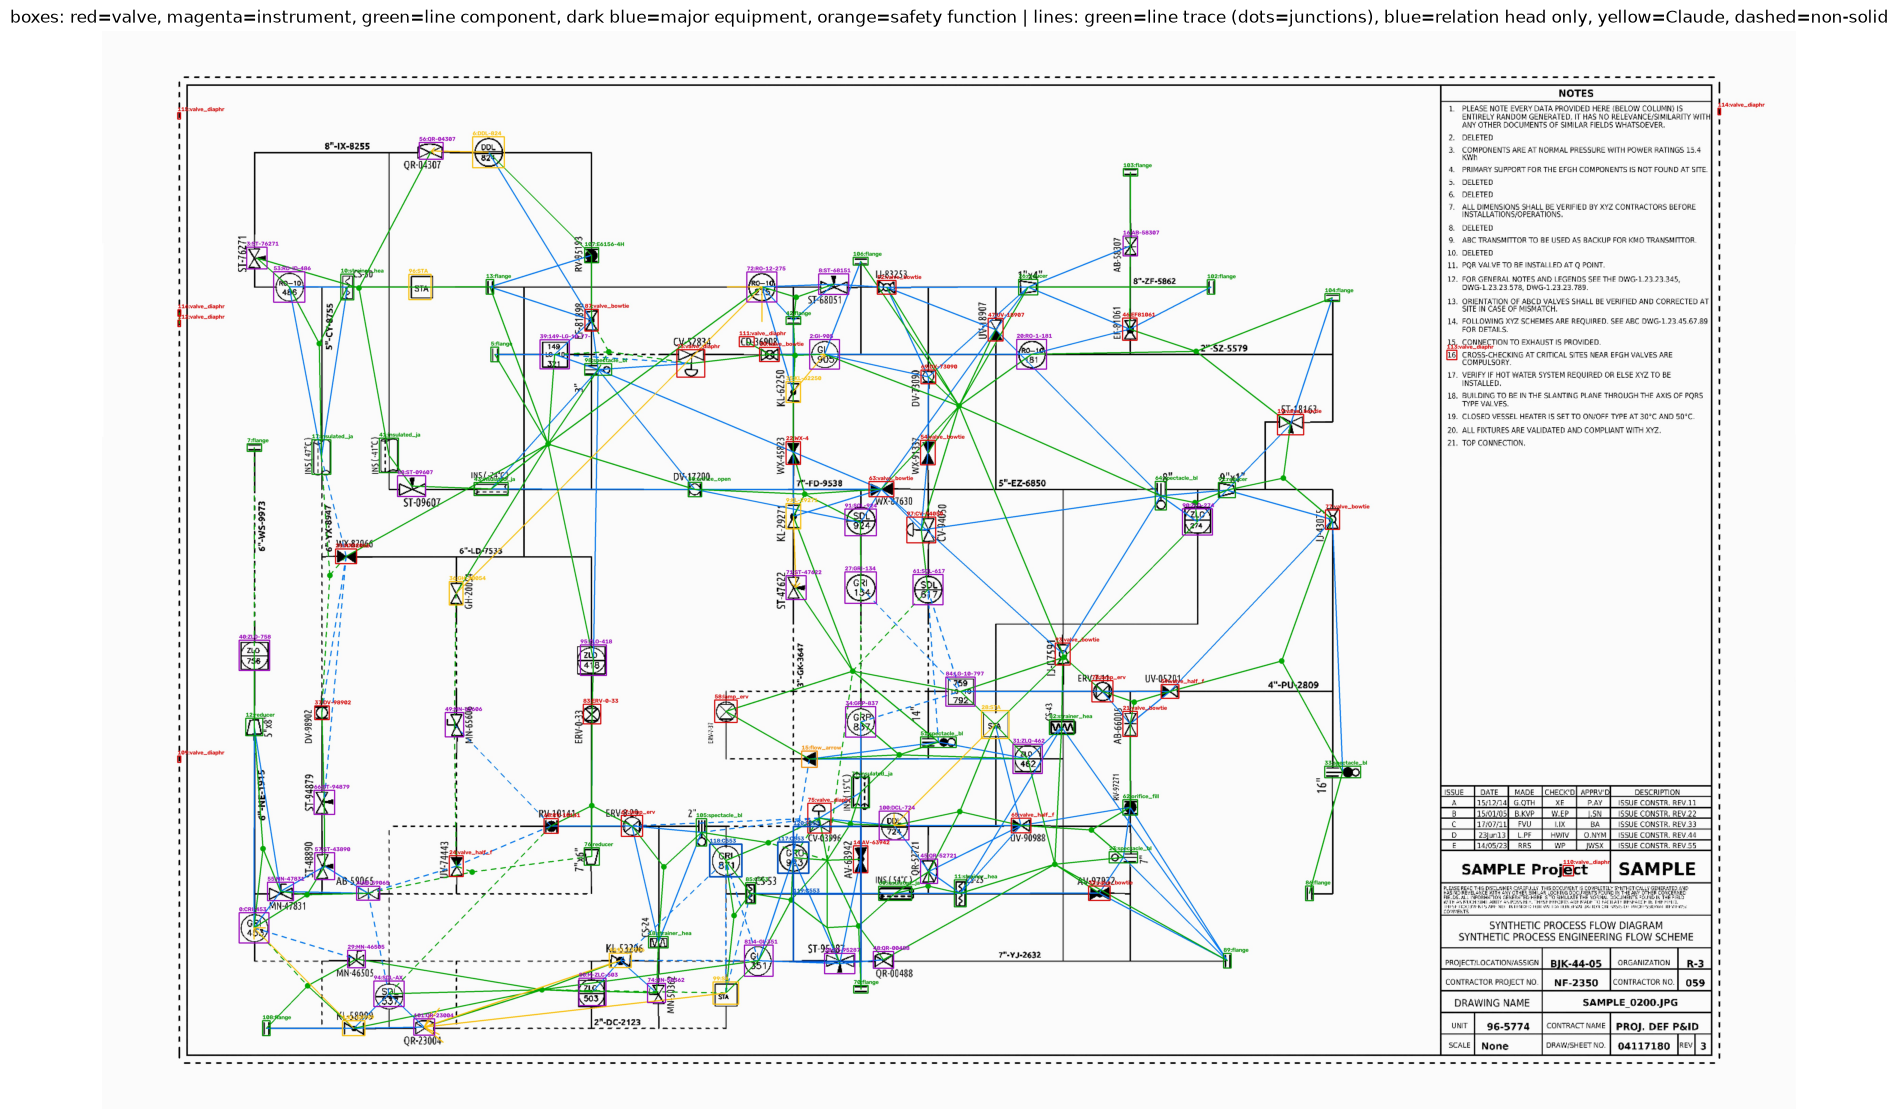

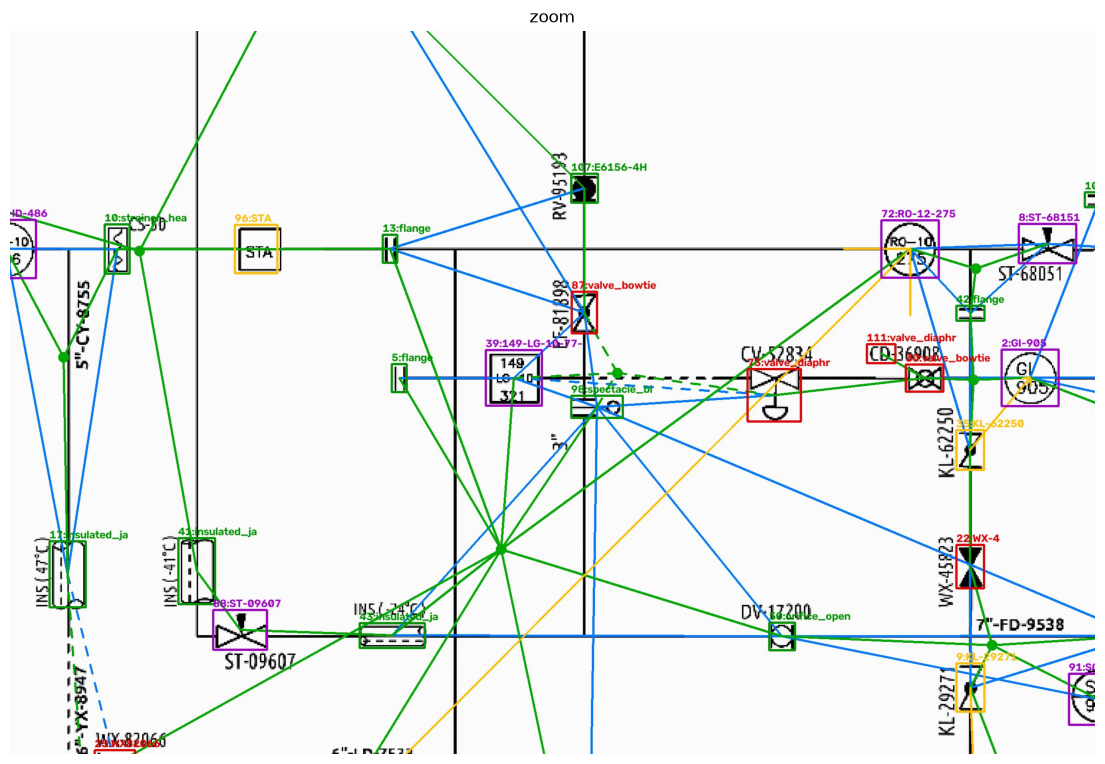

In [28]:
def latest_checkpoint():
    for name in ("relation_head.pt", "relation.pt", "best.pt"):          # self-trained checkpoints are opt-in (see §8c)
        if (cfg.run_dir / name).exists(): return cfg.run_dir / name
model = load_model(latest_checkpoint())
print("using", latest_checkpoint().name, "| relation head trained:", model.relation_trained)
demo = digitize(VAL[0]["img_path"], model)
SUMMARY = lambda r: {k: v for k, v in r.items() if k not in ("equipment", "connections", "safety_functions", "junctions")}
print(json.dumps(SUMMARY(demo), indent=1))
print(json.dumps(demo["equipment"][:3], indent=1))
ov = cv2.imread(str(cfg.out_dir / f"{Path(VAL[0]['img_path']).stem}_overlay.jpg"))
plt.figure(figsize=(22, 14)); plt.imshow(ov[..., ::-1]); plt.axis("off")
plt.title("boxes: red=valve, magenta=instrument, green=line component, dark blue=major equipment, orange=safety function | "
          "lines: green=line trace (dots=junctions), blue=relation head only, yellow=Claude, dashed=non-solid"); plt.show()
plt.figure(figsize=(14, 10)); plt.imshow(ov[600:2200, 800:3200, ::-1]); plt.axis("off"); plt.title("zoom"); plt.show()

z1.jpg {"sheet": "z1.jpg", "image_size": [1490, 896], "model": "PIDFormer", "pre_scale": 1.0, "detection_seconds": 0.49, "num_equipment": 37, "num_major_equipment": 2, "num_safety_functions": 3, "num_connections": 75, "texts": [{"text": "2", "box": [293.0, 673.0, 305.0, 691.0], "conf": 1.0}, {"text": "2", "box": [1024.0, 702.0, 1050.0, 728.0], "conf": 1.0}, {"text": "91", "box": [589.0, 197.0, 613.0, 217.0], "conf": 1.0}, {"text": "91", "box": [681.0, 203.0, 705.0, 223.0], "conf": 1.0}, {"text": "16", "box": [1356.0, 196.0, 1382.0, 220.0], "conf": 1.0}, {"text": "15", "box": [1226.0, 126.0, 1250.0, 150.0], "conf": 1.0}, {"text": "91", "box": [682.0, 286.0, 706.0, 310.0], "conf": 1.0}, {"text": "EAU", "box": [859.0, 269.0, 895.0, 289.0], "conf": 1.0}, {"text": "FE", "box": [1222.0, 100.0, 1250.0, 124.0], "conf": 1.0}, {"text": "FE", "box": [1356.0, 170.0, 1382.0, 194.0], "conf": 1.0}, {"text": "6", "box": [135.0, 563.0, 147.0, 579.0], "conf": 1.0}, {"text": "32-17", "box": [906.0, 688.0

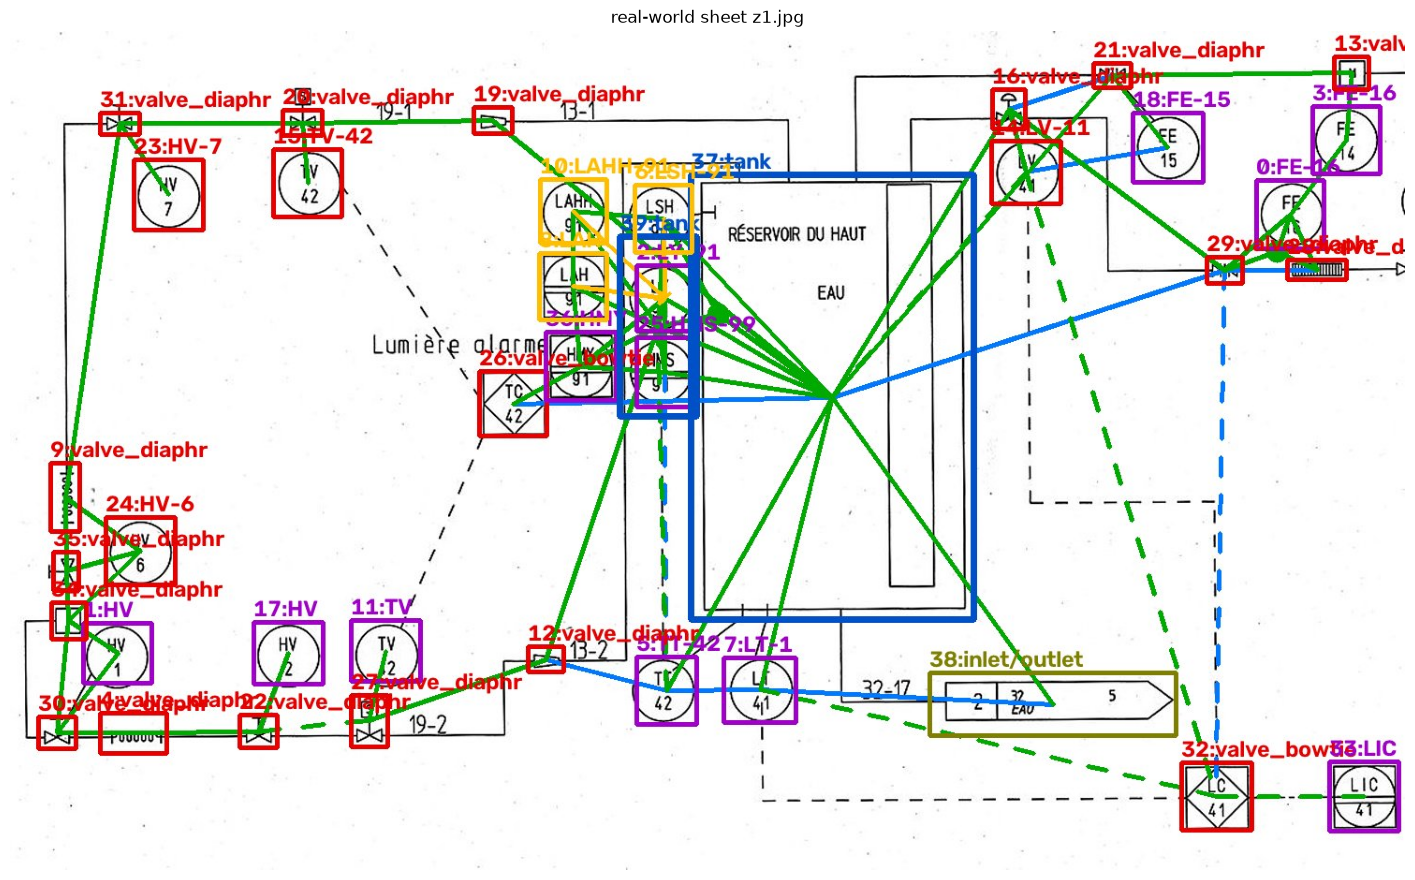

z10.jpg {"sheet": "z10.jpg", "image_size": [1490, 2250], "model": "PIDFormer", "pre_scale": 1.0, "detection_seconds": 0.56, "num_equipment": 65, "num_major_equipment": 4, "num_safety_functions": 16, "num_connections": 162, "texts": [{"text": "22", "box": [327.0, 453.0, 355.0, 473.0], "conf": 1.0}, {"text": "22", "box": [248.0, 460.0, 280.0, 484.0], "conf": 1.0}, {"text": "42", "box": [1168.0, 642.0, 1202.0, 668.0], "conf": 1.0}, {"text": "2", "box": [1331.0, 789.0, 1349.0, 811.0], "conf": 1.0}, {"text": "22", "box": [124.0, 874.0, 156.0, 902.0], "conf": 1.0}, {"text": "21", "box": [130.0, 1006.0, 162.0, 1032.0], "conf": 1.0}, {"text": "22", "box": [346.0, 702.0, 378.0, 732.0], "conf": 1.0}, {"text": "22", "box": [262.0, 532.0, 296.0, 560.0], "conf": 1.0}, {"text": "32", "box": [886.0, 1012.0, 916.0, 1036.0], "conf": 1.0}, {"text": "Using", "box": [235.2, 34.1, 353.8, 96.9], "conf": 1.0}, {"text": "31", "box": [734.0, 1158.0, 766.0, 1182.0], "conf": 1.0}, {"text": "21", "box": [49.0, 10

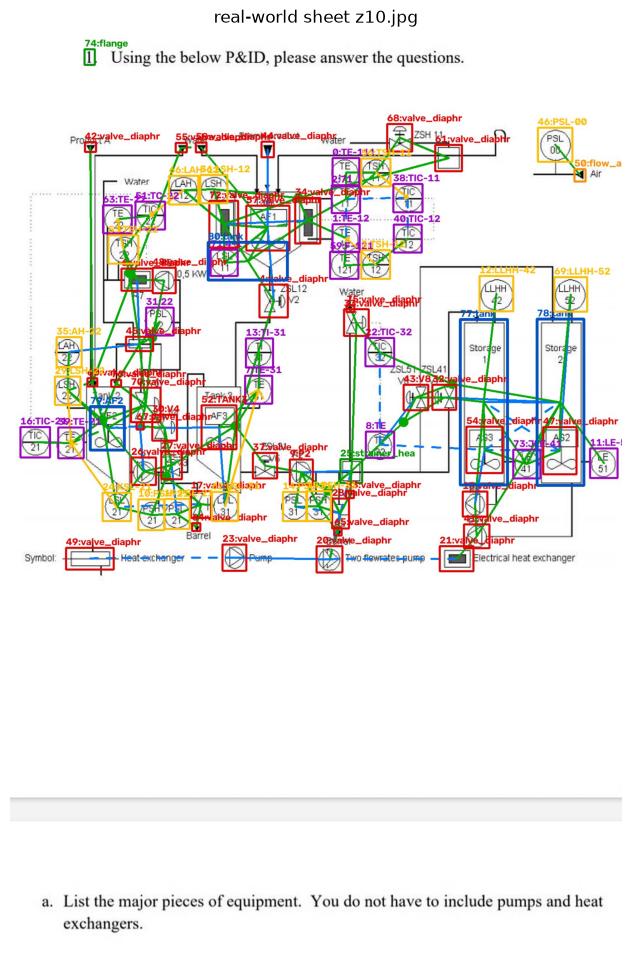

In [29]:
# Real-world sheets: major equipment, ISA roles and safety functions linked to transmitters
DEMO_REAL = [s for s in INDEX if s["source"] == "zenodo" and s["name"] in ("z1.jpg", "z10.jpg")] or VAL_Z[:1]
for s in DEMO_REAL:
    r = digitize(s["img_path"], model)
    print(s["name"], json.dumps(SUMMARY(r)))
    print("  major equipment:", [(e["id"], e["class_name"], e["tag"], e["evidence"]) for e in r["equipment"] if e["role"] == "major_equipment"])
    print("  safety functions:", [(f["tag"], f["description"], "->", f["linked_tag"], f["link_basis"]) for f in r["safety_functions"]])
    ov = cv2.imread(str(cfg.out_dir / f"{Path(s['img_path']).stem}_overlay.jpg"))
    plt.figure(figsize=(18, 12)); plt.imshow(ov[..., ::-1]); plt.axis("off"); plt.title(f"real-world sheet {s['name']}"); plt.show()

## 9. Evaluation (paper metrics)
On the validation sheets after stitching, as in the paper's Table III "Stitched" columns:
* **Symbol mAP@0.5** over the 32 fine classes and over the paper's 7 coarse classes. (mAP@0.5:0.95 is reported at patch level in §7.
  pycocotools caps that summary number at 100 detections per image, and a sheet holds ~120 symbols.)
* **Node AP@0.5**: class-agnostic. Every symbol counts as a node, so a wrong class is not penalised.
* **Edge mAP** (paper Algorithm A1): Hungarian-match predicted nodes to GT nodes (GIoU cost, IoU ≥ 0.5). A predicted edge is a TP
  when its matched GT nodes are connected; missed GT edges are FNs. AP comes from the confidence-ranked precision–recall curve.
  It is reported for the relation head, the line tracer and the fused `combined` score (§8, §9c). Edge labels on the synthetic sheets
  are the PID2Graph ground truth. The real Zenodo sheets only have line-trace pseudo-labels (tracer on GT boxes), so their edge numbers
  measure agreement with the tracer.

On the real Zenodo val sheets only the class-agnostic **node AP** applies (their boxes carry no symbol class).

Paper reference on Dataset-P&ID (stitched, Relationformer): symbols mAP 76.69, nodes AP 97.72, edges mAP 95.07.
On real drawings (PID2Graph OPEN100), the paper reports node AP 83.63.

In [30]:
def edge_match(pred_boxes, pred_edges, gt_boxes, gt_edges, iou_thr=0.5):
    """Paper Algorithm A1. Nodes are Hungarian-matched (GIoU cost, IoU >= iou_thr). pred_edges: {(i,j): (score, style)};
    gt_edges: {(i,j): style}. Returns rows (score, pred_style, tp_with_class, tp_class_agnostic) and GT counts per style."""
    pb, gb = torch.tensor(pred_boxes, dtype=torch.float32).reshape(-1, 4), torch.tensor(gt_boxes, dtype=torch.float32).reshape(-1, 4)
    g2p = {}
    if len(pb) and len(gb):
        cost = -generalized_box_iou(gb, pb).numpy(); iou = box_iou(gb, pb).numpy()
        r, c = linear_sum_assignment(cost)
        g2p = {int(a): int(b) for a, b in zip(r, c) if iou[a, b] >= iou_thr}
    p2g = {v: k for k, v in g2p.items()}
    gt = {(min(a, b), max(a, b)): st for (a, b), st in gt_edges.items()}
    rows = []
    for (a, b), (score, st) in pred_edges.items():
        ga, gb_ = p2g.get(a), p2g.get(b)
        key = (min(ga, gb_), max(ga, gb_)) if ga is not None and gb_ is not None else None
        hit = key in gt
        rows.append((score, st, hit and gt[key] == st, hit))
    return rows, Counter(gt.values())

def ap_from_rows(rows, n_gt):
    if n_gt == 0: return float("nan")
    rows = sorted(rows, key=lambda r: -r[0])
    tps = np.cumsum([r[1] for r in rows]); fps = np.cumsum([not r[1] for r in rows])
    if not len(rows): return 0.0
    rec, prec = tps / n_gt, tps / np.maximum(tps + fps, 1)
    return float(np.sum(np.diff(np.concatenate([[0], rec])) * prec))

def edge_metrics(all_rows, gt_counts):
    """mAP over line types (paper metric, class must match) + class-agnostic AP + precision/recall."""
    per = {st: ap_from_rows([(r[0], r[2]) for r in all_rows if r[1] == st], gt_counts.get(st, 0)) for st in ("solid", "dashed")}
    n_gt = sum(gt_counts.values()); tp = sum(r[3] for r in all_rows)
    return {"edge_mAP": float(np.nanmean([v for v in per.values()])) if any(not math.isnan(v) for v in per.values()) else float("nan"),
            "edge_AP_solid": per["solid"], "edge_AP_dashed": per["dashed"],
            "edge_AP_agnostic": ap_from_rows([(r[0], r[3]) for r in all_rows], n_gt),
            "edge_precision": tp / max(len(all_rows), 1), "edge_recall": tp / max(n_gt, 1), "n_gt_edges": n_gt}

def trace_edges_for_eval(gray, boxes):
    """Line-trace edges on detected boxes in the relation-head format {(i, j): (score, style)}."""
    return trace_pairs(trace_lines(gray, boxes))

def fuse_pairs(trace_e, rel_e, conf):
    """Fused edges (same rule as digitize): traced pairs re-ranked by the relation head, relation-only pairs with p >= rel_thr added."""
    out = {}
    for e in set(trace_e) | {e for e, v in rel_e.items() if v[0] >= cfg.rel_thr}:
        t, r = trace_e.get(e), rel_e.get(e)
        out[e] = (fuse_edge_score(t[0] if t else None, r[0] if r else None, False, min(conf[e[0]], conf[e[1]])), t[1] if t else r[1])
    return out

@torch.no_grad()
def evaluate_sheets(model, sheets, with_classes=True):
    m_fine = MeanAveragePrecision(box_format="xyxy", iou_type="bbox", max_detection_thresholds=[1, 10, 1000])
    m_sup = MeanAveragePrecision(box_format="xyxy", iou_type="bbox", max_detection_thresholds=[1, 10, 1000])
    m_node = MeanAveragePrecision(box_format="xyxy", iou_type="bbox", max_detection_thresholds=[1, 10, 1000])
    sup = np.array(SUPER_CLASS); embs, emb_labels = [], []
    rows = {"relation_head": [], "line_trace": [], "combined": []}; gt_counts = Counter(); gt_src = Counter()
    for k, s in enumerate(sheets):
        gray = cv2.imread(s["img_path"], cv2.IMREAD_GRAYSCALE)
        dets = detect_sheet(model, gray)
        nodes, member_of = merge_tile_detections(dets)
        gb = np.array(s["boxes"], np.float32).reshape(-1, 4); gl = np.array(s["labels"])
        P = lambda lab: {"boxes": torch.tensor(nodes["boxes"], dtype=torch.float32).reshape(-1, 4),
                         "scores": torch.tensor(nodes["scores"], dtype=torch.float32), "labels": torch.tensor(lab, dtype=torch.long)}
        G = lambda lab: {"boxes": torch.tensor(gb), "labels": torch.tensor(lab, dtype=torch.long)}
        if with_classes:
            m_fine.update([P(nodes["labels"])], [G(gl)])
            m_sup.update([P(sup[nodes["labels"]])], [G(sup[gl])])
        m_node.update([P(np.zeros(len(nodes["labels"])))], [G(np.zeros(len(gl)))])
        ge = sheet_edges(s)
        if ge is not None and len(ge):
            gt_e = {(int(a_), int(b_)): REL_CLASSES[int(t_)] for a_, b_, t_ in ge}
            gt_src[edge_label_source(s)] += 1
            kp = nodes["scores"] >= cfg.score_thr
            remap = {int(o): n for n, o in enumerate(np.where(kp)[0])}
            rel = {(remap[a_], remap[b_]): v for (a_, b_), v in relation_edges(model, dets, member_of).items() if a_ in remap and b_ in remap}
            r, cnt = edge_match(nodes["boxes"][kp], rel, gb, gt_e); rows["relation_head"] += r; gt_counts += cnt
            tre = trace_edges_for_eval(gray, nodes["boxes"][kp])
            r, _ = edge_match(nodes["boxes"][kp], tre, gb, gt_e); rows["line_trace"] += r
            r, _ = edge_match(nodes["boxes"][kp], fuse_pairs(tre, rel, nodes["scores"][kp]), gb, gt_e); rows["combined"] += r
        hi = nodes["scores"] > 0.5
        embs.append(nodes["emb"][hi]); emb_labels.append(nodes["labels"][hi])
        if k % 10 == 0: print(f"  sheet {k+1}/{len(sheets)}", flush=True)
    res = {"node_AP50": m_node.compute()["map_50"].item()}
    if with_classes:
        res.update(symbol_mAP50_32cls=m_fine.compute()["map_50"].item(), symbol_mAP50_7cls=m_sup.compute()["map_50"].item())
    if gt_counts:
        res["edge_label_source"] = dict(gt_src)
        for k_, v_ in rows.items(): res[k_] = edge_metrics(v_, gt_counts)
    return res, np.concatenate(embs), np.concatenate(emb_labels)

t0 = time.time()
SHEET_METRICS = {}
SHEET_METRICS["synthetic"], EMB, EMB_Y = evaluate_sheets(model, VAL_D[:2] if SMOKE else VAL_D)
SHEET_METRICS["real_zenodo"], _, _ = evaluate_sheets(model, VAL_Z[:2] if SMOKE else VAL_Z, with_classes=False)
print(f"stitched evaluation ({time.time()-t0:.0f}s):")
print(json.dumps(SHEET_METRICS, indent=1))
json.dump(SHEET_METRICS, open(cfg.run_dir / "sheet_metrics.json", "w"), indent=1)

  sheet 1/100


  sheet 11/100


  sheet 21/100


  sheet 31/100


  sheet 41/100


...

  sheet 81/100


  sheet 91/100


  sheet 1/20


  sheet 11/20


stitched evaluation (463s):
{
 "synthetic": {
  "node_AP50": 0.9900864362716675,
  "symbol_mAP50_32cls": 0.9993675947189331,
  "symbol_mAP50_7cls": 0.9975177645683289,
  "edge_label_source": {
   "pid2graph_gt": 100
  },
  "relation_head": {
   "edge_mAP": 0.6334034815834735,
   "edge_AP_solid": 0.7604478777185878,
   "edge_AP_dashed": 0.5063590854483592,
   "edge_AP_agnostic": 0.740647585466156,
   "edge_precision": 0.13410772375277083,
   "edge_recall": 0.8763992098579626,
   "n_gt_edges": 21262
  },
  "line_trace": {
   "edge_mAP": 0.8947665925270565,
   "edge_AP_solid": 0.9491096648333586,
   "edge_AP_dashed": 0.8404235202207544,
   "edge_AP_agnostic": 0.9721598664824305,
   "edge_precision": 0.9235163301792177,
   "edge_recall": 0.9960963220769448,
   "n_gt_edges": 21262
  },
  "combined": {
   "edge_mAP": 0.8909614653707139,
   "edge_AP_solid": 0.9655818512343385,
   "edge_AP_dashed": 0.8163410795070893,
   "edge_AP_agnostic": 0.9859081593439527,
   "edge_precision": 0.8331630246

### 9b. PID2Graph benchmark (paper Table III, "stitched")
The full `digitize()` pipeline runs on the **original** PID2Graph images with `auto_scale=True` (no ground-truth scale), without OCR or Claude.
Metrics follow the paper: node AP@0.5 (class-agnostic), symbol mAP@0.5 over the paper's 7 classes, and edge mAP (line type must match).
Large-equipment recall is also reported: the fraction of ground-truth tanks/pumps covered by a predicted item (IoU ≥ 0.5).
Predicted 7-class labels: small symbols use the `SUPER_CLASS` map, major equipment becomes `pump` (pump/compressor/turbine/blower types) or `tank`,
and connectors become `inlet/outlet`.

Edges are scored three ways: `relation_head` (its probability), `line_trace` (tracer score) and `combined` (the fused `score` of §8).
Our edge definition is symbol-to-symbol connectivity (connector and crossing nodes contracted). The paper also scores edges between
crossing/ankle nodes, so its edge numbers are not strictly comparable.

In [31]:
PUMP_WORDS = ("pump", "compressor", "turbine", "blower")
def coarse_of(e):
    if e["role"] == "major_equipment": return "pump" if any(w in e["class_name"] for w in PUMP_WORDS) else "tank"
    if e["role"] == "inlet_outlet": return "inlet/outlet"
    return e["super_class"]

def evaluate_p2g(model, sheets, label):
    m_node = MeanAveragePrecision(box_format="xyxy", iou_type="bbox", max_detection_thresholds=[1, 10, 1000])
    m_cls = MeanAveragePrecision(box_format="xyxy", iou_type="bbox", max_detection_thresholds=[1, 10, 1000], class_metrics=True)
    for mm in (m_node, m_cls): mm.warn_on_many_detections = False
    rows = defaultdict(list); gt_counts = Counter(); big_hit = Counter(); big_tot = Counter(); t0 = time.time()
    cid = {c: i for i, c in enumerate(SUPER_NAMES)}
    for k, s in enumerate(sheets):
        img, gml = p2g_original(s)
        gb, gl, ge, bg = p2g_graph(gml)
        res_all = digitize(img, model, use_ocr=False, use_claude=False, save=False, score_thr=0.05, auto_scale=True)
        items = res_all["equipment"] + [dict(f, role="safety_function", super_class="instrumentation", class_name="") for f in res_all["safety_functions"]]
        pb = np.array([e["bbox"] for e in items], np.float32).reshape(-1, 4)
        cen = (pb[:, :2] + pb[:, 2:]) / 2
        ok = np.ones(len(pb), bool)
        for x1, y1, x2, y2 in bg: ok &= ~((cen[:, 0] > x1) & (cen[:, 0] < x2) & (cen[:, 1] > y1) & (cen[:, 1] < y2))
        items = [e for e, o in zip(items, ok) if o]; pb = pb[ok]
        sc = torch.tensor([e["confidence"] for e in items], dtype=torch.float32)
        P = {"boxes": torch.tensor(pb), "scores": sc}; G = {"boxes": torch.tensor(gb)}
        m_node.update([{**P, "labels": torch.zeros(len(pb), dtype=torch.long)}], [{**G, "labels": torch.zeros(len(gb), dtype=torch.long)}])
        m_cls.update([{**P, "labels": torch.tensor([cid[coarse_of(e)] for e in items], dtype=torch.long)}],
                     [{**G, "labels": torch.tensor([cid[l] for l in gl], dtype=torch.long)}])
        if len(pb) and len(gb):
            iou = box_iou(torch.tensor(gb), torch.tensor(pb)).numpy()
            for g_, l_ in enumerate(gl):
                if l_ in ("tank", "pump"):
                    big_tot[l_] += 1; big_hit[l_] += int(iou[g_].max() >= 0.5)
        # edges: confident items only (as returned to users)
        res = digitize(img, model, use_ocr=False, use_claude=False, save=False, auto_scale=True)
        ib = np.array([e["bbox"] for e in res["equipment"]] + [f["bbox"] for f in res["safety_functions"]], np.float32).reshape(-1, 4)
        ids = [e["id"] for e in res["equipment"]] + [f["id"] for f in res["safety_functions"]]; pos = {i: n for n, i in enumerate(ids)}
        per = defaultdict(dict)
        for (a, b), c in symbol_pairs(res).items():
            if a not in pos or b not in pos: continue
            e = (min(pos[a], pos[b]), max(pos[a], pos[b]))
            if "relation_head" in c["methods"]: per["relation_head"][e] = (c["relation_score"], c["styles"].get("relation_head") or "solid")
            if c["trace_score"] is not None:
                per["line_trace"][e] = (c["trace_score"], c["styles"].get("line_trace") or c["styles"].get("adjacency") or "solid")
            per["combined"][e] = (c["score"], c["style"] or "solid")
        gt_e = {e: st for e, st in ge.items()}
        for meth in ("relation_head", "line_trace", "combined"):
            r_, cnt = edge_match(ib, per.get(meth, {}), gb, gt_e); rows[meth] += r_
        gt_counts += Counter(gt_e.values())
    n, c = m_node.compute(), m_cls.compute()
    per_cls = {SUPER_NAMES[int(i)]: round(float(v), 4) for i, v in zip(c["classes"], c["map_per_class"]) if v >= 0}
    out = {"sheets": len(sheets), "node_AP50": round(n["map_50"].item(), 4), "symbol_mAP50_7cls": round(c["map_50"].item(), 4),
           "AP50_per_class": per_cls,
           "large_equipment_recall": {k: f"{big_hit[k]}/{big_tot[k]}" for k in big_tot},
           **{f"edges_{m}": {k: (round(v, 4) if isinstance(v, float) else v) for k, v in edge_metrics(rows[m], gt_counts).items()}
              for m in ("relation_head", "line_trace", "combined")},
           "seconds": round(time.time() - t0)}
    print(label, json.dumps(out, indent=1))
    return out

P2G_RESULTS = {}
if USE_PID2GRAPH:
    for ck in [c for c in ("best.pt", "relation_head.pt", "selftrain_r0.pt") if (cfg.run_dir / c).exists()]:
        m_ = load_model(cfg.run_dir / ck)
        P2G_RESULTS[ck] = {
            "open100_heldout6": evaluate_p2g(m_, OPEN_HELD[:1] if SMOKE else OPEN_HELD, f"OPEN100 held-out 6 [{ck}]"),
            "open100_all12": evaluate_p2g(m_, TEST_O[:2] if SMOKE else TEST_O, f"OPEN100 all 12 [{ck}] (self-training saw 6 of them unlabelled)"),
            "p2g_synthetic_val": evaluate_p2g(m_, VAL_PS[:2] if SMOKE else VAL_PS, f"PID2Graph Synthetic val [{ck}]")}
    json.dump(P2G_RESULTS, open(cfg.run_dir / "p2g_metrics.json", "w"), indent=1)

load_model: re-initialised ['rel_head.layers.0.weight', 'rel_head.layers.2.bias', 'rel_head.layers.2.weight']


OPEN100 held-out 6 [best.pt] {
 "sheets": 6,
 "node_AP50": 0.722,
 "symbol_mAP50_7cls": 0.3503,
 "AP50_per_class": {},
 "large_equipment_recall": {
  "pump": "16/16",
  "tank": "15/15"
 },
 "edges_relation_head": {
  "edge_mAP": 0.0,
  "edge_AP_solid": 0.0,
  "edge_AP_dashed": NaN,
  "edge_AP_agnostic": 0.0,
  "edge_precision": 0.0,
  "edge_recall": 0.0,
  "n_gt_edges": 836
 },
 "edges_line_trace": {
  "edge_mAP": 0.3619,
  "edge_AP_solid": 0.3619,
  "edge_AP_dashed": NaN,
  "edge_AP_agnostic": 0.3613,
  "edge_precision": 0.4533,
  "edge_recall": 0.5694,
  "n_gt_edges": 836
 },
 "edges_combined": {
  "edge_mAP": 0.4251,
  "edge_AP_solid": 0.4251,
  "edge_AP_dashed": NaN,
  "edge_AP_agnostic": 0.4267,
  "edge_precision": 0.4533,
  "edge_recall": 0.5694,
  "n_gt_edges": 836
 },
 "seconds": 36
}


OPEN100 all 12 [best.pt] (self-training saw 6 of them unlabelled) {
 "sheets": 12,
 "node_AP50": 0.7534,
 "symbol_mAP50_7cls": 0.3452,
 "AP50_per_class": {},
 "large_equipment_recall": {
  "tank": "33/35",
  "pump": "16/16"
 },
 "edges_relation_head": {
  "edge_mAP": 0.0,
  "edge_AP_solid": 0.0,
  "edge_AP_dashed": NaN,
  "edge_AP_agnostic": 0.0,
  "edge_precision": 0.0,
  "edge_recall": 0.0,
  "n_gt_edges": 1852
 },
 "edges_line_trace": {
  "edge_mAP": 0.3342,
  "edge_AP_solid": 0.3342,
  "edge_AP_dashed": NaN,
  "edge_AP_agnostic": 0.334,
  "edge_precision": 0.4685,
  "edge_recall": 0.5653,
  "n_gt_edges": 1852
 },
 "edges_combined": {
  "edge_mAP": 0.373,
  "edge_AP_solid": 0.373,
  "edge_AP_dashed": NaN,
  "edge_AP_agnostic": 0.3733,
  "edge_precision": 0.4685,
  "edge_recall": 0.5653,
  "n_gt_edges": 1852
 },
 "seconds": 71
}


PID2Graph Synthetic val [best.pt] {
 "sheets": 50,
 "node_AP50": 0.6526,
 "symbol_mAP50_7cls": 0.24,
 "AP50_per_class": {},
 "large_equipment_recall": {
  "tank": "127/155",
  "pump": "88/89"
 },
 "edges_relation_head": {
  "edge_mAP": 0.0,
  "edge_AP_solid": 0.0,
  "edge_AP_dashed": 0.0,
  "edge_AP_agnostic": 0.0,
  "edge_precision": 0.0,
  "edge_recall": 0.0,
  "n_gt_edges": 1117
 },
 "edges_line_trace": {
  "edge_mAP": 0.2174,
  "edge_AP_solid": 0.2778,
  "edge_AP_dashed": 0.1569,
  "edge_AP_agnostic": 0.2699,
  "edge_precision": 0.4473,
  "edge_recall": 0.4709,
  "n_gt_edges": 1117
 },
 "edges_combined": {
  "edge_mAP": 0.2135,
  "edge_AP_solid": 0.2827,
  "edge_AP_dashed": 0.1442,
  "edge_AP_agnostic": 0.2749,
  "edge_precision": 0.4473,
  "edge_recall": 0.4709,
  "n_gt_edges": 1117
 },
 "seconds": 489
}


OPEN100 held-out 6 [relation_head.pt] {
 "sheets": 6,
 "node_AP50": 0.7656,
 "symbol_mAP50_7cls": 0.337,
 "AP50_per_class": {},
 "large_equipment_recall": {
  "pump": "14/16",
  "tank": "14/15"
 },
 "edges_relation_head": {
  "edge_mAP": 0.2413,
  "edge_AP_solid": 0.2413,
  "edge_AP_dashed": NaN,
  "edge_AP_agnostic": 0.2482,
  "edge_precision": 0.4604,
  "edge_recall": 0.3684,
  "n_gt_edges": 836
 },
 "edges_line_trace": {
  "edge_mAP": 0.375,
  "edge_AP_solid": 0.375,
  "edge_AP_dashed": NaN,
  "edge_AP_agnostic": 0.3749,
  "edge_precision": 0.4891,
  "edge_recall": 0.6172,
  "n_gt_edges": 836
 },
 "edges_combined": {
  "edge_mAP": 0.4588,
  "edge_AP_solid": 0.4588,
  "edge_AP_dashed": NaN,
  "edge_AP_agnostic": 0.4634,
  "edge_precision": 0.4147,
  "edge_recall": 0.6364,
  "n_gt_edges": 836
 },
 "seconds": 40
}


OPEN100 all 12 [relation_head.pt] (self-training saw 6 of them unlabelled) {
 "sheets": 12,
 "node_AP50": 0.7908,
 "symbol_mAP50_7cls": 0.3352,
 "AP50_per_class": {},
 "large_equipment_recall": {
  "tank": "31/35",
  "pump": "14/16"
 },
 "edges_relation_head": {
  "edge_mAP": 0.1983,
  "edge_AP_solid": 0.1983,
  "edge_AP_dashed": NaN,
  "edge_AP_agnostic": 0.2127,
  "edge_precision": 0.4458,
  "edge_recall": 0.351,
  "n_gt_edges": 1852
 },
 "edges_line_trace": {
  "edge_mAP": 0.3836,
  "edge_AP_solid": 0.3836,
  "edge_AP_dashed": NaN,
  "edge_AP_agnostic": 0.3836,
  "edge_precision": 0.5038,
  "edge_recall": 0.6112,
  "n_gt_edges": 1852
 },
 "edges_combined": {
  "edge_mAP": 0.4391,
  "edge_AP_solid": 0.4391,
  "edge_AP_dashed": NaN,
  "edge_AP_agnostic": 0.4448,
  "edge_precision": 0.4238,
  "edge_recall": 0.6323,
  "n_gt_edges": 1852
 },
 "seconds": 79
}


PID2Graph Synthetic val [relation_head.pt] {
 "sheets": 50,
 "node_AP50": 0.9782,
 "symbol_mAP50_7cls": 0.2303,
 "AP50_per_class": {},
 "large_equipment_recall": {
  "tank": "155/155",
  "pump": "89/89"
 },
 "edges_relation_head": {
  "edge_mAP": 0.3863,
  "edge_AP_solid": 0.4827,
  "edge_AP_dashed": 0.2899,
  "edge_AP_agnostic": 0.5176,
  "edge_precision": 0.8201,
  "edge_recall": 0.547,
  "n_gt_edges": 1117
 },
 "edges_line_trace": {
  "edge_mAP": 0.6241,
  "edge_AP_solid": 0.8743,
  "edge_AP_dashed": 0.3739,
  "edge_AP_agnostic": 0.7725,
  "edge_precision": 0.8095,
  "edge_recall": 0.8218,
  "n_gt_edges": 1117
 },
 "edges_combined": {
  "edge_mAP": 0.7334,
  "edge_AP_solid": 0.9183,
  "edge_AP_dashed": 0.5485,
  "edge_AP_agnostic": 0.8704,
  "edge_precision": 0.7535,
  "edge_recall": 0.9141,
  "n_gt_edges": 1117
 },
 "seconds": 496
}


OPEN100 held-out 6 [selftrain_r0.pt] {
 "sheets": 6,
 "node_AP50": 0.6587,
 "symbol_mAP50_7cls": 0.3469,
 "AP50_per_class": {},
 "large_equipment_recall": {
  "pump": "15/16",
  "tank": "13/15"
 },
 "edges_relation_head": {
  "edge_mAP": 0.0481,
  "edge_AP_solid": 0.0481,
  "edge_AP_dashed": NaN,
  "edge_AP_agnostic": 0.0563,
  "edge_precision": 0.5769,
  "edge_recall": 0.0718,
  "n_gt_edges": 836
 },
 "edges_line_trace": {
  "edge_mAP": 0.2526,
  "edge_AP_solid": 0.2526,
  "edge_AP_dashed": NaN,
  "edge_AP_agnostic": 0.2519,
  "edge_precision": 0.3434,
  "edge_recall": 0.4222,
  "n_gt_edges": 836
 },
 "edges_combined": {
  "edge_mAP": 0.2792,
  "edge_AP_solid": 0.2792,
  "edge_AP_dashed": NaN,
  "edge_AP_agnostic": 0.2808,
  "edge_precision": 0.3372,
  "edge_recall": 0.4222,
  "n_gt_edges": 836
 },
 "seconds": 32
}


OPEN100 all 12 [selftrain_r0.pt] (self-training saw 6 of them unlabelled) {
 "sheets": 12,
 "node_AP50": 0.6935,
 "symbol_mAP50_7cls": 0.3604,
 "AP50_per_class": {},
 "large_equipment_recall": {
  "tank": "26/35",
  "pump": "15/16"
 },
 "edges_relation_head": {
  "edge_mAP": 0.0436,
  "edge_AP_solid": 0.0436,
  "edge_AP_dashed": NaN,
  "edge_AP_agnostic": 0.0501,
  "edge_precision": 0.5541,
  "edge_recall": 0.0691,
  "n_gt_edges": 1852
 },
 "edges_line_trace": {
  "edge_mAP": 0.2402,
  "edge_AP_solid": 0.2402,
  "edge_AP_dashed": NaN,
  "edge_AP_agnostic": 0.2403,
  "edge_precision": 0.3507,
  "edge_recall": 0.4298,
  "n_gt_edges": 1852
 },
 "edges_combined": {
  "edge_mAP": 0.2725,
  "edge_AP_solid": 0.2725,
  "edge_AP_dashed": NaN,
  "edge_AP_agnostic": 0.2755,
  "edge_precision": 0.3419,
  "edge_recall": 0.4314,
  "n_gt_edges": 1852
 },
 "seconds": 68
}


PID2Graph Synthetic val [selftrain_r0.pt] {
 "sheets": 50,
 "node_AP50": 0.975,
 "symbol_mAP50_7cls": 0.2287,
 "AP50_per_class": {},
 "large_equipment_recall": {
  "tank": "155/155",
  "pump": "89/89"
 },
 "edges_relation_head": {
  "edge_mAP": 0.4164,
  "edge_AP_solid": 0.5021,
  "edge_AP_dashed": 0.3307,
  "edge_AP_agnostic": 0.5214,
  "edge_precision": 0.8008,
  "edge_recall": 0.5542,
  "n_gt_edges": 1117
 },
 "edges_line_trace": {
  "edge_mAP": 0.6114,
  "edge_AP_solid": 0.8679,
  "edge_AP_dashed": 0.3549,
  "edge_AP_agnostic": 0.7546,
  "edge_precision": 0.8188,
  "edge_recall": 0.8174,
  "n_gt_edges": 1117
 },
 "edges_combined": {
  "edge_mAP": 0.7431,
  "edge_AP_solid": 0.9203,
  "edge_AP_dashed": 0.5658,
  "edge_AP_agnostic": 0.869,
  "edge_precision": 0.7513,
  "edge_recall": 0.9141,
  "n_gt_edges": 1117
 },
 "seconds": 493
}


### 9c. Connectivity: line tracing vs. the relation head (replacement or ML enhancement?)

The relation head reached only ~0.15 edge mAP on the real OPEN100 plans. To see where connectivity breaks, the study below separates
**symbol detection** from **line following**:

* **GT boxes**: the connectivity method runs on the ground-truth symbol boxes, so it measures line following alone (live cell below).
* **Detected boxes**: the full `digitize()` pipeline (§9b). An edge can only be correct when *both* of its symbols are detected with IoU ≥ 0.5.
  On OPEN100 that holds for only **48 %** of the ground-truth edges ("reach"). Every method is capped by symbol detection there.

Development study (`relation_head.pt`; detected boxes on 12 OPEN100 / 20 PID2Graph Synthetic val / 10 Dataset-P&ID val sheets,
GT boxes on 12 / 50 / 30 sheets). Edge mAP (paper metric, line type must match):

| Method | GT boxes: OPEN100 | GT: Synthetic | GT: Dataset-P&ID | Detected: OPEN100 | Detected: Synthetic | Detected: Dataset-P&ID |
|---|---|---|---|---|---|---|
| Relation head alone | – | – | – | 0.16 | 0.42 | 0.57 |
| Previous run-length tracer (H/V runs, no skeleton) | 0.14 | 0.47 | 0.52 | 0.09 | 0.37 | 0.61 |
| **Skeleton tracer** (§3b) | **0.76** | **0.71** | **0.83** | 0.21 | 0.63 | 0.76 |
| Tracer + relation-head edges (union) | | | | 0.22 | 0.67 | 0.76 |
| **Fused score** (tracer × relation re-rank × √detection confidence, §8) | | | | **0.24** | **0.73** | 0.75 |
| Gradient-boosted edge classifier on all features, trained on synthetic sheets | | | | 0.21 | 0.75 | 0.77 |
| Fused score, symbols kept down to detection confidence 0.15 | | | | 0.26 | 0.74 | |

These are the numbers at the time of this study. §9d (small symbols) and §9e (dashed lines) improved them further; current values
are in §9e and §11.

What the study shows:
1. **Use line tracing as the connectivity method; don't rely on the relation head for it.** With correct boxes the skeleton tracer
   recovers 86 % of the OPEN100 edges at 82 % precision (mAP 0.76, 5.5× the previous tracer). The previous run-length tracer cut lines
   into horizontal and vertical runs, broke at diagonals and labelled many solid lines dashed. The relation head never sees more than a
   1024² tile and was trained on synthetic graphs only.
2. **Contours alone are not enough.** Connected components / contours join crossing lines. The gains come from the skeleton's
   junction geometry (crossing vs. T), bridging of dashes / broken crossings / L-corners, and attaching line *ends* (not any touching
   pixel) to symbols.
3. **The ML relation head is still useful as an enhancement.** Re-ranking traced edges by its probability and adding its confident extra
   edges adds +0.03 on OPEN100 and +0.11 on PID2Graph Synthetic (no change on Dataset-P&ID, where the tracer is already near its limit). A learned fusion classifier gains more on synthetic data but *loses* on
   real plans. It learns synthetic-specific cues, so it needs labelled real drawings before it is worth using.
4. **The remaining gap on real plans is symbol detection**, not line following: 0.76 with GT boxes vs. 0.25 with detected boxes, because
   half of the edges lose a symbol. §9d works on exactly this.


In [32]:
def _trace_gt_sheet(args):
    kind, s = args
    if kind == "p2g":
        img, gml = p2g_original(s); gb, _, ge, _ = p2g_graph(gml)
    else:
        img, gb = s["img_path"], np.array(s["boxes"], np.float32).reshape(-1, 4)
        ge = {(int(a), int(b)): REL_CLASSES[int(t)] for a, b, t in sheet_edges(s)}
    gray = cv2.imread(str(img), cv2.IMREAD_GRAYSCALE)
    rows, cnt = edge_match(gb, trace_pairs(trace_lines(gray, gb)), gb, ge)
    return rows, cnt

def connectivity_on_gt_boxes(sheets, kind):
    """Line tracer on ground-truth symbol boxes: edge metrics of line following alone."""
    res = [_trace_gt_sheet((kind, s)) for s in sheets]      # sequential: forking after CUDA init can deadlock
    rows = [r for rr, _ in res for r in rr]; cnt = sum((c for _, c in res), Counter())
    return {k: (round(v, 4) if isinstance(v, float) else v) for k, v in edge_metrics(rows, cnt).items()}

t0 = time.time()
GT_BOX_CONNECTIVITY = {}
if USE_PID2GRAPH:
    GT_BOX_CONNECTIVITY["OPEN100 (12)"] = connectivity_on_gt_boxes(TEST_O[:2] if SMOKE else TEST_O, "p2g")
    GT_BOX_CONNECTIVITY["PID2Graph Synthetic val (50)"] = connectivity_on_gt_boxes(VAL_PS[:2] if SMOKE else VAL_PS, "p2g")
GT_BOX_CONNECTIVITY["Dataset-P&ID val (30)"] = connectivity_on_gt_boxes(VAL_D[:2] if SMOKE else VAL_D[:30], "digitize")
print(f"skeleton line tracer on ground-truth boxes ({time.time() - t0:.0f}s)")
for k, v in GT_BOX_CONNECTIVITY.items():
    print(f"  {k:30s} edge mAP {v['edge_mAP']:.3f} (solid {v['edge_AP_solid']:.3f}, dashed {v['edge_AP_dashed']:.3f}) | "
          f"class-agnostic AP {v['edge_AP_agnostic']:.3f}, precision {v['edge_precision']:.3f}, recall {v['edge_recall']:.3f}")
json.dump(GT_BOX_CONNECTIVITY, open(cfg.run_dir / "gt_box_connectivity.json", "w"), indent=1)


skeleton line tracer on ground-truth boxes (201s)
  OPEN100 (12)                   edge mAP 0.777 (solid 0.777, dashed nan) | class-agnostic AP 0.778, precision 0.823, recall 0.859
  PID2Graph Synthetic val (50)   edge mAP 0.680 (solid 0.952, dashed 0.408) | class-agnostic AP 0.847, precision 0.881, recall 0.867
  Dataset-P&ID val (30)          edge mAP 0.889 (solid 0.951, dashed 0.827) | class-agnostic AP 0.975, precision 0.908, recall 0.999


### 9d. Real drawings: small symbols, lower-confidence terminals, containers

§9c left three next steps. Each was attacked with several ideas. **Selection rule:** an idea is kept only if it improves edge mAP on a
*dev* split (the 6 even OPEN100 plans) without hurting the 6 *held-out* odd plans or PID2Graph Synthetic val (20 plans). The held-out
plans were never used to choose. Ideas were screened offline on cached detections (`relation_head.pt`, fused edge score of §8);
the winners were then re-validated through `digitize()` / `evaluate_p2g` (last table).

**Diagnosis.** At the old threshold (0.35), 57 % of the 451 OPEN100 flow arrows were lost: 28 % detected but boxed with IoU < 0.5, 29 % not
detected. On real plans the detector draws tiny glyphs (arrows, small valves) **~1.33× too large** (instruments and equipment ~1.0×; on
the synthetic plans small symbols are 1.0×). For a 13 px arrow that is enough to fail the IoU ≥ 0.5 match.

**1. Small-symbol detection** (edge mAP dev / held-out / synthetic; baseline 0.254 / 0.247 / 0.738)

| Idea | Dev | Held-out | Synth. | |
|---|---|---|---|---|
| Shrink all small boxes ×0.85 (box-size calibration) | 0.446 | 0.451 | 0.431 | ✗ fits OPEN100's box convention, breaks synthetic |
| Snap small boxes to glyph ink (pipe runs removed, padded window) | 0.148 | 0.136 | 0.687 | ✗ |
| Snap only flow arrows / tighten inside the box | 0.256 / 0.257 | 0.254 / 0.226 | 0.738 / 0.736 | ✗ no gain |
| Lower threshold for arrows only (0.25 … 0.1) | 0.254 | 0.248 | 0.738 | ✗ no gain |
| Zoom ×2 pass: add new small symbols | 0.309 | 0.285 | 0.756 | ✓ |
| Zoom ×2 pass: replace small boxes + add | 0.334 | 0.382 | 0.719 | ✗ hurts synthetic |
| **Zoom ×2 pass: replace a small box only by a tighter zoomed box + add** | **0.399** | **0.414** | **0.739** | **✓ selected** |

**2. Lower-confidence detections as line terminals** (on top of 1; baseline 0.399 / 0.414 / 0.739)

| Idea | Dev | Held-out | Synth. | |
|---|---|---|---|---|
| Report + trace threshold 0.25 / 0.15 | 0.418 / 0.387 | 0.445 / 0.412 | 0.721 / 0.739 | ✗ |
| Trace with ≥ 0.25 terminals, report only ≥ 0.35 | 0.361 | 0.418 | 0.713 | ✗ |
| Keep low-confidence symbols only when the tracer finds them in-line | 0.356 | 0.419 | 0.737 | ✗ |
| Connect reported symbols *through* low-confidence terminals | 0.371 | 0.425 | 0.747 | ✗ |
| Edge score × confidence instead of √confidence (thr 0.25) | 0.425 | 0.446 | 0.718 | ✗ hurts synthetic |
| **Report + trace threshold 0.30** (`cfg.score_thr`) | **0.426** | **0.452** | **0.737** | **✓ selected** |

**3. Tracing inside containers** (large boxes with symbols inside). Measured on ground-truth boxes, all 12 OPEN100 plans (class-agnostic AP):
erase whole box (current) **0.777** · erase only a 0.25 / 0.5-symbol border band 0.776 / 0.777 · band + keep only interior ink reaching an
inner symbol 0.774 · separate trace inside each container 0.777 · the same, keeping nets that touch the container frame 0.774.
**None improves, so nothing was changed.** Containers with inner symbols occur on 7 of 12 plans but touch only ~1.5 % of the edges, and
most remaining misses are elsewhere (arrow-to-arrow edges along headers).

**Validation through the full pipeline** (before the §9e dashed-line fix, which adds about +0.01 on OPEN100) (`evaluate_p2g`, `relation_head.pt`, edge mAP of the fused score; node AP in brackets)

| | OPEN100 held-out 6 | OPEN100 all 12 | PID2Graph Synthetic val 50 |
|---|---|---|---|
| Before (threshold 0.35, no zoom) | 0.229 (0.68) | 0.239 (0.71) | 0.722 (0.98) |
| Zoom pass only | 0.440 (0.77) | 0.414 (0.79) | 0.733 (0.98) |
| Threshold 0.30 only | 0.241 (0.68) | 0.252 (0.71) | 0.728 (0.98) |
| **Both (now the default)** | **0.445** (0.77) | **0.425** (0.79) | **0.733** (0.98) |

The zoom pass roughly doubles detection time on sheets that contain small symbols (it is skipped when there are none);
`digitize(..., zoom=None)` turns it off.


### 9e. Pushing Dataset-P&ID and the real Zenodo sheets towards 0.80

Same protocol as §9d: ideas are chosen on **training** sheets (40 Dataset-P&ID train sheets with PID2Graph ground truth, 25 Zenodo train
sheets) and confirmed on the validation sheets reported in §9 (100 Dataset-P&ID, 16 Zenodo with edges). Starting point (§9, fused
score): Dataset-P&ID val **0.784**, Zenodo val **0.337**.

**Dataset-P&ID: the gap was dashed lines.** Connections were almost all found (class-agnostic AP 0.986, solid AP 0.935); dashed AP was
0.633. 864 *solid* connections were labelled dashed. Cause: vertical text next to a symbol (`INS (-33°C)`, tag letters) is gap-closed into a
short segment with several filled gaps, so the symbol "attaches through a dashed segment".

| Idea (edge mAP, Dataset-P&ID train → val) | Train | Val | Zenodo val | |
|---|---|---|---|---|
| Baseline | 0.749 | 0.784 | 0.337 | |
| Dash regularity: filled gaps must have similar lengths (signal-processing periodicity test), CV < 0.5 / 0.8 | 0.780 / 0.761 | 0.812 / 0.790 | 0.330 / 0.339 | ✗ smaller gain |
| **A dashed segment must be ≥ 1 symbol long** (≥ 0.5: 0.842 / 0.874) | **0.865** | **0.891** | **0.412** | **✓ selected** |
| + relation head decides the line type when p ≥ 0.9 / 0.7 | 0.918 / – | 0.935 / 0.920 | 0.313 / 0.228 | ✗ the synthetic-trained head is wrong on real dashed lines |

The selected rule also helps the real OPEN100 plans (held-out 0.452 → 0.462). Zenodo numbers in this table use pseudo-labels regenerated with
the same tracer version (the notebook does this through `edges_trace_v3`).

**Zenodo: why 0.80 is not reachable this way.** Zenodo has no ground-truth connections. Its edge labels are the tracer's own output on the
ground-truth boxes, so the tracer scores **1.0 on ground-truth boxes**. The 0.41 measures only how detection errors change the traced nets,
and the detector already matches ~82 % of Zenodo validation symbols. What was tried (Zenodo train / val, after the dashed fix 0.636 / 0.412):

| Idea | Train | Val | |
|---|---|---|---|
| Score threshold 0.20 | 0.639 | 0.445 | ✗ no train gain |
| Test-time augmentation: horizontal + vertical flips, add new boxes | 0.631 | 0.439 | ✗ |
| Extra pass at 1.5× / 0.67× scale | 0.600 / 0.613 | 0.416 / 0.369 | ✗ |
| Consensus voting: low-score boxes kept when ≥ 2 / ≥ 3 other passes agree (ensemble detection) | 0.646 / 0.649 | 0.453 / 0.439 | ✗ +0.01 for ~6× detection time |
| Full `digitize()` incl. the major-equipment finder (§8a) | 0.635 | 0.412 | ✗ no change |
| The §9d zoom pass (default in `digitize`) | 0.546 | 0.305 | ✗ see below |
| **Segment Anything (Meta SAM ViT-B)**: box prompt → mask → tighter box for small symbols | 0.324 | 0.186 | ✗ |

**Zoom pass and SAM: two real datasets disagree.** Both tighten boxes of small glyphs and find small symbols the base pass missed. On OPEN100
this is right: its annotators box flow arrows tightly and label them as nodes (SAM: held-out 0.29 → 0.37 without zoom; zoom: 0.45). Zenodo's
annotators boxed symbols more loosely and left many small glyphs (flow arrows) unlabelled, so every extra small node splits a traced net
and is scored as an error there. Symptom of a definition difference, not of a detector bug. `digitize()` keeps `zoom=2.0` because
OPEN100 is the only real benchmark with true connectivity. Use `digitize(..., zoom=None)` when small glyphs such as flow arrows should not
become graph nodes. SAM is not used: it adds a 94 M-parameter model and does not beat the zoom pass on OPEN100.

**Final validation** (this notebook run, `relation_head.pt`, edge mAP of the fused score; §9 / §9b / §9c outputs above):

| | Before §9e | After §9e |
|---|---|---|
| Dataset-P&ID val (100) | 0.784 (dashed 0.633) | **0.891** (dashed 0.816; line tracer alone 0.895) |
| Zenodo val (16, tracer pseudo-labels) | 0.337 | **0.412** |
| OPEN100 all 12 / held-out 6 | 0.425 / 0.445 | **0.439 / 0.459** |
| PID2Graph Synthetic val (50), detected boxes | 0.733 | 0.733 |
| Tracer on ground-truth boxes: OPEN100 / Synthetic / Dataset-P&ID | 0.758 / 0.709 / 0.831 | 0.777 / **0.680** / 0.889 |

One trade-off: on PID2Graph Synthetic with *ground-truth* boxes, dashed AP drops (0.457 → 0.408). Some of its dashed signal lines are shorter
than one symbol between two instruments, and those now read as solid. With detected boxes the fused score is unchanged there.

**Where real gains on Zenodo-like drawings would come from:** labelled connectivity for real drawings (a few plans annotated in the
PID2Graph `.graphml` format, or LLM set-of-marks labels, §3/§12). That would also give a real target to measure against instead of the
tracer's own output.


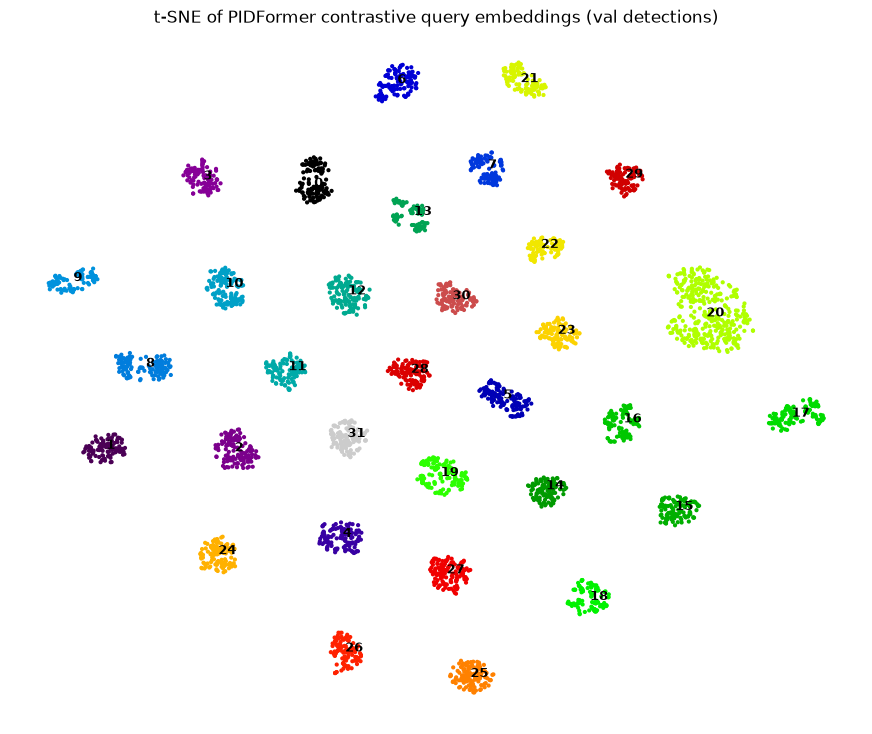

In [33]:
# Contrastive embedding space (compare with the paper's ResNet-feature t-SNE, Fig. A2)
from sklearn.manifold import TSNE
if len(EMB) < 100:
    print("too few confident detections for t-SNE (train longer)")
else:
    sel = np.random.RandomState(0).permutation(len(EMB))[:4000]
    xy = TSNE(n_components=2, init="pca", perplexity=30, random_state=0).fit_transform(EMB[sel])
    plt.figure(figsize=(11, 9))
    plt.scatter(xy[:, 0], xy[:, 1], c=EMB_Y[sel], cmap="nipy_spectral", s=4)
    for c in np.unique(EMB_Y[sel]):
        m = EMB_Y[sel] == c; plt.text(*np.median(xy[m], 0), str(c), fontsize=9, weight="bold")
    plt.title("t-SNE of PIDFormer contrastive query embeddings (val detections)"); plt.axis("off"); plt.show()

## 10. Use on your own P&IDs
```python
model = load_model("runs/pidformer/best.pt")
result = digitize("my_pid.png", model, use_ocr=True, use_claude=True)   # -> outputs/my_pid.json + overlay
for e in result["equipment"]:
    print(e["tag"], e["class_name"], e["center"], "->", e["connected_tags"])
```
**Notes for real drawings.** Use `auto_scale=True` (or pass `pre_scale`) so symbols reach the trained size (~72 px before `input_scale`).
Thanks to the Zenodo sheets the detector also finds symbols outside the 32 synthetic classes (pumps, tanks, …). Their
`class_name` is then the nearest synthetic class with lower confidence. To get real class names, label a few sheets with your
vocabulary and fine-tune (change `cfg.num_classes`); the contrastive embeddings give a good start for new classes.
The Zenodo archive also ships 100-class symbol crops for its test sheets (`3__Stage-2/2__Test_data`), usable for few-shot evaluation.

**Possible next steps.** Pseudo-labels from Claude on more sheets → a better relation head. Self-training on unlabelled real P&IDs
with EMA-teacher pseudo boxes. Line-type classification (solid/dashed) as a second relation class, as in the paper.

In [34]:
# Batch-digitize all validation sheets to JSON
if not SMOKE:
    for s in VAL_D[:5] + VAL_Z[:5]:
        r = digitize(s["img_path"], model, use_claude=False)
        print(s["name"], r["num_equipment"], "equipment,", r["num_connections"], "connections")

2.jpg 112 equipment, 321 connections


5.jpg 108 equipment, 224 connections


6.jpg 132 equipment, 277 connections


8.jpg 148 equipment, 270 connections


11.jpg 125 equipment, 261 connections


z0.jpg 11 equipment, 7 connections


z11.jpg 52 equipment, 102 connections


z15.jpg 72 equipment, 103 connections


z103.jpg 17 equipment, 39 connections


z124.jpg 8 equipment, 2 connections


## 11. Capability review against the paper (arXiv:2411.13929)

Results below come from the run stored in this notebook (`runs/pidformer/p2g_metrics.json`, `sheet_metrics.json`). Default model:
`relation_head.pt`. Paper numbers are the Relationformer "stitched" results (Table III).

| Paper capability | Status here | Result (ours) | Paper |
|---|---|---|---|
| Relationformer: Deformable-DETR detector + `[rln]` token + pairwise relation MLP | ✅ (§5). Hybrid encoder by default, the paper's deformable encoder via `cfg.encoder`. The relation MLP gets extra line evidence (pooled features along candidate pipe routes) | | |
| Two edge classes: solid / non-solid | ✅ 3-way relation head, trained on PID2Graph ground-truth graphs; skeleton line tracer (§3b) | Dataset-P&ID val edge mAP: relation head 0.63 · line tracer 0.90 (solid 0.95, dashed 0.84) · **fused 0.89** (0.78 before §9e) | 95.07 |
| Crossing / ankle / border node classes | ⚠️ Not predicted as network classes. Crossings are resolved by the skeleton line tracer (branch geometry at each junction) and by GT contraction (straight through 4-way crossings); multi-way networks become `junctions`; border edges come from sheet-level merging of tiles | | |
| 7 symbol classes (general, tank, valve, instrumentation, pump, inlet/outlet, arrow) | ⚠️ 32 fine Digitize-PID classes mapped to the 7. Tank/pump/inlet-outlet come from the major-equipment finder (no class-labelled real training data) | OPEN100 7-class mAP 0.41 | 73.14 |
| Node detection (class-agnostic AP@0.5) | ✅ | Dataset-P&ID 0.99 · PID2Graph Synthetic 0.98 · **OPEN100 0.79** (0.71 before the §9d zoom pass) | 97.72 · 96.89 · 83.63 |
| Edge detection on real plans (OPEN100) | ⚠️ Limited by symbol detection (§9c, §9d) | edge mAP **0.44** fused (line tracer 0.38, relation head 0.20; 0.24 before §9d, 0.15 originally). With ground-truth symbol boxes the tracer reaches **0.78** | 75.46 |
| Patching with ≥ 50 % overlap; merge = border decay → filter → NMS → WBF | ✅ (§8) | | |
| Graph clean-up (self-loops, unconnected nodes) | ✅ self-loops removed. Unconnected symbols are kept on purpose (every piece of equipment is reported) | | |
| Modular baseline (detector + EAST/CRAFT text + Hough lines) | ✅ as a component: EasyOCR + skeleton line tracer (solid/dashed). The tracer is the main connection source; the relation head re-ranks it | | |
| Metrics: symbol mAP, node AP, edge mAP with Hungarian node matching (Alg. A1) | ✅ (§9, §9b) | | |
| Datasets: PID2Graph OPEN100 / Synthetic / Dataset-P&ID graphs | ✅ all three (§2c) | | |
| 60 private real-world annotated P&IDs (37 % of training patches) | ❌ not public. Substituted by 72 real Zenodo sheets (boxes only, class-free) and self-training | | |
| Pre-training on 2000 synthetic plans ("Synthetic 700" templates) | ❌ not public. PID2Graph Synthetic (200 train plans) is used instead | | |
| Augmentation: rotation, flips, brightness/contrast, scaling, blur | ✅ (§4) | | |

**Requested extensions**
| Capability | Result |
|---|---|
| Large / unseen equipment (tanks, vessels, pumps …) | PID2Graph Synthetic: tanks **155/155**, pumps **89/89** recovered. OPEN100: tanks 31/35, pumps 14/16. Also found on Zenodo sheets (e.g. `RÉSERVOIR`, `Storage 1/2`) |
| Alarms / SIS are not equipment, linked to transmitters | ISA-5.1 decoding, e.g. `LAHH-91`, `LSH-91`, `LAH` → linked to `LY-91` (loop number / connection), `TSH-12` → `TE-12`. Some switches stay unlinked when no matching instrument tag is read |
| Claude pseudo-labels for the relation head | Implemented (§3, §8a). Not exercised in this run (no API key); PID2Graph ground truth was used instead |
| EMA-teacher self-training on unlabelled real P&IDs | Implemented (§8c) but **did not help here**. On held-out OPEN100 plans node AP falls 0.77 → 0.66 and edge mAP 0.44 → 0.27. With only 6 unlabelled plans the teacher's errors are reinforced. The checkpoint is opt-in |
| Line-type relation classes | ✅ solid/dashed. The skeleton tracer now beats the relation head on both (Dataset-P&ID solid 0.95 vs 0.76, dashed 0.84 vs 0.51). `digitize()` takes the line type from the tracer and fuses the scores |
| Line tracing for connectivity (OpenCV) | ✅ §3b / §9c. Skeleton + junction geometry (crossing vs. T), dash / crossing / corner gap bridging. PID2Graph Synthetic val 0.48 → **0.72**, OPEN100 0.15 → **0.24** (→ 0.44 with §9d/§9e), Dataset-P&ID 0.63 → **0.89** with the §9e dashed-line fix (fused score vs. the best earlier method) |

**Main gap vs. the paper**: graph extraction on *real* drawings (OPEN100 edge mAP 0.44 vs 75.46). Line following is no longer the
bottleneck: with ground-truth symbol boxes the tracer reaches 0.78 on OPEN100. With detected symbols, about a third of the ground-truth
edges still lose a symbol, mostly flow arrows (§9d). The paper fine-tunes on 60 annotated real P&IDs. Most promising next steps:
1. Train on real plans: annotate a few in the PID2Graph `.graphml` format, or use Claude set-of-marks labels (§3) on the 72 Zenodo
   sheets and your own drawings. This also fixes the over-sized boxes of tiny glyphs at the source.
2. Tracing inside containers did not help in §9d. Most remaining misses are arrow-to-arrow edges along headers.
3. Zenodo has no connectivity ground truth (its edge labels are the tracer's own output, §9e), so real progress there needs labelled
   real drawings first. Segment Anything, flip TTA and ensemble voting did not help (§9e).

## 12. Digitize and connect your own (unlabelled) P&ID drawings

This section runs the trained pipeline on **a folder of real drawings** (subfolders included). The drawings are assumed to be
**unlabelled**. For every drawing (and every page of a PDF) it writes a graph JSON and an overlay image. It then **connects the drawings
into one plant-level graph**:
* **same tag on several sheets**: equipment/instruments carrying the same tag (e.g. `P-101` on the process sheet and on the
  pump-detail sheet) are linked as the same physical item;
* **off-page connectors**: inlet/outlet connector boxes whose text shares a reference (line number or destination drawing number,
  e.g. `100-4122`) are linked across sheets, so pipes continue from one drawing to the next.

An **optional multimodal LLM** refines tags, connections and major equipment (set-of-marks prompting, §3/§8a). The LLM call is
provider-neutral, so the same pipeline runs on:

| `provider` | Backend | Models | Credentials (placeholder or environment variable) |
|---|---|---|---|
| `"anthropic"` | Claude API (`anthropic` SDK) | `claude-sonnet-5-5` (default), `claude-opus-5-5`, … | `anthropic_api_key` / `ANTHROPIC_API_KEY` |
| `"azure"` + `azure_api="foundry"` | Claude on **Microsoft Foundry** (`anthropic.AnthropicFoundry`) | your Foundry Claude deployment | `azure_api_key` + `azure_foundry_resource` / `ANTHROPIC_FOUNDRY_API_KEY`, `ANTHROPIC_FOUNDRY_RESOURCE` |
| `"azure"` + `azure_api="openai"` | **Azure OpenAI** (`openai.AzureOpenAI`) | vision deployments such as GPT-4o / GPT-4.1 | `azure_api_key`, `azure_openai_endpoint`, `azure_deployment` / `AZURE_OPENAI_API_KEY`, `AZURE_OPENAI_ENDPOINT` |
| `"bedrock"` | **Amazon Bedrock**: Claude via `anthropic.AnthropicBedrockMantle`, any other multimodal model (Amazon Nova, Llama 3.2 Vision, …) via the boto3 Converse API | e.g. `anthropic.claude-sonnet-5-5`, `amazon.nova-pro-v1:0` | AWS region + profile or keys (standard AWS credential chain) |
| `"none"` | no LLM: detector + OCR + relation head + line tracer only | | |

The wrapper asks every provider for JSON matching a schema: native structured outputs where available (Claude, Azure OpenAI), and
otherwise schema-in-prompt with tolerant parsing and one retry. Responses are cached in `data/cache/claude/`, keyed by provider/model and
drawing, so re-runs cost nothing. Token usage is printed at the end.

### How to use
1. Put your drawings (PNG, JPG, TIF/TIFF incl. multi-page, BMP, PDF) in a folder; any subfolder depth works.
2. In the next cell, set `DRAWINGS_DIR` and, if you want LLM refinement, fill `LLM_CONFIG` (or export the environment variables).
   Leave the `<...>` placeholders to run without an LLM.
3. Run the cells. Results go to `OUTPUT_DIR`, mirroring the input folder structure:
   * `<drawing>.json` / `<drawing>_overlay.jpg`: per drawing (format of §8b, plus `connector_text` on off-page connectors and all OCR `texts`)
   * `equipment.csv`, `safety_functions.csv`, `connections.csv`: everything across all drawings, one row per item
   * `plant_graph.graphml` (open in Gephi / yEd / NetworkX) and `plant_graph.json`: the connected multi-drawing graph
   * `cross_sheet_links.csv`: the links between drawings and why they were made
4. Optional: set `LEARN_FROM_LLM = True` to fine-tune the relation head on the LLM's connection labels for *your* drawings (relation
   stage B of §8c). This is the most direct way to improve connectivity on real drawings (§11).

Scale: drawings are auto-scaled (`auto_scale=True`) so symbols reach the size the model was trained on. Scanned PDFs are rendered at
`PDF_DPI` (default 300).

In [35]:
# ---------------------- user configuration (placeholders) ----------------------
DRAWINGS_DIR = Path(os.environ.get("PID_DRAWINGS_DIR", "<PATH_TO_YOUR_DRAWINGS_FOLDER>"))   # folder with your P&IDs (searched recursively)
OUTPUT_DIR = cfg.out_dir / "real_drawings"
PDF_DPI = 300
MAX_DRAWINGS = None            # e.g. 20 to try a few first
LEARN_FROM_LLM = False         # fine-tune the relation head on LLM connection labels of these drawings (needs an LLM)

@dataclass
class LLMConfig:
    provider: str = "anthropic"                     # "anthropic" | "azure" | "bedrock" | "none"
    model: str = "claude-sonnet-5-5"                # Anthropic model id, Foundry deployment name, Bedrock model id, or Azure OpenAI deployment
    # --- Anthropic (Claude API) ---
    anthropic_api_key: str = "<YOUR_ANTHROPIC_API_KEY>"
    # --- Azure ---
    azure_api: str = "foundry"                      # "foundry" (Claude on Microsoft Foundry) | "openai" (Azure OpenAI, e.g. GPT-4o)
    azure_api_key: str = "<YOUR_AZURE_API_KEY>"
    azure_foundry_resource: str = "<YOUR_FOUNDRY_RESOURCE_NAME>"            # Foundry: resource name (https://<resource>.services.ai.azure.com)
    azure_openai_endpoint: str = "https://<YOUR_RESOURCE>.openai.azure.com"  # Azure OpenAI endpoint
    azure_openai_api_version: str = "<YOUR_AZURE_OPENAI_API_VERSION>"      # e.g. the latest GA version listed in your Azure portal
    azure_deployment: str = "<YOUR_AZURE_OPENAI_DEPLOYMENT>"               # Azure OpenAI deployment name (vision-capable)
    # --- Amazon Bedrock ---
    aws_region: str = "<YOUR_AWS_REGION>"           # e.g. us-east-1
    aws_profile: str = "<YOUR_AWS_PROFILE>"         # optional; otherwise default credential chain / keys below
    aws_access_key_id: str = "<YOUR_AWS_ACCESS_KEY_ID>"
    aws_secret_access_key: str = "<YOUR_AWS_SECRET_ACCESS_KEY>"
    # --- common ---
    max_tokens: int = 16000
    effort: str = "medium"                          # Claude API only
    max_image_side: int = 1568                      # images are downscaled to this before upload
    workers: int = 8                                # parallel requests (respect your quota)

LLM_CONFIG = LLMConfig()

In [36]:
def _val(v, *env):
    """A config value unless it is a '<placeholder>' or empty; then the first set environment variable; else None."""
    if v and not str(v).startswith(("<", "https://<")): return v
    for e in env:
        if os.environ.get(e): return os.environ[e]
    return None

def _parse_json(text):
    """Tolerant JSON extraction (code fences, leading prose)."""
    t = text.strip()
    if t.startswith("```"): t = t.split("\n", 1)[1].rsplit("```", 1)[0]
    try: return json.loads(t)
    except json.JSONDecodeError:
        a, b = t.find("{"), t.rfind("}")
        return json.loads(t[a:b + 1])

def _check_schema(obj, schema):
    """Minimal structural check: required top-level keys are present and arrays are lists."""
    for k in schema.get("required", []):
        if k not in obj: raise ValueError(f"missing key {k!r}")
        if schema["properties"][k].get("type") == "array" and not isinstance(obj[k], list): raise ValueError(f"{k!r} is not a list")
    return obj

class MultimodalLLM:
    """Provider-neutral 'image + prompt -> JSON' call for Anthropic, Azure (Foundry Claude / Azure OpenAI) and Amazon Bedrock."""
    def __init__(self, c: LLMConfig):
        self.c, self.provider = c, c.provider.lower()
        self.name = re.sub(r"[^A-Za-z0-9_.-]", "_", f"{self.provider}-{c.model if self.provider != 'azure' or c.azure_api != 'openai' else c.azure_deployment}")
        self.usage = Counter(); self._client = None
        self.kind = {"anthropic": "claude_api", "azure": "foundry" if c.azure_api == "foundry" else "azure_openai",
                     "bedrock": "bedrock_claude" if "claude" in c.model.lower() else "bedrock_converse"}.get(self.provider)
        if self.kind is None: raise ValueError(f"unknown provider {c.provider!r}")

    # ---------- clients ----------
    def client(self):
        if self._client is not None: return self._client
        c = self.c
        if self.kind == "claude_api":
            self._client = anthropic.Anthropic(api_key=_val(c.anthropic_api_key, "ANTHROPIC_API_KEY"), max_retries=4)
        elif self.kind == "foundry":
            self._client = anthropic.AnthropicFoundry(api_key=_val(c.azure_api_key, "ANTHROPIC_FOUNDRY_API_KEY", "AZURE_API_KEY"),
                                                      resource=_val(c.azure_foundry_resource, "ANTHROPIC_FOUNDRY_RESOURCE"), max_retries=4)
        elif self.kind == "azure_openai":
            import openai
            self._client = openai.AzureOpenAI(api_key=_val(c.azure_api_key, "AZURE_OPENAI_API_KEY", "AZURE_API_KEY"),
                                              azure_endpoint=_val(c.azure_openai_endpoint, "AZURE_OPENAI_ENDPOINT"),
                                              api_version=_val(c.azure_openai_api_version, "OPENAI_API_VERSION"), max_retries=4)
        elif self.kind == "bedrock_claude":
            self._client = anthropic.AnthropicBedrockMantle(
                aws_region=_val(c.aws_region, "AWS_REGION", "AWS_DEFAULT_REGION"), aws_profile=_val(c.aws_profile, "AWS_PROFILE"),
                aws_access_key=_val(c.aws_access_key_id, "AWS_ACCESS_KEY_ID"), aws_secret_key=_val(c.aws_secret_access_key, "AWS_SECRET_ACCESS_KEY"),
                max_retries=4)
        else:
            import boto3   # pip install boto3
            sess = boto3.Session(profile_name=_val(c.aws_profile, "AWS_PROFILE"), region_name=_val(c.aws_region, "AWS_REGION", "AWS_DEFAULT_REGION"),
                                 aws_access_key_id=_val(c.aws_access_key_id), aws_secret_access_key=_val(c.aws_secret_access_key))
            self._client = sess.client("bedrock-runtime")
        return self._client

    # ---------- the one call everything uses ----------
    def json(self, png_bytes, prompt, schema):
        png_bytes = self._fit(png_bytes)
        last = None
        for attempt in range(2):
            try:
                return _check_schema(self._call(png_bytes, prompt if attempt == 0 else prompt + "\nReturn ONLY valid JSON.", schema), schema)
            except (json.JSONDecodeError, ValueError, KeyError) as e:
                last = e
        raise RuntimeError(f"{self.name}: no valid JSON after retry ({last})")

    def _fit(self, png_bytes):
        img = cv2.imdecode(np.frombuffer(png_bytes, np.uint8), cv2.IMREAD_COLOR)
        s = self.c.max_image_side / max(img.shape[:2])
        if s < 1: img = cv2.resize(img, None, fx=s, fy=s, interpolation=cv2.INTER_AREA); png_bytes = cv2.imencode(".png", img)[1].tobytes()
        return png_bytes

    def _call(self, png, prompt, schema):
        c, b64 = self.c, base64.standard_b64encode(png).decode()
        if self.kind in ("claude_api", "foundry", "bedrock_claude"):
            content = [{"type": "image", "source": {"type": "base64", "media_type": "image/png", "data": b64}}, {"type": "text", "text": prompt}]
            kw = dict(model=c.model, max_tokens=c.max_tokens, messages=[{"role": "user", "content": content}],
                      output_config={"format": {"type": "json_schema", "schema": schema}})
            if self.kind == "claude_api":   # server-side refusal fallback + effort: Claude API only
                kw["output_config"]["effort"] = c.effort
                resp = self.client().beta.messages.create(betas=["server-side-fallback-2026-07-01"], fallbacks="default", **kw)
            else:
                resp = self.client().messages.create(**kw)
            self.usage["input"] += resp.usage.input_tokens; self.usage["output"] += resp.usage.output_tokens; self.usage["calls"] += 1
            if resp.stop_reason in ("refusal", "max_tokens"): raise RuntimeError(f"stop_reason={resp.stop_reason}")
            return _parse_json(next(b.text for b in resp.content if b.type == "text"))
        if self.kind == "azure_openai":
            resp = self.client().chat.completions.create(
                model=_val(c.azure_deployment) or c.model, max_completion_tokens=c.max_tokens,
                response_format={"type": "json_schema", "json_schema": {"name": "pid_extraction", "schema": schema, "strict": True}},
                messages=[{"role": "user", "content": [{"type": "text", "text": prompt},
                                                       {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{b64}"}}]}])
            self.usage["input"] += resp.usage.prompt_tokens; self.usage["output"] += resp.usage.completion_tokens; self.usage["calls"] += 1
            return _parse_json(resp.choices[0].message.content)
        # Bedrock Converse (non-Claude multimodal models): schema in the prompt, tolerant parsing
        resp = self.client().converse(
            modelId=c.model, inferenceConfig={"maxTokens": c.max_tokens},
            messages=[{"role": "user", "content": [{"image": {"format": "png", "source": {"bytes": png}}},
                                                   {"text": prompt + "\n\nJSON schema to follow exactly:\n" + json.dumps(schema)}]}])
        u = resp.get("usage", {}); self.usage["input"] += u.get("inputTokens", 0); self.usage["output"] += u.get("outputTokens", 0); self.usage["calls"] += 1
        return _parse_json("".join(p.get("text", "") for p in resp["output"]["message"]["content"]))

    def report(self):
        print(f"[{self.name}] calls={self.usage['calls']} input_tokens={self.usage['input']:,} output_tokens={self.usage['output']:,}")

def make_llm(c: LLMConfig):
    """Build the LLM wrapper, or return None (pipeline runs without LLM) when provider='none' or credentials are placeholders."""
    if c.provider.lower() == "none": return None
    need = {"anthropic": [(c.anthropic_api_key, "ANTHROPIC_API_KEY")],
            "azure": [(c.azure_api_key, "ANTHROPIC_FOUNDRY_API_KEY" if c.azure_api == "foundry" else "AZURE_OPENAI_API_KEY")],
            "bedrock": [(c.aws_region, "AWS_REGION")]}.get(c.provider.lower(), [])
    missing = [env for v, env in need if not _val(v, env, "AWS_DEFAULT_REGION" if env == "AWS_REGION" else env)]
    if missing:
        print(f"LLM disabled: fill LLM_CONFIG or set {missing} (provider={c.provider})"); return None
    llm = MultimodalLLM(c); print("LLM enabled:", llm.name); return llm

In [37]:
DRAWING_EXTS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp", ".pdf"}

def find_drawings(folder, exclude=()):
    """All drawings below `folder` (recursive), skipping hidden folders and the output folder."""
    folder = Path(folder); excl = [Path(e).resolve() for e in exclude]
    out = []
    for p in sorted(folder.rglob("*")):
        if p.suffix.lower() not in DRAWING_EXTS or not p.is_file(): continue
        if any(part.startswith(".") for part in p.relative_to(folder).parts): continue
        if any(str(p.resolve()).startswith(str(e)) for e in excl): continue
        out.append(p)
    return out

def drawing_pages(path, pages_dir, dpi=PDF_DPI):
    """Yield (page_id, image_path) for each page. PDF and multi-page TIFF pages are rendered/saved as PNG in pages_dir."""
    path = Path(path)
    if path.suffix.lower() == ".pdf":
        import pypdfium2 as pdfium
        pdf = pdfium.PdfDocument(str(path))
        for i in range(len(pdf)):
            out = pages_dir / f"{path.stem}_p{i+1}.png"
            if not out.exists():
                pages_dir.mkdir(parents=True, exist_ok=True)
                pdf[i].render(scale=dpi / 72, grayscale=True).to_pil().save(out)
            yield f"p{i+1}", out
        pdf.close()
    elif path.suffix.lower() in (".tif", ".tiff"):
        from PIL import Image, ImageSequence
        Image.MAX_IMAGE_PIXELS = None
        frames = list(ImageSequence.Iterator(Image.open(path)))
        if len(frames) == 1: yield "", path; return
        for i, fr in enumerate(frames):
            out = pages_dir / f"{path.stem}_p{i+1}.png"
            if not out.exists(): pages_dir.mkdir(parents=True, exist_ok=True); fr.convert("L").save(out)
            yield f"p{i+1}", out
    else:
        yield "", path

def process_drawing_folder(folder, model, out_dir=OUTPUT_DIR, llm=None, use_ocr=True, max_drawings=None, overwrite=False):
    """Digitize every drawing (and page) under `folder`; returns {sheet_id: result}. Resumable: existing JSONs are reused."""
    folder, out_dir = Path(folder), Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    files = find_drawings(folder, exclude=[out_dir])
    if max_drawings and len(files) > max_drawings:          # evenly spaced subset, so every subfolder is represented
        files = [files[int(i * len(files) / max_drawings)] for i in range(max_drawings)]
    print(f"{len(files)} drawing files under {folder}")
    results, t0 = {}, time.time()
    for k, f in enumerate(files):
        rel = f.relative_to(folder)
        for page, img_path in drawing_pages(f, out_dir / "_pages" / rel.parent):
            sheet_id = str(rel.with_suffix("")) + (f"#{page}" if page else "")
            jpath = out_dir / rel.parent / f"{rel.stem}{'_' + page if page else ''}.json"
            if jpath.exists() and not overwrite:
                results[sheet_id] = json.load(open(jpath)); continue
            try:
                r = digitize(img_path, model, use_ocr=use_ocr, use_claude=llm is not None, llm=llm, save=False, auto_scale=True)
            except Exception as e:
                print(f"  ! {sheet_id}: {type(e).__name__}: {str(e)[:150]}"); continue
            r["sheet_id"], r["source_file"], r["image_file"] = sheet_id, str(f), str(img_path)
            jpath.parent.mkdir(parents=True, exist_ok=True)
            json.dump(r, open(jpath, "w"), indent=1)
            cv2.imwrite(str(jpath.with_name(jpath.stem + "_overlay.jpg")),
                        draw_result(cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE), r), [cv2.IMWRITE_JPEG_QUALITY, 85])
            results[sheet_id] = r
            print(f"  [{k+1}/{len(files)}] {sheet_id}: {r['num_equipment']} equipment ({r['num_major_equipment']} major), "
                  f"{r['num_safety_functions']} safety functions, {r['num_connections']} connections  ({time.time()-t0:.0f}s)", flush=True)
    if llm is not None: llm.report()
    return results

In [38]:
def _norm_tag(t):
    return re.sub(r"[^A-Z0-9]", "", (t or "").upper())

CONNECTOR_REF_RE = re.compile(r"[A-Z0-9]*\d[A-Z0-9]*(?:-[A-Z0-9]+)+|\d{4,}")   # line / drawing numbers such as 100-4122, 1000580

def connect_drawings(results):
    """Plant-level graph: per-drawing graphs + cross-sheet links (same tag, matching off-page connector references)."""
    G = nx.Graph(); links = []
    tag_index, conn_index = defaultdict(list), defaultdict(list)
    for sid, r in results.items():
        items = r["equipment"] + [dict(f, role="safety_function") for f in r["safety_functions"]]
        for e in items:
            nid = f"{sid}#{e['id']}"
            G.add_node(nid, sheet=sid, tag=e.get("tag", ""), role=e["role"], cls=e.get("class_name", e.get("description", "")),
                       x=e["center"][0], y=e["center"][1])
            t = _norm_tag(e.get("tag"))
            if len(t) >= 3 and e["role"] in ("major_equipment", "instrument", "valve", "safety_function"):
                tag_index[t].append(nid)
            if e["role"] == "inlet_outlet":
                for ref in set(CONNECTOR_REF_RE.findall((e.get("connector_text") or "").upper().replace(" ", ""))):
                    conn_index[ref].append(nid)
        for j in r["junctions"]:
            G.add_node(f"{sid}#{j['id']}", sheet=sid, tag="", role="junction", cls="junction", x=j["center"][0], y=j["center"][1])
        for c in r["connections"]:
            G.add_edge(f"{sid}#{c['source']}", f"{sid}#{c['target']}", kind="pipe", style=c.get("style") or "",
                       methods=",".join(c["methods"]), sheet=sid)
        for f in r["safety_functions"]:
            if f.get("linked_to") is not None:
                G.add_edge(f"{sid}#{f['id']}", f"{sid}#{f['linked_to']}", kind="safety_link", style="", methods=f.get("link_basis") or "", sheet=sid)
    for t, nodes in tag_index.items():          # same tag on different sheets
        sheets = defaultdict(list)
        for n in nodes: sheets[G.nodes[n]["sheet"]].append(n)
        if len(sheets) < 2: continue
        reps = [v[0] for v in sheets.values()]
        for a, b in zip(reps, reps[1:]):
            G.add_edge(a, b, kind="same_tag", style="", methods=t, sheet="")
            links.append({"type": "same_tag", "key": t, "from": a, "to": b})
    for ref, nodes in conn_index.items():       # off-page connectors sharing a reference
        by_sheet = {G.nodes[n]["sheet"]: n for n in nodes}
        if len(by_sheet) < 2: continue
        reps = list(by_sheet.values())
        for a, b in zip(reps, reps[1:]):
            G.add_edge(a, b, kind="off_page", style="", methods=ref, sheet="")
            links.append({"type": "off_page", "key": ref, "from": a, "to": b})
    return G, links

def export_results(results, G, links, out_dir=OUTPUT_DIR):
    import csv
    out_dir = Path(out_dir)
    def write(name, rows, cols):
        with open(out_dir / name, "w", newline="") as fo:
            w = csv.DictWriter(fo, fieldnames=cols, extrasaction="ignore"); w.writeheader(); w.writerows(rows)
    eq, sf, cn = [], [], []
    for sid, r in results.items():
        for e in r["equipment"]:
            eq.append({"sheet": sid, **e, "bbox": e["bbox"], "center_x": e["center"][0], "center_y": e["center"][1],
                       "connected_tags": ";".join(t for t in e["connected_tags"] if t),
                       "safety_functions": ";".join(s["tag"] for s in e.get("safety_functions", []))})
        for f in r["safety_functions"]:
            sf.append({"sheet": sid, **f, "center_x": f["center"][0], "center_y": f["center"][1]})
        for c in r["connections"]:
            cn.append({"sheet": sid, **c, "methods": ",".join(c["methods"])})
    write("equipment.csv", eq, ["sheet", "id", "tag", "role", "class_name", "super_class", "confidence", "center_x", "center_y", "bbox",
                                "connected_tags", "safety_functions", "tag_source", "connector_text"])
    write("safety_functions.csv", sf, ["sheet", "id", "tag", "description", "linked_tag", "link_basis", "center_x", "center_y", "bbox"])
    write("connections.csv", cn, ["sheet", "source", "target", "style", "score", "trace_score", "relation_score", "methods"])
    write("cross_sheet_links.csv", links, ["type", "key", "from", "to"])
    nx.write_graphml(G, out_dir / "plant_graph.graphml")
    json.dump(nx.node_link_data(G, edges="edges"), open(out_dir / "plant_graph.json", "w"))
    print(f"wrote {len(eq)} equipment, {len(sf)} safety functions, {len(cn)} connections, {len(links)} cross-sheet links -> {out_dir}")

In [39]:
def learn_from_llm(results, base_ckpt="relation_head.pt", iters=1500, conf=0.6):
    """Relation stage B (§8c) on your drawings: LLM connection labels + confident detections become training data."""
    out = cfg.root / "data" / "real_llm"; (out / "images" / "train").mkdir(parents=True, exist_ok=True); (out / "labels" / "train").mkdir(parents=True, exist_ok=True)
    entries = []
    for sid, r in results.items():
        items = r["equipment"] + r["safety_functions"]
        if not any("claude" in c["methods"] for c in r["connections"]): continue     # needs LLM edges
        keep = [e for e in items if e["confidence"] >= conf]; pos = {e["id"]: k for k, e in enumerate(keep)}
        edges = [[min(pos[c["source"]], pos[c["target"]]), max(pos[c["source"]], pos[c["target"]]), STYLE_ID.get(c.get("style") or "solid", 1)]
                 for c in r["connections"] if "claude" in c["methods"] and not isinstance(c["target"], str)
                 and c["source"] in pos and c["target"] in pos]
        if len(keep) < 3 or not edges: continue
        img_path = Path(r.get("image_file", r["source_file"]))
        gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if gray is None: continue
        f = r.get("pre_scale", 1.0); img = cv2.resize(gray, None, fx=f, fy=f, interpolation=cv2.INTER_AREA if f < 1 else cv2.INTER_CUBIC)
        H, W = img.shape; name = "r_" + _sheet_key(img_path)
        cv2.imwrite(str(out / "images" / "train" / f"{name}.jpg"), img, [cv2.IMWRITE_JPEG_QUALITY, 95])
        with open(out / "labels" / "train" / f"{name}.txt", "w") as fo:
            for e in keep:
                x1, y1, x2, y2 = [v * f for v in e["bbox"]]
                lab = e.get("class_id", UNSPECIFIED) if e["confidence"] >= 0.8 and e.get("class_id") is not None else UNSPECIFIED
                fo.write(f"{lab} {(x1+x2)/2/W:.6f} {(y1+y2)/2/H:.6f} {(x2-x1)/W:.6f} {(y2-y1)/H:.6f}\n")
        s = _prep_one(("real_llm", "train", str(out / "images" / "train" / f"{name}.jpg"), str(out / "labels" / "train" / f"{name}.txt"),
                       str(cfg.cache_dir / f"sheets_s{cfg.input_scale}" / f"real_{name}.npy"), cfg.input_scale))
        GT_EDGES[("real_llm", "train", s["name"])] = np.array(edges, np.int64).reshape(-1, 3)
        entries.append(s)
    print(f"{len(entries)} drawings with LLM connection labels")
    if not entries: return None
    gt_sheets = [s for s in TRAIN if edge_label_source(s) != "line_trace"]
    return finetune(load_model(cfg.run_dir / base_ckpt), gt_sheets + entries, iters, "relation_real", lr_scale=3.0,
                    train_only=("rel_head", "rln_embed", "path_mlp"),
                    source_frac={"real_llm": 0.5, "digitize": 0.3, "p2g_synth": 0.2})

### Run it
With no folder configured, the demo uses the **raw** Zenodo sheets (`data/zenodo_8028570/PID_Dataset/0__raw_data/sheets`, with
subfolders `train/` and `test/`) as a stand-in for your drawings: original resolutions, no labels used. These are unrelated drawings
collected from different sources, so expect few or no cross-sheet links. Links appear when the folder holds one plant's drawing set,
where equipment tags and off-page connector references repeat across sheets. Point `DRAWINGS_DIR` at your own folder to process your
drawings.

In [40]:
if not DRAWINGS_DIR.exists():
    DRAWINGS_DIR = cfg.zenodo_raw / "PID_Dataset" / "0__raw_data" / "sheets"
    MAX_DRAWINGS = MAX_DRAWINGS or (2 if SMOKE else 8)
    print("DRAWINGS_DIR not set -> demo on", DRAWINGS_DIR)
llm = make_llm(LLM_CONFIG)
real_model = load_model(latest_checkpoint())
REAL_RESULTS = process_drawing_folder(DRAWINGS_DIR, real_model, OUTPUT_DIR, llm=llm, max_drawings=MAX_DRAWINGS)
PLANT_G, CROSS_LINKS = connect_drawings(REAL_RESULTS)
export_results(REAL_RESULTS, PLANT_G, CROSS_LINKS, OUTPUT_DIR)
print(f"plant graph: {PLANT_G.number_of_nodes()} nodes, {PLANT_G.number_of_edges()} edges, "
      f"{nx.number_connected_components(PLANT_G)} connected components")
print("cross-sheet links:", Counter(l["type"] for l in CROSS_LINKS), CROSS_LINKS[:5])
if LEARN_FROM_LLM and llm is not None:
    learned = learn_from_llm(REAL_RESULTS)
    if learned is not None: print("relation head fine-tuned on your drawings -> runs/pidformer/relation_real.pt (use load_model on it)")

DRAWINGS_DIR not set -> demo on /home/silwa/repos/Tutorials/PID_ML/data/zenodo_8028570/PID_Dataset/0__raw_data/sheets
LLM disabled: fill LLM_CONFIG or set ['ANTHROPIC_API_KEY'] (provider=anthropic)


8 drawing files under /home/silwa/repos/Tutorials/PID_ML/data/zenodo_8028570/PID_Dataset/0__raw_data/sheets
wrote 159 equipment, 2 safety functions, 199 connections, 0 cross-sheet links -> /home/silwa/repos/Tutorials/PID_ML/outputs/real_drawings
plant graph: 170 nodes, 199 edges, 20 connected components
cross-sheet links: Counter() []


test/0 {'num_equipment': 9, 'num_major_equipment': 1, 'num_safety_functions': 0, 'num_connections': 5, 'pre_scale': 0.599}
major equipment: [(8, 'horizontal vessel/drum', '')]
safety functions: []


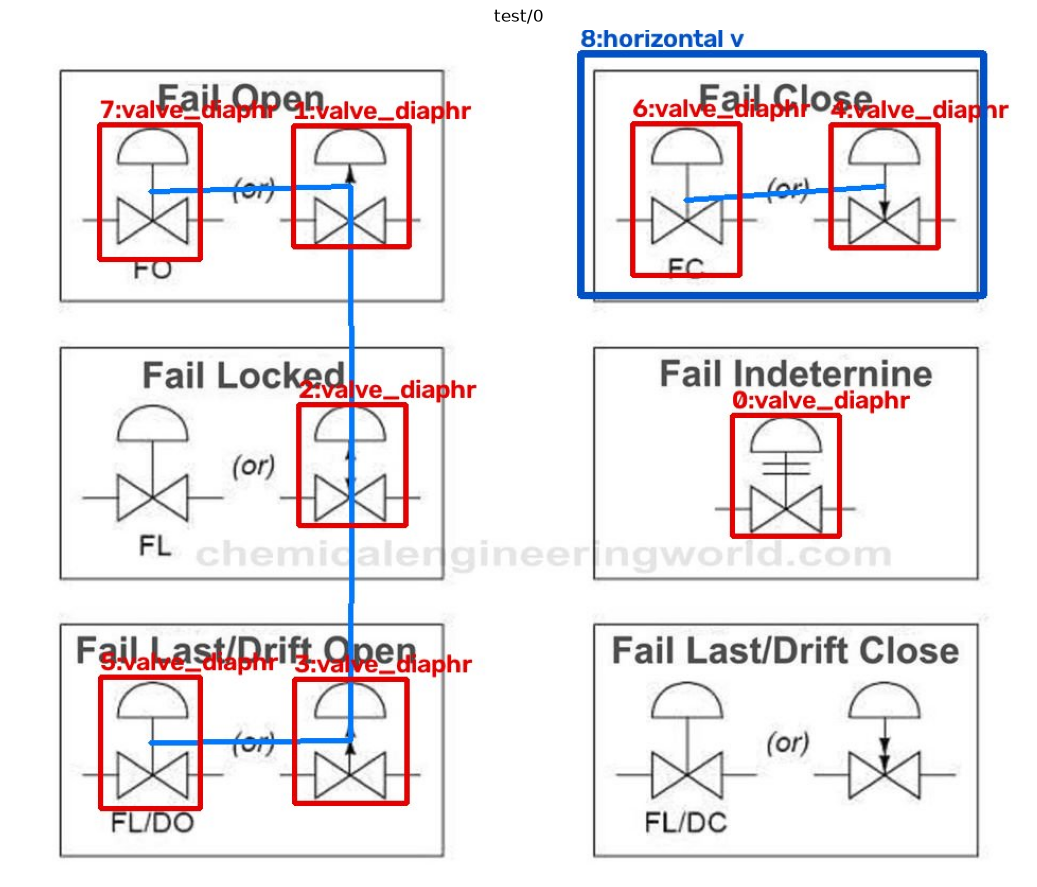

In [41]:
# Look at one result
if REAL_RESULTS:
    sid, r = next(iter(REAL_RESULTS.items()))
    jp = OUTPUT_DIR / Path(sid.split("#")[0]).parent / (Path(sid.split("#")[0]).name + (("_" + sid.split("#")[1]) if "#" in sid else "") + "_overlay.jpg")
    print(sid, {k: r[k] for k in ("num_equipment", "num_major_equipment", "num_safety_functions", "num_connections", "pre_scale")})
    print("major equipment:", [(e["id"], e["class_name"], e["tag"]) for e in r["equipment"] if e["role"] == "major_equipment"])
    print("safety functions:", [(f["tag"], f["description"], "->", f["linked_tag"]) for f in r["safety_functions"]][:10])
    if jp.exists():
        ov = cv2.imread(str(jp)); plt.figure(figsize=(16, 11)); plt.imshow(ov[..., ::-1]); plt.axis("off"); plt.title(sid); plt.show()